# Vanguard / WISER 2026 - Presentation Benchmark Suite

This notebook tests a constraint-safe hybrid portfolio solver. The classical
factor model handles the full asset universe; classical LNS and
cardinality-preserving XY-QAOA propose changes inside the same small adaptive
window; an exact continuous allocation oracle assigns weights; and an
independent validator decides whether a candidate may be reported.

The evaluation evidence covers:

1. exact correctness on a tractable instance;
2. simultaneous enforcement of every financial guardrail;
3. candidate quality and cost for classical and quantum window search;
4. factor-native speed and memory scaling with a fixed quantum workload;
5. real IBM hardware behavior, noise-management ablations, and physical-circuit metrics;
6. fair candidate-pool comparisons and QUBO-to-final-objective alignment;
7. a scenario-based CVaR preference frontier with held-out validation;
8. actual-model sensitivity for risk, income, and transaction-cost coefficients.

The notebook evaluates whether a quantum candidate generator can augment a
scalable classical optimizer. It does not assume that quantum sampling is
better: QPU, random, exact/best-known, and classical-LNS candidates receive the
same continuous allocation and independent validation before comparison.

## Execution order and cost profile

Run cells from top to bottom after installing the unified environment and
restarting the kernel:

```bash
python -m pip install -e ".[full]"
python scripts/install_environment.py --verify-only
```

Default execution is safe: IBM submission, the optional constraint ablation,
legacy quantum formulations, and stretch scaling are off. The IBM analysis can
reload previously saved counts and job metadata without consuming QPU time.

Gurobi requires a separate license so set USE_GUROBI = False if it is missing

Local experiments are sized for a strong workstation and avoid open-ended
solver calls. The repeated global core ends at 300,000 assets; 400,000-500,000
asset points are an explicit opt-in stretch test. Each section states its
question, method, and evaluator-facing output before any code runs. Committed
outputs are cleared so figures cannot be mistaken for results from a different
machine, commit, or hardware calibration.

In [25]:
# Run before importing NumPy/SciPy in a fresh kernel.
import gc
import os
from pathlib import Path

NUMERICAL_THREADS = min(16, os.cpu_count() or 1)
for variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ.setdefault(variable, str(NUMERICAL_THREADS))

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "src" / "vanguard_portfolio").is_dir()
        ):
            return candidate.resolve()
    raise FileNotFoundError("Run from the repository or notebooks/ directory.")

REPO = find_repo_root()
os.chdir(REPO)

# ---------- Master switches ----------
RUN_PYTEST = False
RUN_CONTINUOUS_BACKEND_CROSSCHECK = True
RUN_TINY_CERTIFICATION = True
RUN_MAIN_100_ASSET_CASE = True
RUN_GUROBI_WARM_START_STUDY = True
RUN_BACKTEST_ROBUSTNESS = True
RUN_ALL_CONSTRAINTS_GAUNTLET = True
RUN_CONSTRAINT_ABLATION = True

# Financial scenario-risk preference experiment; no quantum or IBM execution.
RUN_SCENARIO_PENALTY_SWEEP = True
SCENARIO_PENALTY_WEIGHTS = (0.0, 0.05, 0.10, 0.25, 0.50, 1.0)
SCENARIO_PENALTY_ALPHA = 0.95
SCENARIO_PENALTY_TRAIN_SCENARIOS = 2_000
SCENARIO_PENALTY_TEST_SCENARIOS = 20_000
SCENARIO_PENALTY_REPETITIONS = 5

# Canonical objective-coefficient study; actual Preferences/AllocationOracle API.
RUN_CANONICAL_PREFERENCE_SENSITIVITY = True
CANONICAL_RISK_WEIGHTS = (0.5, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 25.0)
CANONICAL_INCOME_WEIGHTS = (0.0, 0.25, 0.5, 1.0, 2.0, 4.0)
CANONICAL_COST_WEIGHTS = (0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0)
CANONICAL_PREFERENCE_REPETITIONS = 5
CANONICAL_PREFERENCE_TEST_SCENARIOS = 20_000
CANONICAL_PREFERENCE_ALPHA = 0.95

RUN_FROZEN_WINDOW_BENCHMARK = True
RUN_WIDTH_DEPTH_SWEEP = True
RUN_AER_BACKEND_COMPARISON = True

RUN_SCALING_PRESENTATION = True
RUN_SCALING_STRETCH = False

# Hardware jobs require an IBM account and may consume paid allocation.
# Keep False for a complete local run; the QPU cell prints one-time setup.
RUN_IBM_QPU = True
QPU_RESUME = True
QPU_FAIL_FAST = False
RUN_LEGACY_ALTERNATIVE_MODELS = True

OVERWRITE_OUTPUTS = True
BASE_SEED = 20260802
EXPECTED_BRANCH = "research/benchmark-notebook-cleanup"
OUTPUT_ROOT = REPO / "results" / "presentation_benchmark_suite"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# ---------- Full-constraint experiment ----------
GAUNTLET_SCENARIO_COUNTS = (500, 2_000, 10_000, 50_000, 100_000)
GAUNTLET_SCENARIO_REPETITIONS = 3
GAUNTLET_SCALING_BACKENDS = ("osqp", "clarabel")
RUN_GAUNTLET_HYBRID_STRESS = True
GAUNTLET_HYBRID_STRESS_SCENARIOS = 10_000

# ---------- Explicit classical solver controls ----------
ALLOCATION_BACKEND = "osqp"
QP_TOLERANCE = 1.0e-9
QP_MAX_ITERATIONS = 250_000
GUIDE_TIME_LIMIT_SECONDS = 30.0
ALLOW_GUIDE_FALLBACK = True
USE_GUROBI = True
GUROBI_TIME_LIMIT_SMALL = 120.0
GUROBI_TIME_LIMIT_MAIN = 300.0
GUROBI_MIP_GAP = 1.0e-3
BACKTEST_ROBUSTNESS_PATHS = 30
BACKTEST_PERIODS = 120

# ---------- Quantum candidate generation ----------
LOCAL_QUANTUM_BACKEND_REQUEST = "aer_gpu"
QAOA_DEPTH = 1
QAOA_SHOTS = 2_048
QAOA_OPTIMIZER_MAXITER = 60
QAOA_OPTIMIZER_STARTS = 3
QAOA_TOP_CANDIDATES = 32
QAOA_MAX_SUBSPACE_STATES = 400_000
QAOA_MAX_EDGES = 40
TRANSPILE_OPTIMIZATION_LEVEL = 3

# ---------- Controlled window study ----------
FROZEN_WINDOW_ASSETS = 250
FROZEN_PORTFOLIO_K = 50
FROZEN_WINDOW_WIDTH = 16
EXACT_QUBO_MAX_STATES = 3_000_000
EXACT_QUBO_TOP_K = 128
RANDOM_CANDIDATE_BUDGET = 128
WIDTH_SWEEP = [8, 10, 12, 14, 16, 18, 20, 22, 24]
DEPTH_SWEEP_WIDTHS = [10, 12, 14, 16]
DEPTH_SWEEP = [1, 2]
SWEEP_BACKEND = "subspace"
SWEEP_MAX_SUBSPACE_STATES = 2_500_000

# ---------- Global factor-native scaling ----------
GLOBAL_CORE_SIZES = [1_000, 10_000, 20_000, 50_000, 80_000, 100_000, 150_000, 200_000, 300_000]
GLOBAL_STRETCH_SIZES = [400_000, 500_000]
SCALING_REPETITIONS = 3
SCALING_STRETCH_REPETITIONS = 1
SCALING_CASE_TIME_LIMIT = 180.0
SCALING_WINDOW_SIZE = 16
SCALING_CARDINALITY = 50

# ---------- IBM Runtime ----------
# RUN_IBM_QPU is defined once in the master switches above. Keep it False for
# offline analysis; set it True only for an intentional, budgeted submission.

# ---------------------------------------------------------------------------
# IBM experiments: completed ablation and completed unmitigated frontier
# ---------------------------------------------------------------------------
# The two presets are separate experiments. ``ablation`` isolates one noise
# intervention at a time on two boundary cases. ``frontier`` maps the natural,
# unmitigated hardware boundary over width and depth. The final offline audit
# compares both campaigns and does not submit jobs.
QPU_STRESS_PRESET = "frontier"  # "ablation" or "frontier"
QPU_STRESS_PRESETS = {
    "ablation": ((12, 2), (16, 1)),
    "frontier": (
        (8, 1),
        (12, 1),
        (12, 2),
        (12, 3),
        (16, 1),
        (16, 2),
        (20, 1),
        (20, 2),
        (24, 1),
        (28, 1),
    ),
}
if QPU_STRESS_PRESET not in QPU_STRESS_PRESETS:
    raise ValueError(f"Unknown QPU_STRESS_PRESET={QPU_STRESS_PRESET!r}")
QPU_STRESS_CASES = QPU_STRESS_PRESETS[QPU_STRESS_PRESET]
QPU_STRESS_REPETITIONS = 5 if QPU_STRESS_PRESET == "ablation" else 3
QPU_STRESS_SHOTS = 4_096 if QPU_STRESS_PRESET == "ablation" else 8_192

# The recorded frontier intentionally uses ``baseline`` to measure the native
# hardware boundary. Gate twirling remains the best balanced treatment from
# the ablation and may be selected only for a new, separately labelled
# confirmatory campaign.
QPU_STRESS_FRONTIER_BEST_MODE = "baseline"

QPU_STRESS_TOP_CANDIDATES = 64
QPU_STRESS_MAX_EDGES = 30
QPU_STRESS_OPTIMIZER_MAXITER = 160
QPU_STRESS_OPTIMIZER_STARTS = 8
QPU_STRESS_TRANSPILE_SEEDS = tuple(
    [11, 29, 47, 71, 101, 131, 163, 197, 239, 283, 337, 397]
)
QPU_STRESS_BACKEND_POOL = 3
QPU_STRESS_MAX_EXECUTION_SECONDS = 3_600

# The ablation intentionally separates every intervention.  Do not combine
# results from these modes: they answer different causal questions.
QPU_STRESS_ABLATION_MODES = (
    "baseline",
    "dd_xx",
    "dd_xpxm",
    "gate_twirling",
    "measure_twirling",
    "dd_xpxm_gate_measure",
)
QPU_STRESS_ENABLE_FRACTIONAL_GATES = False
QPU_STRESS_FRACTIONAL_CASES = ()
QPU_STRESS_ORACLE_BUDGETS = (4, 8, 16, 32, 64)

# Exact fixed-weight enumeration is retained only where it is genuinely small.
# Wider cases use a clearly labelled best-known multi-start swap reference and
# transferred angles from the nearest tractable case at the same depth.
QPU_STRESS_MAX_EXACT_STATES = 400_000
QPU_STRESS_MAX_SIMULATED_STATES = 400_000
QPU_STRESS_REFERENCE_RESTARTS = 512
QPU_STRESS_REFERENCE_KEEP = 256
QPU_STRESS_REFERENCE_RANDOM_STATES = 20_000

# Leave None for circuit-aware selection among the least-busy accessible QPUs.
# Set a literal name, for example "ibm_fez", to force a reproducibility rerun.
QPU_STRESS_BACKEND_OVERRIDE = "ibm_kingston"

# Use a new label for a genuinely independent calibration-day repeat.  Reusing
# the same label resumes completed results or retrieves submitted Runtime jobs.
QPU_STRESS_CALIBRATION_DAY = "calibration_day_2"
QPU_STRESS_CAMPAIGN = f"{QPU_STRESS_CALIBRATION_DAY}_{QPU_STRESS_PRESET}"
QPU_EXECUTION_SCHEMA_VERSION = 3
QPU_ANALYSIS_SCHEMA_VERSION = 6
QPU_STRESS_SCHEMA_VERSION = QPU_EXECUTION_SCHEMA_VERSION
QPU_STRESS_DIR = OUTPUT_ROOT / f"06_ibm_qpu_stress_{QPU_STRESS_CAMPAIGN}"
QPU_STRESS_DIR.mkdir(parents=True, exist_ok=True)

QPU_STRESS_RESULTS = QPU_STRESS_DIR / "ibm_qpu_hardware_validation.csv"
QPU_STRESS_COUNTS = QPU_STRESS_DIR / "ibm_qpu_raw_counts.json"
QPU_STRESS_JOBS = QPU_STRESS_DIR / "ibm_qpu_jobs.csv"
QPU_STRESS_MANIFEST = QPU_STRESS_DIR / "ibm_qpu_job_manifest.json"
QPU_STRESS_CONFIG = QPU_STRESS_DIR / "ibm_qpu_config.json"
QPU_STRESS_BUDGETS = QPU_STRESS_DIR / "ibm_qpu_oracle_budget_curves.csv"
QPU_STRESS_TRANSPILES = QPU_STRESS_DIR / "ibm_qpu_transpilation_candidates.csv"

print("Repository:", REPO)
print("Output root:", OUTPUT_ROOT)
print("Numerical threads:", NUMERICAL_THREADS)

Repository: /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio
Output root: /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/results/presentation_benchmark_suite
Numerical threads: 16


## 1. Environment and accelerator preflight

**Experiment.** Records the exact commit, Python packages, CPU, memory,
NVIDIA inventory, and real Aer CPU/GPU execution probes.

**Importance.** Timings are meaningful only with reproducible
hardware/software context. A GPU is selected only after a real CUDA circuit
succeeds; its role is Aer circuit sampling, not the OSQP factor solve. IBM
Runtime is checked in the same environment but credentials are never stored
in the notebook.


In [14]:
import json
import platform
import subprocess
import sys
import shutil
from datetime import datetime, timezone
from importlib import metadata


def command_output(command: list[str], timeout: int = 30) -> str:
    """Run a small diagnostic command without making notebook setup brittle."""
    if not shutil.which(command[0]):
        return f"Command {command[0]!r} not found"
    try:
        completed = subprocess.run(
            command,
            cwd=REPO,
            text=True,
            capture_output=True,
            timeout=timeout,
            check=False,
        )
    except Exception as exc:  # diagnostics must not hide the main experiment
        return f"{type(exc).__name__}: {exc}"
    return (completed.stdout or completed.stderr).strip()


def get_cpu_info():
    """Cross-platform CPU identification summary."""
    system = platform.system()
    if system == "Linux":
        return command_output(["bash", "-lc", "lscpu | sed -n '1,25p'"])
    elif system == "Darwin":  # macOS
        return command_output(["sysctl", "-n", "machdep.cpu.brand_string"])
    elif system == "Windows":
        return command_output(["wmic", "cpu", "get", "name"])
    return platform.processor()

def get_memory_info():
    """Cross-platform memory information using native commands."""
    system = platform.system()
    if system == "Linux":
        return command_output(["free", "-h"])
    elif system == "Darwin":  # macOS
        return command_output(["vm_stat"])  # Alternately use 'top -l 1 | grep PhysMem'
    elif system == "Windows":
        return command_output(["wmic", "OS", "get", "FreePhysicalMemory,TotalVisibleMemorySize"])
    return "Unknown OS Memory Info"

environment = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "branch": command_output(["git", "branch", "--show-current"]),
    "commit": command_output(["git", "rev-parse", "HEAD"]),
    "status": command_output(["git", "status", "--short"]),
    "cpu": get_cpu_info(),
    "memory": get_memory_info(),
    "gpu": command_output(["nvidia-smi"]),  # Safe now: returns "not found" if missing
}

package_names = [
    "numpy", "scipy", "pandas", "matplotlib", "osqp", "gurobipy",
    "qiskit", "qiskit-aer", "qiskit-aer-gpu",
    "qiskit-aer-gpu-cu11", "qiskit-ibm-runtime",
]
environment["packages"] = {}
for name in package_names:
    try:
        environment["packages"][name] = metadata.version(name)
    except metadata.PackageNotFoundError:
        pass

aer_devices = ()
aer_advertised_devices = ()
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator

    aer_advertised_devices = tuple(AerSimulator().available_devices())

    def verify_aer_device(device: str) -> None:
        simulator = AerSimulator(method="statevector", device=device)
        circuit = QuantumCircuit(2)
        circuit.h(0)
        circuit.cx(0, 1)
        circuit.measure_all()
        compiled = transpile(circuit, simulator, optimization_level=0)
        result = simulator.run(
            compiled,
            shots=32,
            seed_simulator=BASE_SEED,
        ).result()
        if not bool(getattr(result, "success", True)):
            raise RuntimeError(getattr(result, "status", "unknown status"))

    verified_devices = []
    verify_aer_device("CPU")
    verified_devices.append("CPU")
    if "GPU" in aer_advertised_devices:
        try:
            verify_aer_device("GPU")
            verified_devices.append("GPU")
        except Exception as exc:  # noqa: BLE001 - optional GPU probe
            environment["aer_gpu_probe_error"] = (
                f"{type(exc).__name__}: {exc}"
            )
    aer_devices = tuple(verified_devices)
except Exception as exc:  # noqa: BLE001 - optional Aer import
    environment["aer_import_error"] = f"{type(exc).__name__}: {exc}"
environment["aer_advertised_devices"] = list(aer_advertised_devices)
environment["aer_devices"] = list(aer_devices)

installed_aer_distributions = [
    name
    for name in (
        "qiskit-aer",
        "qiskit-aer-gpu",
        "qiskit-aer-gpu-cu11",
    )
    if name in environment["packages"]
]
environment["installed_aer_distributions"] = installed_aer_distributions

if RUN_IBM_QPU:
    expected_versions = {
        "qiskit": "2.5.1",
        "qiskit-ibm-runtime": "0.48.0",
    }
    version_mismatches = {
        name: {
            "expected": expected,
            "installed": environment["packages"].get(name),
        }
        for name, expected in expected_versions.items()
        if environment["packages"].get(name) != expected
    }
    if len(installed_aer_distributions) != 1:
        raise RuntimeError(
            "The QPU notebook requires exactly one Aer distribution, but "
            f"found {installed_aer_distributions}. Run "
            f"{sys.executable} scripts/install_environment.py, then restart "
            "this kernel."
        )
    if version_mismatches:
        raise RuntimeError(
            "The notebook kernel is not using the pinned unified quantum "
            f"stack: {version_mismatches}. Interpreter: {sys.executable}"
        )
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    except Exception as exc:
        raise RuntimeError(
            "IBM Runtime cannot import in this notebook kernel. Run "
            f"{sys.executable} -m pip install -e '.[full]' from the repository, "
            "restart the kernel, and rerun the preflight."
        ) from exc
    environment["ibm_runtime_import"] = (
        f"ok: {QiskitRuntimeService.__name__}, {SamplerV2.__name__}"
    )

gurobi_available = False
try:
    import gurobipy as gp
    probe = gp.Model()
    probe.Params.OutputFlag = 0
    gurobi_available = True
    environment["gurobi_version"] = ".".join(map(str, gp.gurobi.version()))
except Exception as exc:  # noqa: BLE001 - optional licensed backend
    environment["gurobi_error"] = f"{type(exc).__name__}: {exc}"
environment["gurobi_available"] = gurobi_available

if environment["branch"] != EXPECTED_BRANCH:
    print(
        f"WARNING: expected {EXPECTED_BRANCH!r}; "
        f"found {environment['branch']!r}. Results remain tagged with the actual commit."
    )

LOCAL_QUANTUM_BACKEND = (
    "aer_gpu"
    if LOCAL_QUANTUM_BACKEND_REQUEST == "aer_gpu" and "GPU" in aer_devices
    else "subspace"
)
if LOCAL_QUANTUM_BACKEND_REQUEST == "aer_gpu" and LOCAL_QUANTUM_BACKEND != "aer_gpu":
    print("WARNING: Aer GPU unavailable; local quantum tests use subspace.")

(OUTPUT_ROOT / "environment.json").write_text(
    json.dumps(environment, indent=2) + "\n",
    encoding="utf-8",
)
print(json.dumps(environment, indent=2))
print("Resolved local quantum backend:", LOCAL_QUANTUM_BACKEND)
print("Gurobi enabled:", bool(USE_GUROBI and gurobi_available))

{
  "timestamp_utc": "2026-08-07T04:33:52.594552+00:00",
  "python": "3.10.20 (main, Jun 11 2026, 15:17:37) [GCC 14.3.0]",
  "platform": "Linux-6.1.0-34-amd64-x86_64-with-glibc2.36",
  "branch": "research/benchmark-notebook-cleanup",
  "commit": "571d450be694789be4d57bfa5887fec0b9f594ed",
  "status": "",
  "cpu": "Architecture:                         x86_64\nCPU op-mode(s):                       32-bit, 64-bit\nAddress sizes:                        48 bits physical, 48 bits virtual\nByte Order:                           Little Endian\nCPU(s):                               32\nOn-line CPU(s) list:                  0-31\nVendor ID:                            AuthenticAMD\nModel name:                           AMD Ryzen 9 5950X 16-Core Processor\nCPU family:                           25\nModel:                                33\nThread(s) per core:                   2\nCore(s) per socket:                   16\nSocket(s):                            1\nStepping:                            

## 2. Shared model, validation, and compact artifact helpers

**Experiment.** Imports the solver once and defines consistent result
tables, canonical CVaR evaluation, support comparisons, and an
evaluator-facing artifact profile.

**Importance.** Every experiment uses the same objective,
fixed-support allocation oracle, and independent validator. The compact
profile avoids dozens of redundant plots while retaining auditable CSV/JSON
evidence and the few figures used in the presentation.


In [15]:
import importlib.util
import shutil
import time
from dataclasses import replace
import math
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage
from IPython.display import display
import hashlib
from datetime import datetime, timezone
from importlib import metadata as package_metadata

SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from vanguard_portfolio.allocation import (
    AllocationOracle,
    find_feasible_initial_support,
    solve_relaxation,
)
from vanguard_portfolio.classical_continuous import solve_continuous
from vanguard_portfolio.classical_discrete import solve_cardinality_gurobi
from vanguard_portfolio.data_generation import (
    generate_backtest_returns,
    generate_factor_universe,
    generate_return_scenarios,
    generate_synthetic_universe,
)
from vanguard_portfolio.hybrid import HybridConfig, HybridRun, run_hybrid_optimizer
from vanguard_portfolio.portfolio_model import empirical_cvar as canonical_empirical_cvar
from vanguard_portfolio.presentation import write_hybrid_artifacts
from vanguard_portfolio.quantum_solver import (
    XYQAOAConfig,
    _basis_energies,
    _fixed_weight_basis,
    _decode_qiskit_counts,
    _fixed_weight_structure,
    _runtime_quantum_seconds,
    _subspace_state,
    build_xy_qaoa_circuit,
    solve_xy_qaoa,
)
from vanguard_portfolio.qubo_builder import build_window_qubo
from vanguard_portfolio.schemas import PortfolioConstraints, PortfolioProblem, Preferences
from vanguard_portfolio.topology import market_communities
from vanguard_portfolio.validation import validate_weights
from vanguard_portfolio.window_search import (
    construct_change_window,
    current_window_bits,
    evaluate_bitstrings,
    tabu_window_search,
)

PREFERENCES = Preferences(
    lambda_return=1.0,
    lambda_risk=5.0,
    lambda_income=0.5,
    lambda_cost=1.0,
)

def clean_directory(path: Path) -> None:
    if path.exists() and OVERWRITE_OUTPUTS:
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def result_table(run: HybridRun) -> pd.DataFrame:
    frame = pd.DataFrame(run.summary_records())
    columns = [
        "method", "stage", "iteration", "objective", "runtime_seconds",
        "feasible", "breaches", "max_violation", "support_size",
        "expected_return", "volatility", "income", "turnover",
        "best_bound", "reported_mip_gap",
    ]
    return frame[[column for column in columns if column in frame.columns]]

def run_and_archive(
    label: str,
    problem: PortfolioProblem,
    constraints: PortfolioConstraints,
    config: HybridConfig,
    *,
    backtest_periods: int = 120,
    backtest_seed: int = BASE_SEED + 1,
) -> tuple[HybridRun, pd.DataFrame, Path]:
    output = OUTPUT_ROOT / label
    clean_directory(output)
    total_start = time.perf_counter()
    run = run_hybrid_optimizer(problem, PREFERENCES, constraints, config)
    realized = generate_backtest_returns(
        problem,
        periods=backtest_periods,
        periods_per_year=12,
        seed=backtest_seed,
    )
    write_hybrid_artifacts(
        run, output, realized_returns=realized, profile="evaluation"
    )
    frame = result_table(run)
    frame.to_csv(output / "notebook_method_summary.csv", index=False)
    (output / "notebook_wall_seconds.txt").write_text(
        f"{time.perf_counter() - total_start:.9f}\n",
        encoding="utf-8",
    )
    print(
        f"{label}: best={run.best.method}, objective={run.best.objective:.10g}, "
        f"breaches={run.best.breaches}, runtime={run.runtime:.3f}s"
    )
    display(frame)
    return run, frame, output

def empirical_cvar(
    scenario_returns: np.ndarray,
    weights: np.ndarray,
    alpha: float = 0.95,
) -> float:
    # Keep calibration and independent validation on the same finite-sample
    # Rockafellar–Uryasev definition used by the solver.
    return canonical_empirical_cvar(weights, scenario_returns, alpha)

def support(weights: np.ndarray, tolerance: float = 1.0e-8) -> set[int]:
    return set(np.flatnonzero(np.asarray(weights) > tolerance).tolist())

def support_jaccard(left: np.ndarray, right: np.ndarray) -> float:
    a, b = support(left), support(right)
    return len(a & b) / max(len(a | b), 1)

def best_by_method(run: HybridRun) -> dict[str, object]:
    selected = {}
    for result in run.all_results():
        if not (result.success and result.feasible):
            continue
        previous = selected.get(result.method)
        if previous is None or result.objective < previous.objective:
            selected[result.method] = result
    return selected

def plot_top_trades(run: HybridRun, output: Path, count: int = 10) -> Path:
    change = run.best.weights - run.problem.w0
    buys = np.argsort(change)[-count:][::-1]
    sells = np.argsort(change)[:count]
    indices = np.concatenate([sells, buys])
    figure, axis = plt.subplots(figsize=(12, 5))
    axis.bar(np.arange(len(indices)), change[indices])
    axis.axhline(0.0, linewidth=1.0)
    axis.set_xticks(np.arange(len(indices)))
    axis.set_xticklabels(
        [run.problem.asset_names[index] for index in indices],
        rotation=55,
        ha="right",
    )
    axis.set_ylabel("Recommended weight minus current weight")
    axis.set_title("Largest recommended sales and purchases")
    figure.tight_layout()
    path = output / "top_trades.png"
    figure.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return path

def plot_support_overlap(run: HybridRun, output: Path) -> Path:
    methods = best_by_method(run)
    names = list(methods)
    matrix = np.empty((len(names), len(names)))
    for i, left in enumerate(names):
        for j, right in enumerate(names):
            matrix[i, j] = support_jaccard(
                methods[left].weights,
                methods[right].weights,
            )
    figure, axis = plt.subplots(figsize=(8, 7))
    image = axis.imshow(matrix, vmin=0.0, vmax=1.0)
    axis.set_xticks(range(len(names)))
    axis.set_yticks(range(len(names)))
    axis.set_xticklabels(names, rotation=55, ha="right")
    axis.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            axis.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")
    axis.set_title("Support overlap (Jaccard similarity)")
    figure.colorbar(image, ax=axis)
    figure.tight_layout()
    path = output / "support_overlap.png"
    figure.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return path

## 3. Repository test suite

**Experiment.** Runs the project tests before any benchmark evidence is
generated. 

**Importance.** A fast figure is irrelevant if model,
validation, packaging, or backend regression tests fail.


In [16]:
if RUN_PYTEST:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", "-q"],
        cwd=REPO,
        check=False,
    )
    if completed.returncode != 0:
        raise RuntimeError("The test suite failed; stop before generating claims.")

## 3A. Continuous-backend agreement

**Experiment.** Solves the same convex portfolio with available SciPy,
OSQP, Clarabel, and Gurobi backends. 

**Importance.** Agreement in
objective and feasibility makes the faster native sparse backends credible;
the output is one comparison table.


In [17]:
continuous_backend_crosscheck = None

if RUN_CONTINUOUS_BACKEND_CROSSCHECK:
    cross_problem = generate_factor_universe(
        n_assets=100,
        n_groups=8,
        n_factors=6,
        seed=BASE_SEED + 11,
        current_cardinality=None,
        materialize_covariance=False,
    )
    cross_problem.target_return = None
    cross_problem.max_turnover = None

    backend_specs = [
        ("scipy", {"tol": 1.0e-10, "max_iter": 5_000}),
        (
            "osqp",
            {
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
            },
        ),
        ("cvxpy:CLARABEL", {"solver_options": {}}),
    ]
    if USE_GUROBI and gurobi_available:
        backend_specs.append(
            (
                "gurobi",
                {
                    "threads": NUMERICAL_THREADS,
                    "seed": BASE_SEED,
                    "method": 2,
                    "bar_conv_tol": 1.0e-10,
                    "output": False,
                },
            )
        )

    rows = []
    weights_by_backend = {}
    for backend, options in backend_specs:
        try:
            result = solve_continuous(
                cross_problem,
                PREFERENCES,
                backend=backend,
                **options,
            )
            rows.append(
                {
                    "backend": backend,
                    "method": result.method,
                    "status": result.status,
                    "success": result.success,
                    "feasible": result.feasible,
                    "objective": result.objective,
                    "runtime_seconds": result.runtime,
                    "breaches": result.breaches,
                    "max_violation": result.max_violation,
                    "iterations": result.metadata.get("iterations"),
                }
            )
            if result.success and result.feasible:
                weights_by_backend[backend] = result.weights.copy()
        except Exception as exc:  # noqa: BLE001 - backend cross-check row
            rows.append(
                {
                    "backend": backend,
                    "status": "unavailable_or_failed",
                    "success": False,
                    "feasible": False,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )

    continuous_backend_crosscheck = pd.DataFrame(rows)
    display(continuous_backend_crosscheck)
    continuous_backend_crosscheck.to_csv(
        OUTPUT_ROOT / "continuous_backend_crosscheck.csv",
        index=False,
    )

    successful_rows = continuous_backend_crosscheck[
        continuous_backend_crosscheck["success"] == True
    ]
    if len(successful_rows) >= 2:
        objective_spread = (
            successful_rows["objective"].max()
            - successful_rows["objective"].min()
        )
        pairwise_weight_differences = []
        names = list(weights_by_backend)
        for left_index, left in enumerate(names):
            for right in names[left_index + 1 :]:
                pairwise_weight_differences.append(
                    {
                        "left": left,
                        "right": right,
                        "maximum_absolute_weight_difference": float(
                            np.max(
                                np.abs(
                                    weights_by_backend[left]
                                    - weights_by_backend[right]
                                )
                            )
                        ),
                    }
                )
        print("Objective spread:", objective_spread)
        display(pd.DataFrame(pairwise_weight_differences))

,backend,method,status,success,feasible,objective,runtime_seconds,breaches,max_violation,iterations
0,scipy,scipy_slsqp,Optimization terminated successfully,True,True,-0.049141,1.451658,0,2.220446e-16,61.0
1,osqp,osqp,solved,True,True,-0.049141,0.004067,0,5.838211e-10,275.0
2,cvxpy:CLARABEL,cvxpy_clarabel,optimal,True,True,-0.049141,0.008746,0,2.220446e-16,10.0
3,gurobi,gurobi_qp,optimal,True,True,-0.049141,0.018984,0,7.257817e-11,0.0


Objective spread: 1.4062591646712974e-09


,left,right,maximum_absolute_weight_difference
0,scipy,osqp,0.000045
1,scipy,cvxpy:CLARABEL,0.000168
2,scipy,gurobi,0.000055
3,osqp,cvxpy:CLARABEL,0.000160
4,osqp,gurobi,0.000013
5,cvxpy:CLARABEL,gurobi,0.000146


## 4. Experiment A — tiny exact correctness certificate

**Experiment.** Exhaustively enumerates a tractable exact-K window and,
when licensed, compares it with Gurobi and XY-QAOA proposals. 

**Importance.** This is a genuine correctness certificate: enumeration
and MIQP should agree, and every candidate is independently validated.


In [18]:
tiny_run = tiny_frame = tiny_output = None

if RUN_TINY_CERTIFICATION:
    tiny_problem = generate_synthetic_universe()
    tiny_problem.target_return = None
    tiny_problem.max_turnover = 0.80

    tiny_constraints = PortfolioConstraints(
        exact_cardinality=4,
        minimum_active_weight=0.05,
        maximum_weights=np.minimum(tiny_problem.upper, 0.50),
    ).validate_for(tiny_problem)

    tiny_config = HybridConfig(
        iterations=1,
        window_size=6,
        held_fraction=0.50,
        allocation_backend="scipy",
        allocation_options={"tol": QP_TOLERANCE, "max_iter": 5_000},
        relaxation_options={"tol": QP_TOLERANCE, "max_iter": 5_000},
        initial_trials=300,
        initial_milp_time_limit=20.0,
        classical_tabu_iterations=60,
        classical_tabu_tenure=7,
        classical_oracle_candidates=4,
        enumerate_windows_up_to=100_000,
        run_quantum=True,
        quantum=XYQAOAConfig(
            depth=1,
            shots=QAOA_SHOTS,
            optimizer_maxiter=120,
            optimizer_starts=6,
            seed=BASE_SEED,
            initial_state="warm",
            mixer="ring",
            backend="subspace",
            maximum_subspace_states=400_000,
            top_candidates=128,
            transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
        ),
        run_penalty_qaoa=True,
        penalty_multiplier=10.0,
        use_topology=False,
        maximum_quantum_edges=None,
        run_gurobi_reference=bool(USE_GUROBI and gurobi_available),
        gurobi_time_limit=GUROBI_TIME_LIMIT_SMALL,
        gurobi_mip_gap=1.0e-6,
        seed=BASE_SEED,
    )

    tiny_run, tiny_frame, tiny_output = run_and_archive(
        "01_tiny_exact_certification",
        tiny_problem,
        tiny_constraints,
        tiny_config,
        backtest_periods=60,
    )

    exact_rows = tiny_frame[
        tiny_frame["method"].isin(
            ["classical_enumeration", "gurobi_cardinality_miqp"]
        )
    ]
    if len(exact_rows) >= 2:
        print(
            "Enumeration/Gurobi objective spread:",
            exact_rows["objective"].max() - exact_rows["objective"].min(),
        )

01_tiny_exact_certification: best=feasible_initial_portfolio, objective=-0.03681145, breaches=0, runtime=0.133s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,scipy_slsqp,,,-0.038073,0.011317,True,0,5.551115e-17,5,0.04223,0.061072,0.030111,0.5,,
1,feasible_initial_portfolio,initialization,,-0.036811,0.008755,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,,
2,classical_enumeration,window_search,0,-0.036811,0.087607,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,,
3,penalty_qaoa_statevector,window_search,0,-0.036811,0.005370,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,,
4,gurobi_cardinality_miqp,global_certification,1,-0.036811,0.009093,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,-0.036811,0.0


Enumeration/Gurobi objective spread: 0.0


## 5. Experiment B — canonical 100-asset hybrid portfolio

**Experiment.** Runs the complete factor-relaxation → feasible support →
classical/XY-QAOA window → exact allocation → validation pipeline on a
readable business-sized case. 

**Importance.** It shows the
recommended trades, guardrails, objective quality, and quantum contribution
in one representative run rather than a synthetic micro-benchmark.


In [19]:
main_run = main_frame = main_output = None

if RUN_MAIN_100_ASSET_CASE:
    main_problem = generate_factor_universe(
        n_assets=100,
        n_groups=8,
        n_factors=6,
        seed=BASE_SEED,
        current_cardinality=20,
        materialize_covariance=False,
    )
    main_problem.target_return = None
    main_problem.max_turnover = 0.40

    main_constraints = PortfolioConstraints(
        exact_cardinality=20,
        minimum_active_weight=0.01,
        maximum_weights=np.full(main_problem.n, 0.10),
    ).validate_for(main_problem)

    main_config = HybridConfig(
        iterations=2,
        window_size=16,
        held_fraction=0.45,
        allocation_backend=ALLOCATION_BACKEND,
        allocation_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
        },
        relaxation_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
            "time_limit": GUIDE_TIME_LIMIT_SECONDS,
        },
        initial_trials=400,
        initial_milp_time_limit=30.0,
        classical_tabu_iterations=80,
        classical_tabu_tenure=8,
        classical_oracle_candidates=4,
        enumerate_windows_up_to=5_000,
        run_quantum=True,
        quantum=XYQAOAConfig(
            depth=QAOA_DEPTH,
            shots=QAOA_SHOTS,
            optimizer_maxiter=QAOA_OPTIMIZER_MAXITER,
            optimizer_starts=QAOA_OPTIMIZER_STARTS,
            seed=BASE_SEED,
            initial_state="warm",
            mixer="ring",
            backend=LOCAL_QUANTUM_BACKEND,
            maximum_subspace_states=QAOA_MAX_SUBSPACE_STATES,
            top_candidates=QAOA_TOP_CANDIDATES,
            transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
        ),
        run_penalty_qaoa=True,
        penalty_multiplier=10.0,
        use_topology=True,
        maximum_quantum_edges=QAOA_MAX_EDGES,
        run_gurobi_reference=bool(USE_GUROBI and gurobi_available),
        gurobi_time_limit=GUROBI_TIME_LIMIT_MAIN,
        gurobi_mip_gap=GUROBI_MIP_GAP,
        seed=BASE_SEED,
    )

    main_run, main_frame, main_output = run_and_archive(
        "02_main_100_asset_case",
        main_problem,
        main_constraints,
        main_config,
    )
    plot_top_trades(main_run, main_output)
    plot_support_overlap(main_run, main_output)

02_main_100_asset_case: best=gurobi_cardinality_miqp, objective=-0.03841471459, breaches=0, runtime=2.027s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,osqp,,,-0.038416,0.008580,True,0,4.475806e-10,20,0.061667,0.082019,0.022144,0.4,,
1,feasible_initial_portfolio,initialization,,-0.034688,0.008922,True,0,7.576739e-11,20,0.060506,0.083795,0.019962,0.4,,
2,classical_tabu_lns,window_search,0,-0.036845,0.381395,True,0,1.387686e-09,20,0.059421,0.080226,0.020480,0.4,,
3,xy_qaoa_aer_gpu,window_search,0,-0.036751,0.280554,True,0,5.406036e-10,20,0.060866,0.082498,0.021127,0.4,,
4,penalty_qaoa_statevector,window_search,0,-0.038045,0.839388,True,0,5.675535e-09,20,0.061747,0.081960,0.021237,0.4,,
5,classical_tabu_lns,window_search,1,-0.038045,0.255940,True,0,5.675535e-09,20,0.061747,0.081960,0.021237,0.4,,
6,xy_qaoa_aer_gpu,window_search,1,-0.038045,0.226644,True,0,5.675535e-09,20,0.061747,0.081960,0.021237,0.4,,
7,gurobi_cardinality_miqp,global_certification,2,-0.038415,0.018587,True,0,2.220446e-16,20,0.061726,0.082073,0.022117,0.4,-0.038415,0.0


## 5A. Gurobi cold-start versus hybrid warm-start

**Experiment.** Compares identical Gurobi models with and without the
hybrid incumbent. 

**Importance.** It tests whether the hybrid solver
augments a classical exact solver by supplying a useful feasible start


In [20]:
gurobi_start_study = None

if (
    RUN_GUROBI_WARM_START_STUDY
    and main_run is not None
    and USE_GUROBI
    and gurobi_available
):
    hybrid_candidates = [
        main_run.initial,
        *[
            result
            for result in main_run.results
            if (
                result.method != "gurobi_cardinality_miqp"
                and result.success
                and result.feasible
            )
        ],
    ]
    hybrid_best_before_gurobi = min(
        hybrid_candidates,
        key=lambda result: result.objective,
    )

    starts = {
        "cold_start": None,
        "valid_initial_start": main_run.initial.weights,
        "hybrid_incumbent_start": hybrid_best_before_gurobi.weights,
    }
    rows = []
    for label, warm_start in starts.items():
        result = solve_cardinality_gurobi(
            main_problem,
            PREFERENCES,
            main_constraints,
            warm_start=warm_start,
            time_limit=GUROBI_TIME_LIMIT_MAIN,
            mip_gap=GUROBI_MIP_GAP,
            threads=NUMERICAL_THREADS,
            seed=BASE_SEED,
            output=False,
        )
        rows.append(
            {
                "start": label,
                "status": result.status,
                "success": result.success,
                "optimal": result.optimal,
                "feasible": result.feasible,
                "objective": result.objective,
                "best_bound": result.metadata.get("best_bound"),
                "reported_mip_gap": result.metadata.get(
                    "reported_mip_gap"
                ),
                "model_build_seconds": result.metadata.get(
                    "model_build_seconds"
                ),
                "solve_seconds": result.metadata.get("solve_seconds"),
                "total_seconds": result.runtime,
                "nodes": result.metadata.get("nodes"),
                "breaches": result.breaches,
            }
        )

    gurobi_start_study = pd.DataFrame(rows)
    display(gurobi_start_study)
    gurobi_start_study.to_csv(
        main_output / "gurobi_cold_vs_warm.csv",
        index=False,
    )

    figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(
        gurobi_start_study["start"],
        gurobi_start_study["total_seconds"],
    )
    axes[0].set_ylabel("Wall-clock seconds")
    axes[0].set_title("Gurobi runtime by MIP start")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(
        gurobi_start_study["start"],
        gurobi_start_study["reported_mip_gap"],
    )
    axes[1].set_ylabel("Reported MIP gap")
    axes[1].set_title("Certificate quality at the time limit")
    axes[1].tick_params(axis="x", rotation=25)

    figure.tight_layout()
    figure.savefig(
        main_output / "gurobi_cold_vs_warm.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

,start,status,success,optimal,feasible,objective,best_bound,reported_mip_gap,model_build_seconds,solve_seconds,total_seconds,nodes,breaches
0,cold_start,optimal,True,True,True,-0.038415,-0.038415,0.0,0.017520,0.018152,0.035744,1.0,0
1,valid_initial_start,optimal,True,True,True,-0.038415,-0.038415,0.0,0.011422,0.015732,0.027215,1.0,0
2,hybrid_incumbent_start,optimal,True,True,True,-0.038415,-0.038415,0.0,0.011327,0.015596,0.026983,1.0,0


## 5B. Multi-seed out-of-sample robustness

**Experiment.** Evaluates the selected portfolios on repeated synthetic
return paths and reports distributions rather than one path. 

**Importance.** It checks that small in-sample objective differences are not presented
as investment forecasts; only one compact robustness summary is retained.


In [21]:
backtest_robustness = None
backtest_robustness_summary = None

if RUN_BACKTEST_ROBUSTNESS and main_run is not None:
    methods = {
        name: result
        for name, result in best_by_method(main_run).items()
        if result.model_type != "continuous_relaxation"
    }

    rows = []
    for path_index in range(BACKTEST_ROBUSTNESS_PATHS):
        realized = generate_backtest_returns(
            main_problem,
            periods=BACKTEST_PERIODS,
            periods_per_year=12,
            seed=BASE_SEED + 10_000 + path_index,
        )
        for method, result in methods.items():
            portfolio_returns = realized @ result.weights
            wealth = np.cumprod(1.0 + portfolio_returns)
            running_peak = np.maximum.accumulate(
                np.concatenate([[1.0], wealth])
            )[1:]
            drawdown = 1.0 - wealth / np.maximum(
                running_peak,
                1.0e-15,
            )
            annual_return = float(
                np.mean(portfolio_returns) * 12.0
            )
            annual_volatility = float(
                np.std(portfolio_returns, ddof=1) * np.sqrt(12.0)
            )
            rows.append(
                {
                    "path": path_index,
                    "seed": BASE_SEED + 10_000 + path_index,
                    "method": method,
                    "terminal_wealth": float(wealth[-1]),
                    "annualized_return": annual_return,
                    "annualized_volatility": annual_volatility,
                    "return_to_volatility": (
                        annual_return
                        / max(annual_volatility, 1.0e-15)
                    ),
                    "maximum_drawdown": float(np.max(drawdown)),
                    "period_cvar_95": empirical_cvar(
                        realized,
                        result.weights,
                        alpha=0.95,
                    ),
                }
            )

    backtest_robustness = pd.DataFrame(rows)
    metrics = [
        "terminal_wealth",
        "annualized_return",
        "annualized_volatility",
        "return_to_volatility",
        "maximum_drawdown",
        "period_cvar_95",
    ]
    summary_rows = []
    for method, group in backtest_robustness.groupby("method"):
        for metric in metrics:
            values = group[metric].to_numpy()
            summary_rows.append(
                {
                    "method": method,
                    "metric": metric,
                    "median": float(np.median(values)),
                    "q10": float(np.quantile(values, 0.10)),
                    "q90": float(np.quantile(values, 0.90)),
                    "mean": float(np.mean(values)),
                    "std": float(np.std(values, ddof=1)),
                }
            )
    backtest_robustness_summary = pd.DataFrame(summary_rows)
    display(backtest_robustness_summary)

    backtest_robustness.to_csv(
        main_output / "backtest_robustness_paths.csv",
        index=False,
    )
    backtest_robustness_summary.to_csv(
        main_output / "backtest_robustness_summary.csv",
        index=False,
    )

    method_order = list(methods)
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].boxplot(
        [
            backtest_robustness.loc[
                backtest_robustness["method"] == method,
                "terminal_wealth",
            ].to_numpy()
            for method in method_order
        ],
        tick_labels=method_order,  # Fix applied here
    )
    axes[0].set_title("Terminal wealth across independent paths")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].boxplot(
        [
            backtest_robustness.loc[
                backtest_robustness["method"] == method,
                "maximum_drawdown",
            ].to_numpy()
            for method in method_order
        ],
        tick_labels=method_order,  # Fix applied here
    )
    axes[1].set_title("Maximum drawdown across independent paths")
    axes[1].tick_params(axis="x", rotation=45)


    figure.tight_layout()
    figure.savefig(
        main_output / "backtest_robustness.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

,method,metric,median,q10,q90,mean,std
0,classical_tabu_lns,terminal_wealth,1.790922,1.348110,2.486414,1.802051,0.457529
1,classical_tabu_lns,annualized_return,0.061894,0.033679,0.094229,0.059362,0.025521
2,classical_tabu_lns,annualized_volatility,0.082178,0.079427,0.088104,0.083104,0.003835
3,classical_tabu_lns,return_to_volatility,0.731588,0.395982,1.141179,0.715918,0.315392
4,classical_tabu_lns,maximum_drawdown,0.135324,0.095996,0.212627,0.147412,0.044640
5,classical_tabu_lns,period_cvar_95,0.042289,0.038601,0.049400,0.043178,0.004783
6,feasible_initial_portfolio,terminal_wealth,1.735806,1.301503,2.402762,1.763866,0.457879
7,feasible_initial_portfolio,annualized_return,0.058480,0.029889,0.091810,0.057196,0.026240
8,feasible_initial_portfolio,annualized_volatility,0.083993,0.080657,0.090771,0.084905,0.004189
9,feasible_initial_portfolio,return_to_volatility,0.708319,0.354794,1.131392,0.675511,0.317028


## 6. Experiment C — all-constraints validity and sparse-CVaR scaling

This experiment separates three questions that should not share one expensive
enumeration loop:

1. **C1 exact validity:** 60 assets, exact K=12, every implemented hard rule,
   and only 70 exhaustive window supports.
2. **C2 CVaR scaling:** a fixed 250-asset support with nested scenario prefixes,
   repeated OSQP/Clarabel timings, sparse build/solve decomposition, matrix
   nonzeros, and independent zero-breach validation.
3. **C3 end-to-end hybrid stress:** 250 assets, exact K=25, 10,000 scenarios,
   limited LNS, and XY-QAOA candidate proposals.

**Importance.** C1 proves correctness, C2 shows linear sparse-CVaR
growth and backend reliability, and C3 shows that quantum-generated proposals
remain subject to the same exact allocation and independent validation as
classical proposals. Enumeration is used only where it provides a real
certificate.


In [22]:
def build_constraint_gauntlet(
    *,
    n_assets: int = 60,
    cardinality: int = 12,
    seed: int = BASE_SEED + 101,
    scenario_count: int = 1_000,
    stress_count: int = 5,
    cvar_alpha: float = 0.95,
    n_groups: int = 8,
    n_factors: int = 8,
    minimum_active_weight: float = 0.01,
    maximum_weight: float | None = None,
) -> tuple[PortfolioProblem, PortfolioConstraints, dict[str, float]]:
    """Construct an anchor-calibrated instance with every hard rule active."""
    if not 1 <= cardinality < n_assets:
        raise ValueError("require 1 <= cardinality < n_assets")
    if scenario_count <= 1:
        raise ValueError("scenario_count must exceed one")

    problem = generate_factor_universe(
        n_assets=n_assets,
        n_groups=min(n_groups, cardinality, n_assets),
        n_factors=min(n_factors, n_assets),
        seed=seed,
        current_cardinality=cardinality,
        materialize_covariance=False,
    )
    anchor = problem.w0.copy()
    anchor_support = np.flatnonzero(anchor > 1.0e-8)

    anchor_return = float(problem.mu @ anchor)
    anchor_income = float(problem.y @ anchor)
    problem.target_return = anchor_return - max(0.0010, 0.03 * abs(anchor_return))
    problem.max_turnover = 0.40

    rng = np.random.default_rng(seed + 1)
    nonheld = np.flatnonzero(anchor <= 1.0e-8)
    excluded_count = min(max(5, n_assets // 10), max(len(nonheld) - cardinality, 0))
    excluded = (
        set(rng.choice(nonheld, size=excluded_count, replace=False).tolist())
        if excluded_count
        else set()
    )
    eligible = tuple(index for index in range(n_assets) if index not in excluded)
    mandatory = tuple(int(index) for index in anchor_support[: min(3, cardinality)])

    factor_anchor = problem.factor_loadings.T @ anchor
    factor_band = np.maximum(0.005, 0.10 * np.maximum(np.abs(factor_anchor), 0.01))

    # Keep stress tests fixed and independent of the CVaR sample-size sweep.
    stress_bank = generate_return_scenarios(
        problem,
        n_scenarios=max(1_000, 100 * stress_count),
        seed=seed + 2,
    )
    stress_indices = np.argsort(stress_bank @ anchor)[:stress_count]
    stress_scenarios = stress_bank[stress_indices].copy()
    stress_floors = stress_scenarios @ anchor - 0.0025

    scenarios = generate_return_scenarios(
        problem,
        n_scenarios=scenario_count,
        seed=seed + 3,
    )
    anchor_cvar = canonical_empirical_cvar(anchor, scenarios, cvar_alpha)
    maximum_cvar = anchor_cvar + max(0.0025, 0.05 * abs(anchor_cvar))

    if maximum_weight is None:
        maximum_weight = max(0.10, 1.25 / cardinality)
    if cardinality * minimum_active_weight > problem.budget + 1.0e-12:
        raise ValueError("minimum_active_weight is incompatible with cardinality")
    if cardinality * maximum_weight < problem.budget - 1.0e-12:
        raise ValueError("maximum_weight is incompatible with cardinality")

    constraints = PortfolioConstraints(
        exact_cardinality=cardinality,
        minimum_active_weight=minimum_active_weight,
        eligible_assets=eligible,
        mandatory_assets=mandatory,
        minimum_income=anchor_income - max(0.0010, 0.03 * abs(anchor_income)),
        maximum_weights=np.full(n_assets, maximum_weight),
        factor_lower=factor_anchor - factor_band,
        factor_upper=factor_anchor + factor_band,
        stress_scenarios=stress_scenarios,
        stress_floors=stress_floors,
        scenario_returns=scenarios,
        maximum_cvar=maximum_cvar,
        cvar_alpha=cvar_alpha,
    ).validate_for(problem)

    anchor_report = validate_weights(anchor, problem, constraints=constraints)
    if not anchor_report.feasible:
        failed = [
            check.name
            for check in anchor_report.checks
            if check.violation > anchor_report.tolerance
        ]
        raise RuntimeError(f"Calibrated anchor is not feasible: {failed}")

    calibration = {
        "n_assets": n_assets,
        "cardinality": cardinality,
        "anchor_return": anchor_return,
        "target_return": float(problem.target_return),
        "anchor_income": anchor_income,
        "minimum_income": float(constraints.minimum_income),
        "anchor_cvar": anchor_cvar,
        "maximum_cvar": maximum_cvar,
        "eligible_assets": len(eligible),
        "mandatory_assets": len(mandatory),
        "stress_scenarios": stress_count,
        "cvar_scenarios": scenario_count,
    }
    return problem, constraints, calibration


def constraint_certificate(
    weights: np.ndarray,
    problem: PortfolioProblem,
    constraints: PortfolioConstraints,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return complete and family-level independent validation tables."""
    report = validate_weights(weights, problem, constraints=constraints)
    checks = pd.DataFrame(
        [
            {
                "constraint": check.name,
                "family": check.name.split(":", 1)[0],
                "sense": check.sense,
                "lhs": check.lhs,
                "rhs": check.rhs,
                "slack": check.slack,
                "violation": check.violation,
                "passed": check.violation <= report.tolerance,
            }
            for check in report.checks
        ]
    )
    families = (
        checks.groupby("family", as_index=False)
        .agg(
            checks=("constraint", "size"),
            worst_violation=("violation", "max"),
            minimum_slack=("slack", "min"),
            passed=("passed", "all"),
        )
        .sort_values(["passed", "worst_violation", "family"], ascending=[True, False, True])
    )
    return checks, families


# ---------- small exact/certified validity case ----------
gauntlet_run = gauntlet_frame = gauntlet_output = None
gauntlet_calibration = None
gauntlet_constraint_checks = gauntlet_constraint_families = None

if RUN_ALL_CONSTRAINTS_GAUNTLET:
    gauntlet_problem, gauntlet_constraints, gauntlet_calibration = (
        build_constraint_gauntlet(
            n_assets=60,
            cardinality=12,
            scenario_count=1_000,
            seed=BASE_SEED + 101,
        )
    )
    display(pd.DataFrame([gauntlet_calibration]).T.rename(columns={0: "value"}))

    # held_fraction=0.5 gives C(8,4)=70 supports: exact, but intentionally small.
    gauntlet_config = HybridConfig(
        iterations=1,
        window_size=8,
        held_fraction=0.50,
        allocation_backend="osqp",
        allocation_options={"tol": QP_TOLERANCE, "max_iter": QP_MAX_ITERATIONS},
        relaxation_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
            "time_limit": GUIDE_TIME_LIMIT_SECONDS,
        },
        initial_trials=250,
        initial_milp_time_limit=30.0,
        classical_tabu_iterations=40,
        classical_tabu_tenure=7,
        classical_oracle_candidates=3,
        enumerate_windows_up_to=100,
        run_quantum=True,
        quantum=XYQAOAConfig(
            depth=1,
            shots=2_048,
            optimizer_maxiter=60,
            optimizer_starts=3,
            seed=BASE_SEED + 101,
            initial_state="warm",
            mixer="ring",
            backend=LOCAL_QUANTUM_BACKEND,
            maximum_subspace_states=50_000,
            top_candidates=64,
            transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
        ),
        run_penalty_qaoa=False,
        use_topology=True,
        maximum_quantum_edges=24,
        run_gurobi_reference=bool(USE_GUROBI and gurobi_available),
        gurobi_time_limit=GUROBI_TIME_LIMIT_SMALL,
        gurobi_mip_gap=GUROBI_MIP_GAP,
        seed=BASE_SEED + 101,
    )

    gauntlet_run, gauntlet_frame, gauntlet_output = run_and_archive(
        "03_all_constraints_certified",
        gauntlet_problem,
        gauntlet_constraints,
        gauntlet_config,
    )
    assert gauntlet_run.best.breaches == 0

    gauntlet_constraint_checks, gauntlet_constraint_families = constraint_certificate(
        gauntlet_run.best.weights,
        gauntlet_problem,
        gauntlet_constraints,
    )
    gauntlet_constraint_checks.to_csv(
        gauntlet_output / "independent_constraint_checks.csv", index=False
    )
    gauntlet_constraint_families.to_csv(
        gauntlet_output / "constraint_family_certificate.csv", index=False
    )
    display(gauntlet_constraint_families)

    if gauntlet_run.windows:
        actual_window = gauntlet_run.windows[0]
        exact_supports = comb(len(actual_window.indices), actual_window.held_count)
        assert exact_supports <= gauntlet_config.enumerate_windows_up_to
        print(f"Exact validity-window support count: {exact_supports:,}")


# ---------- nested CVaR scenario-count scaling ----------
gauntlet_scenario_runs = None
gauntlet_scenario_summary = None
gauntlet_stress_run = gauntlet_stress_frame = gauntlet_stress_output = None

if RUN_ALL_CONSTRAINTS_GAUNTLET:
    scenario_rows: list[dict[str, object]] = []
    stress_problem = stress_constraints = None
    maximum_scenarios = max(GAUNTLET_SCENARIO_COUNTS)

    for repetition in range(GAUNTLET_SCENARIO_REPETITIONS):
        seed = BASE_SEED + 1_000 + repetition
        problem, full_constraints, _ = build_constraint_gauntlet(
            n_assets=250,
            cardinality=25,
            n_groups=10,
            n_factors=12,
            scenario_count=maximum_scenarios,
            seed=seed,
        )
        scenario_bank = full_constraints.scenario_returns
        anchor_support = tuple(np.flatnonzero(problem.w0 > 1.0e-8).tolist())

        for scenario_count in GAUNTLET_SCENARIO_COUNTS:
            scenarios = scenario_bank[:scenario_count]
            anchor_cvar = canonical_empirical_cvar(
                problem.w0,
                scenarios,
                full_constraints.cvar_alpha,
            )
            maximum_cvar = anchor_cvar + max(0.0025, 0.05 * abs(anchor_cvar))
            constraints = replace(
                full_constraints,
                scenario_returns=scenarios,
                maximum_cvar=maximum_cvar,
            ).validate_for(problem)

            if (
                repetition == 0
                and scenario_count == GAUNTLET_HYBRID_STRESS_SCENARIOS
            ):
                # Copy the prefix so the later stress run does not retain the full bank.
                stress_problem = problem
                stress_constraints = replace(
                    constraints,
                    scenario_returns=np.asarray(scenarios).copy(),
                ).validate_for(problem)

            for backend in GAUNTLET_SCALING_BACKENDS:
                oracle = AllocationOracle(
                    problem,
                    PREFERENCES,
                    constraints,
                    backend=backend,
                    solver_options={"tol": QP_TOLERANCE, "max_iter": QP_MAX_ITERATIONS},
                )
                evaluation = oracle.evaluate(anchor_support)
                result = evaluation.result
                metadata = {} if result is None else result.metadata
                feasible = bool(evaluation.feasible and result is not None)
                cvar_value = (
                    canonical_empirical_cvar(
                        result.weights,
                        scenarios,
                        constraints.cvar_alpha,
                    )
                    if feasible
                    else np.nan
                )
                scenario_rows.append(
                    {
                        "backend": backend,
                        "n_assets": problem.n,
                        "cardinality": len(anchor_support),
                        "scenario_count": scenario_count,
                        "repetition": repetition,
                        "seed": seed,
                        "success": feasible,
                        "zero_breaches": bool(feasible and result.breaches == 0),
                        "breaches": np.nan if result is None else result.breaches,
                        "max_violation": np.nan if result is None else result.max_violation,
                        "objective": np.nan if result is None else result.objective,
                        "runtime_seconds": evaluation.runtime,
                        "model_build_seconds": metadata.get("model_build_seconds", np.nan),
                        "solver_setup_seconds": metadata.get("solver_setup_seconds", np.nan),
                        "solve_seconds": metadata.get("solve_seconds", np.nan),
                        "matrix_rows": metadata.get("matrix_rows", np.nan),
                        "matrix_columns": metadata.get("matrix_columns", np.nan),
                        "matrix_nonzeros": metadata.get("matrix_nonzeros", np.nan),
                        "native_tolerance": metadata.get("native_tolerance", np.nan),
                        "scenario_storage_mib": scenarios.nbytes / 1024.0**2,
                        "cvar_value": cvar_value,
                        "cvar_limit": maximum_cvar,
                        "cvar_slack": maximum_cvar - cvar_value,
                    }
                )

        del problem, full_constraints, scenario_bank, constraints, oracle, evaluation
        gc.collect()

    gauntlet_scenario_runs = pd.DataFrame(scenario_rows)
    scaling_output = OUTPUT_ROOT / "03_all_constraints_scenario_scaling"
    clean_directory(scaling_output)
    gauntlet_scenario_runs.to_csv(scaling_output / "scenario_scaling_runs.csv", index=False)

    summary_rows: list[dict[str, object]] = []
    for (backend, scenario_count), group in gauntlet_scenario_runs.groupby(
        ["backend", "scenario_count"], sort=True
    ):
        successful = group[group["success"]]

        def quantiles(
            frame: pd.DataFrame, column: str
        ) -> tuple[float, float, float]:
            values = pd.to_numeric(frame[column], errors="coerce").dropna()
            if values.empty:
                return np.nan, np.nan, np.nan
            return tuple(float(values.quantile(q)) for q in (0.25, 0.50, 0.75))

        runtime_q1, runtime_median, runtime_q3 = quantiles(
            successful, "runtime_seconds"
        )
        build_q1, build_median, build_q3 = quantiles(
            successful, "model_build_seconds"
        )
        solve_q1, solve_median, solve_q3 = quantiles(
            successful, "solve_seconds"
        )
        summary_rows.append(
            {
                "backend": backend,
                "scenario_count": int(scenario_count),
                "runs": len(group),
                "success_rate": float(group["success"].mean()),
                "zero_breach_rate": float(group["zero_breaches"].mean()),
                "runtime_q1": runtime_q1,
                "runtime_median": runtime_median,
                "runtime_q3": runtime_q3,
                "model_build_q1": build_q1,
                "model_build_median": build_median,
                "model_build_q3": build_q3,
                "solve_q1": solve_q1,
                "solve_median": solve_median,
                "solve_q3": solve_q3,
                "matrix_nonzeros_median": float(successful["matrix_nonzeros"].median()),
                "max_violation_max": float(successful["max_violation"].max()),
                "cvar_slack_median": float(successful["cvar_slack"].median()),
                "scenario_storage_mib_median": float(
                    successful["scenario_storage_mib"].median()
                ),
            }
        )

    gauntlet_scenario_summary = pd.DataFrame(summary_rows)
    gauntlet_scenario_summary.to_csv(
        scaling_output / "scenario_scaling_summary.csv", index=False
    )
    display(gauntlet_scenario_summary)

    colors = {"osqp": "#0B5CAD", "clarabel": "#F28E2B"}
    figure, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))
    for backend, backend_rows in gauntlet_scenario_summary.groupby("backend"):
        backend_rows = backend_rows.sort_values("scenario_count")
        x = backend_rows["scenario_count"].to_numpy(float)
        color = colors.get(str(backend), None)
        axes[0, 0].plot(
            x,
            backend_rows["runtime_median"],
            marker="o",
            linewidth=2.0,
            label=str(backend).upper(),
            color=color,
        )
        axes[0, 0].fill_between(
            x,
            backend_rows["runtime_q1"],
            backend_rows["runtime_q3"],
            alpha=0.16,
            color=color,
        )
        axes[0, 1].plot(
            x,
            backend_rows["model_build_median"],
            marker="o",
            linestyle="--",
            label=f"{str(backend).upper()} build",
            color=color,
        )
        axes[0, 1].plot(
            x,
            backend_rows["solve_median"],
            marker="s",
            linestyle="-",
            label=f"{str(backend).upper()} solve",
            color=color,
        )
        axes[1, 0].plot(
            x,
            backend_rows["matrix_nonzeros_median"],
            marker="o",
            linewidth=2.0,
            label=str(backend).upper(),
            color=color,
        )
        axes[1, 1].plot(
            x,
            backend_rows["zero_breach_rate"],
            marker="o",
            linewidth=2.0,
            label=str(backend).upper(),
            color=color,
        )

    for axis in axes.flat:
        axis.set_xscale("log")
        axis.grid(alpha=0.25, which="both")
        axis.set_xlabel("Empirical-CVaR scenario count")
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_ylabel("Exact-K allocation seconds; median and IQR")
    axes[0, 0].set_title("End-to-end support-reduced allocation")
    axes[0, 0].legend(frameon=False)
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_ylabel("Seconds; median")
    axes[0, 1].set_title("Sparse model build versus native solve")
    axes[0, 1].legend(frameon=False, ncol=2, fontsize=8)
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_ylabel("Constraint-matrix nonzeros; median")
    axes[1, 0].set_title("Linear growth of the CVaR formulation")
    axes[1, 0].legend(frameon=False)
    axes[1, 1].set_ylim(-0.02, 1.02)
    axes[1, 1].set_ylabel("Independently validated zero-breach rate")
    axes[1, 1].set_title("Reliability under increasing tail-risk samples")
    axes[1, 1].legend(frameon=False)
    figure.suptitle("All-constraints scenario scaling: 250 assets, exact K=25", y=1.01)
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            scaling_output / f"all_constraints_scenario_scaling.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()

    # One large end-to-end discrete-support stress run. It uses LNS because
    # C(16,8)=12,870 is above enumerate_windows_up_to=100.
    if RUN_GAUNTLET_HYBRID_STRESS:
        if stress_problem is None or stress_constraints is None:
            raise RuntimeError("hybrid stress scenario count was not built")
        stress_config = HybridConfig(
            iterations=1,
            window_size=16,
            held_fraction=0.50,
            allocation_backend="osqp",
            allocation_options={"tol": QP_TOLERANCE, "max_iter": QP_MAX_ITERATIONS},
            relaxation_options={
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
                "time_limit": GUIDE_TIME_LIMIT_SECONDS,
            },
            initial_trials=300,
            initial_milp_time_limit=60.0,
            classical_tabu_iterations=12,
            classical_tabu_tenure=7,
            classical_oracle_candidates=1,
            enumerate_windows_up_to=100,
            run_quantum=True,
            quantum=XYQAOAConfig(
                depth=1,
                shots=2_048,
                optimizer_maxiter=30,
                optimizer_starts=2,
                seed=BASE_SEED + 1_000,
                initial_state="warm",
                mixer="ring",
                backend=LOCAL_QUANTUM_BACKEND,
                maximum_subspace_states=50_000,
                top_candidates=16,
                transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
            ),
            run_penalty_qaoa=False,
            use_topology=True,
            maximum_quantum_edges=30,
            run_gurobi_reference=False,
            seed=BASE_SEED + 1_000,
        )
        gauntlet_stress_run, gauntlet_stress_frame, gauntlet_stress_output = (
            run_and_archive(
                f"03_all_constraints_{GAUNTLET_HYBRID_STRESS_SCENARIOS}_scenario_hybrid",
                stress_problem,
                stress_constraints,
                stress_config,
            )
        )
        assert gauntlet_stress_run.best.breaches == 0
        stress_checks, stress_families = constraint_certificate(
            gauntlet_stress_run.best.weights,
            stress_problem,
            stress_constraints,
        )
        stress_checks.to_csv(
            gauntlet_stress_output / "independent_constraint_checks.csv", index=False
        )
        stress_families.to_csv(
            gauntlet_stress_output / "constraint_family_certificate.csv", index=False
        )
        display(stress_families)

,value
n_assets,60.000000
cardinality,12.000000
anchor_return,0.067210
target_return,0.065194
anchor_income,0.023542
minimum_income,0.022542
anchor_cvar,0.154119
maximum_cvar,0.161825
eligible_assets,54.000000
mandatory_assets,3.000000


03_all_constraints_certified: best=gurobi_cardinality_miqp, objective=-0.03200993717, breaches=0, runtime=2.954s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,osqp_extended_qp,,,-0.033622,0.227693,True,0,6.025572e-10,15,0.065194,0.093067,0.024837,0.400000,,
1,feasible_initial_portfolio,initialization,,-0.028593,0.018597,True,0,1.948781e-09,12,0.065194,0.098343,0.024226,0.272405,,
2,classical_enumeration,window_search,0,-0.031723,2.307845,True,0,7.567804e-10,12,0.065194,0.094815,0.024120,0.400000,,
3,xy_qaoa_aer_gpu,window_search,0,-0.028593,0.081153,True,0,1.948781e-09,12,0.065194,0.098343,0.024226,0.272405,,
4,gurobi_cardinality_miqp,global_certification,1,-0.032010,0.313462,True,0,5.551115e-17,12,0.065194,0.094289,0.023733,0.400000,-0.03201,0.0


,family,checks,worst_violation,minimum_slack,passed
12,max_turnover,1,5.551115e-17,-5.551115e-17,True
16,target_return,1,1.387779e-17,-1.387779e-17,True
0,asset_lower,60,0.000000e+00,0.000000e+00,True
1,asset_upper,60,0.000000e+00,9.583333e-02,True
2,budget,1,0.000000e+00,-0.000000e+00,True
3,cvar_0.950,1,0.000000e+00,2.621526e-02,True
4,eligible,6,0.000000e+00,0.000000e+00,True
5,exact_cardinality,1,0.000000e+00,-0.000000e+00,True
6,factor_lower,8,0.000000e+00,5.381796e-04,True
7,factor_upper,8,0.000000e+00,3.524359e-03,True


Exact validity-window support count: 70


,backend,scenario_count,runs,success_rate,zero_breach_rate,runtime_q1,runtime_median,runtime_q3,model_build_q1,model_build_median,model_build_q3,solve_q1,solve_median,solve_q3,matrix_nonzeros_median,max_violation_max,cvar_slack_median,scenario_storage_mib_median
0,clarabel,500,3,1.0,1.0,0.018068,0.018558,0.019292,0.003464,0.003480,0.003507,0.008012,0.008351,0.008392,15287.0,2.055023e-13,0.021599,0.953674
1,clarabel,2000,3,1.0,1.0,0.070161,0.074085,0.077527,0.004609,0.004651,0.004742,0.053796,0.057489,0.061017,58787.0,1.480233e-12,0.021929,3.814697
2,clarabel,10000,3,1.0,1.0,0.399738,0.424757,0.457531,0.011420,0.011590,0.011730,0.336658,0.361079,0.393813,290787.0,5.008147e-13,0.021619,19.073486
3,clarabel,50000,3,1.0,1.0,4.877021,5.325669,5.328170,0.058717,0.059231,0.060211,4.559210,5.004319,5.007535,1450787.0,7.110632e-14,0.021463,95.367432
4,clarabel,100000,3,1.0,1.0,12.274141,13.923888,13.929533,0.130624,0.130822,0.131982,11.602035,13.253702,13.256902,2900787.0,2.886580e-15,0.021530,190.734863
5,osqp,500,3,1.0,1.0,0.019639,0.019800,0.024301,0.003261,0.003282,0.003285,0.010698,0.010711,0.015181,15238.0,6.359229e-09,0.021599,0.953674
6,osqp,2000,3,1.0,1.0,0.064845,0.067733,0.096276,0.003912,0.003953,0.003963,0.053235,0.056188,0.084614,58738.0,7.285060e-09,0.021929,3.814697
7,osqp,10000,3,1.0,1.0,0.734981,0.736698,1.095797,0.008867,0.009022,0.009024,0.699003,0.701120,1.059764,290738.0,5.851001e-09,0.021619,19.073486
8,osqp,50000,3,1.0,1.0,6.442644,7.479620,12.762479,0.043336,0.043553,0.043710,6.260255,7.297804,12.580417,1450738.0,1.398490e-08,0.021463,95.367432
9,osqp,100000,3,1.0,1.0,13.217728,13.690657,25.423496,0.091726,0.092306,0.092528,12.799344,13.272000,25.003770,2900738.0,1.502500e-08,0.021530,190.734863


03_all_constraints_10000_scenario_hybrid: best=classical_tabu_lns, objective=-0.03762016669, breaches=0, runtime=41.097s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,osqp_extended_qp,,,-0.038440,24.073105,True,0,8.888913e-08,29,0.068096,0.090708,0.024124,0.4,,
1,feasible_initial_portfolio,initialization,,-0.036114,0.738245,True,0,3.795134e-09,25,0.067523,0.091619,0.022288,0.4,,
2,classical_tabu_lns,window_search,0,-0.037620,15.554926,True,0,4.819624e-09,25,0.067914,0.090904,0.023302,0.4,,
3,xy_qaoa_aer_gpu,window_search,0,-0.036282,0.719619,True,0,5.034801e-09,25,0.067523,0.092055,0.023236,0.4,,


,family,checks,worst_violation,minimum_slack,passed
12,max_turnover,1,4.819624e-09,-4.819624e-09,True
8,group_lower,10,5.869413e-10,-5.869413e-10,True
6,factor_lower,12,2.542601e-10,-2.542601e-10,True
2,budget,1,1.730394e-12,-1.730394e-12,True
0,asset_lower,250,0.000000e+00,0.000000e+00,True
1,asset_upper,250,0.000000e+00,1.000000e-01,True
3,cvar_0.950,1,0.000000e+00,2.621881e-02,True
4,eligible,25,0.000000e+00,0.000000e+00,True
5,exact_cardinality,1,0.000000e+00,-0.000000e+00,True
7,factor_upper,12,0.000000e+00,1.911754e-03,True


## 6A. Experiment D - scenario-based CVaR penalty frontier

**Experiment.** How much expected return and canonical objective quality
must be exchanged for lower loss in the worst 5% of synthetic market outcomes?

The controlled allocation model adds a soft scenario-risk preference to the
canonical objective:

$$
\min_{w,t,\eta,u}\;
F_0(w)
+\lambda_{\mathrm{scenario}}
\left[
\eta+\frac{1}{(1-\alpha)S}\sum_{s=1}^{S}u_s
\right],
$$

subject to

$$
u_s\ge -r_s^\top w-\eta,\qquad u_s\ge0,
$$

and all existing hard budget, position, group, exact-cardinality, and turnover
rules. Here $F_0$ is the project's mean-variance/return/income/cost objective,
$\alpha=0.95$, and $\lambda_{\mathrm{scenario}}$ is the investor's aversion to
tail loss. The zero value exactly recovers the canonical objective on the same
support.

The 100-asset synthetic universe and one exact-$K=20$ support are
held fixed so that changing support selection cannot confound the penalty
effect. Five independent 2,000-scenario calibration samples are solved for each
penalty weight. Every solution is then evaluated on one untouched 20,000-scenario
bank, and the plots report medians and interquartile ranges. This is a
sample-average-approximation experiment: it evaluates both the in-sample tail
risk and whether the improvement survives out of sample.

This follows the convex CVaR epigraph introduced by
[Rockafellar and Uryasev (2000)](https://sites.math.washington.edu/~rtr/papers/rtr179-CVaR1.pdf)
and its portfolio objective/constraint extension by
[Krokhmal, Palmquist, and Uryasev (2002)](https://www.risk.net/journal-of-risk/2161203/portfolio-optimization-with-conditional-value-at-risk-objective-and-constraints).
The return-versus-risk frontier is reported in the spirit of
[Markowitz (1952)](https://doi.org/10.1111/j.1540-6261.1952.tb01525.x).

**Importance.** It  separates two unrelated quantities:
`lambda_scenario` is a financial downside preference, whereas
`penalty_multiplier` in penalty-QAOA is only a binary feasibility device. This
cell is classical and submits no IBM jobs. Because the support is controlled,
the result is an allocation frontier conditional on that support, not a claim
of globally optimal support selection.


In [23]:
scenario_penalty_runs = None
scenario_penalty_summary = None
scenario_penalty_weights = None
scenario_penalty_output = None

if RUN_SCENARIO_PENALTY_SWEEP:
    if importlib.util.find_spec("cvxpy") is None:
        raise RuntimeError(
            "Experiment D requires CVXPY. Install the documented environment with "
            '`python -m pip install -e ".[full]"` and restart the kernel.'
        )
    import cvxpy as cp

    from vanguard_portfolio.portfolio_model import (
        objective_value as canonical_objective_value,
        transaction_cost as canonical_transaction_cost,
        variance as canonical_variance,
        volatility as canonical_volatility,
    )

    # Reuse the canonical 100-asset data when Experiment B ran. If it was
    # intentionally skipped, rebuild exactly the same deterministic instance.
    if globals().get("main_run") is not None:
        penalty_problem = main_run.problem
        penalty_constraints = main_run.constraints
    else:
        penalty_problem = generate_factor_universe(
            n_assets=100,
            n_groups=8,
            n_factors=6,
            seed=BASE_SEED,
            current_cardinality=20,
            materialize_covariance=False,
        )
        penalty_problem.target_return = None
        penalty_problem.max_turnover = 0.40
        penalty_constraints = PortfolioConstraints(
            exact_cardinality=20,
            minimum_active_weight=0.01,
            maximum_weights=np.full(penalty_problem.n, 0.10),
        ).validate_for(penalty_problem)

    # Fix the current exact-K support. This deliberately isolates continuous
    # allocation response from support-selection and quantum-sampling effects.
    selected = np.flatnonzero(penalty_problem.w0 > 1.0e-8)
    expected_cardinality = int(penalty_constraints.exact_cardinality or len(selected))
    if len(selected) != expected_cardinality:
        raise RuntimeError(
            "Scenario-penalty control support does not match exact cardinality: "
            f"{len(selected)} != {expected_cardinality}"
        )
    eligible = penalty_constraints.eligible_mask(penalty_problem.n)
    if not np.all(eligible[selected]):
        raise RuntimeError("Scenario-penalty control support contains an ineligible asset")
    if not set(penalty_constraints.mandatory_assets).issubset(set(selected.tolist())):
        raise RuntimeError("Scenario-penalty control support omits a mandatory asset")

    outside = np.ones(penalty_problem.n, dtype=bool)
    outside[selected] = False
    selected_count = len(selected)
    selected_w0 = penalty_problem.w0[selected]
    outside_turnover = float(penalty_problem.w0[outside].sum())
    outside_cost = float(
        penalty_problem.c[outside] @ penalty_problem.w0[outside]
    )

    lower = np.maximum(
        penalty_problem.lower[selected],
        penalty_constraints.minimum_active_weight,
    )
    upper = penalty_problem.upper[selected].copy()
    if penalty_constraints.maximum_weights is not None:
        upper = np.minimum(
            upper,
            penalty_constraints.maximum_weights[selected],
        )

    w_selected = cp.Variable(selected_count, name="scenario_selected_weights")
    turnover_aux = cp.Variable(
        selected_count,
        nonneg=True,
        name="scenario_turnover_aux",
    )
    training_returns = cp.Parameter(
        (SCENARIO_PENALTY_TRAIN_SCENARIOS, selected_count),
        name="scenario_training_returns",
    )
    penalty_weight = cp.Parameter(nonneg=True, name="lambda_scenario")
    eta = cp.Variable(name="scenario_var")
    tail_excess = cp.Variable(
        SCENARIO_PENALTY_TRAIN_SCENARIOS,
        nonneg=True,
        name="scenario_tail_excess",
    )
    training_losses = -(training_returns @ w_selected)
    training_cvar_expression = eta + cp.sum(tail_excess) / (
        (1.0 - SCENARIO_PENALTY_ALPHA)
        * SCENARIO_PENALTY_TRAIN_SCENARIOS
    )

    factor_exposure = penalty_problem.factor_loadings[selected].T @ w_selected
    factor_risk = cp.quad_form(
        factor_exposure,
        cp.psd_wrap(penalty_problem.factor_cov),
    )
    idiosyncratic_risk = cp.sum(
        cp.multiply(
            penalty_problem.idiosyncratic_var[selected],
            cp.square(w_selected),
        )
    )
    risk_expression = factor_risk + idiosyncratic_risk
    base_objective_expression = (
        PREFERENCES.lambda_risk * risk_expression
        - PREFERENCES.lambda_return
        * (penalty_problem.mu[selected] @ w_selected)
        - PREFERENCES.lambda_income
        * (penalty_problem.y[selected] @ w_selected)
        + PREFERENCES.lambda_cost
        * (
            penalty_problem.c[selected] @ turnover_aux
            + outside_cost
        )
    )

    hard_rules = [
        w_selected >= lower,
        w_selected <= upper,
        cp.sum(w_selected) == penalty_problem.budget,
        turnover_aux >= w_selected - selected_w0,
        turnover_aux >= selected_w0 - w_selected,
        training_losses - eta <= tail_excess,
        penalty_problem.A[:, selected] @ w_selected
        >= penalty_problem.group_lower,
        penalty_problem.A[:, selected] @ w_selected
        <= penalty_problem.group_upper,
    ]
    if penalty_problem.target_return is not None:
        hard_rules.append(
            penalty_problem.mu[selected] @ w_selected
            >= penalty_problem.target_return
        )
    if penalty_problem.max_turnover is not None:
        hard_rules.append(
            cp.sum(turnover_aux) + outside_turnover
            <= penalty_problem.max_turnover
        )
    if penalty_constraints.minimum_income is not None:
        hard_rules.append(
            penalty_problem.y[selected] @ w_selected
            >= penalty_constraints.minimum_income
        )
    if penalty_constraints.factor_lower is not None:
        hard_rules.extend(
            [
                factor_exposure >= penalty_constraints.factor_lower,
                factor_exposure <= penalty_constraints.factor_upper,
            ]
        )
    if penalty_constraints.stress_scenarios is not None:
        hard_rules.append(
            penalty_constraints.stress_scenarios[:, selected] @ w_selected
            >= penalty_constraints.stress_floors
        )

    penalty_model = cp.Problem(
        cp.Minimize(
            base_objective_expression
            + penalty_weight * training_cvar_expression
        ),
        hard_rules,
    )
    installed_solvers = set(cp.installed_solvers())
    if "CLARABEL" in installed_solvers:
        scenario_solver = "CLARABEL"
        scenario_solver_options = {
            "tol_gap_abs": 1.0e-8,
            "tol_gap_rel": 1.0e-8,
            "tol_feas": 1.0e-8,
            "max_iter": 100_000,
        }
    elif "OSQP" in installed_solvers:
        scenario_solver = "OSQP"
        scenario_solver_options = {
            "eps_abs": 1.0e-8,
            "eps_rel": 1.0e-8,
            "max_iter": 250_000,
            "polishing": True,
        }
    else:
        raise RuntimeError("Experiment D requires CVXPY with Clarabel or OSQP")

    heldout_scenarios = generate_return_scenarios(
        penalty_problem,
        n_scenarios=SCENARIO_PENALTY_TEST_SCENARIOS,
        seed=BASE_SEED + 50_000,
    )
    run_rows: list[dict[str, object]] = []
    weight_rows: list[dict[str, object]] = []
    validation_rows: list[dict[str, object]] = []

    for repetition in range(SCENARIO_PENALTY_REPETITIONS):
        calibration_scenarios = generate_return_scenarios(
            penalty_problem,
            n_scenarios=SCENARIO_PENALTY_TRAIN_SCENARIOS,
            seed=BASE_SEED + 40_000 + repetition,
        )
        training_returns.value = calibration_scenarios[:, selected]

        for coefficient in SCENARIO_PENALTY_WEIGHTS:
            penalty_weight.value = float(coefficient)
            solve_start = time.perf_counter()
            penalized_value = penalty_model.solve(
                solver=scenario_solver,
                warm_start=True,
                verbose=False,
                **scenario_solver_options,
            )
            solve_seconds = time.perf_counter() - solve_start
            if penalty_model.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
                raise RuntimeError(
                    "Scenario-penalty allocation failed: "
                    f"lambda={coefficient}, repetition={repetition}, "
                    f"status={penalty_model.status}"
                )

            full_weights = np.zeros(penalty_problem.n, dtype=float)
            full_weights[selected] = np.asarray(w_selected.value).reshape(-1)
            report = validate_weights(
                full_weights,
                penalty_problem,
                constraints=penalty_constraints,
            )
            if not report.feasible:
                raise RuntimeError(
                    "Scenario-penalty solution failed independent validation: "
                    f"lambda={coefficient}, repetition={repetition}, "
                    f"details={report.details}"
                )

            training_cvar = canonical_empirical_cvar(
                full_weights,
                calibration_scenarios,
                SCENARIO_PENALTY_ALPHA,
            )
            heldout_cvar = canonical_empirical_cvar(
                full_weights,
                heldout_scenarios,
                SCENARIO_PENALTY_ALPHA,
            )
            heldout_losses = -(heldout_scenarios @ full_weights)
            heldout_var = float(
                np.quantile(
                    heldout_losses,
                    SCENARIO_PENALTY_ALPHA,
                    method="higher",
                )
            )
            run_rows.append(
                {
                    "repetition": repetition,
                    "lambda_scenario": float(coefficient),
                    "status": str(penalty_model.status),
                    "solver": scenario_solver,
                    "penalized_native_objective": float(penalized_value),
                    "canonical_objective": canonical_objective_value(
                        full_weights,
                        penalty_problem,
                        PREFERENCES,
                    ),
                    "training_cvar_95": training_cvar,
                    "heldout_var_95": heldout_var,
                    "heldout_cvar_95": heldout_cvar,
                    "expected_return": float(
                        penalty_problem.mu @ full_weights
                    ),
                    "variance": canonical_variance(
                        full_weights,
                        penalty_problem,
                    ),
                    "volatility": canonical_volatility(
                        full_weights,
                        penalty_problem,
                    ),
                    "income": float(penalty_problem.y @ full_weights),
                    "turnover": float(
                        np.abs(full_weights - penalty_problem.w0).sum()
                    ),
                    "transaction_cost": canonical_transaction_cost(
                        full_weights,
                        penalty_problem,
                    ),
                    "support_size": int(
                        np.count_nonzero(full_weights > 1.0e-8)
                    ),
                    "breaches": report.breaches,
                    "max_violation": report.max_violation,
                    "solve_seconds": solve_seconds,
                }
            )
            for index in selected:
                weight_rows.append(
                    {
                        "repetition": repetition,
                        "lambda_scenario": float(coefficient),
                        "asset_index": int(index),
                        "asset": penalty_problem.asset_names[index],
                        "weight": float(full_weights[index]),
                    }
                )
            validation_rows.extend(
                {
                    "repetition": repetition,
                    "lambda_scenario": float(coefficient),
                    "constraint": check.name,
                    "sense": check.sense,
                    "lhs": check.lhs,
                    "rhs": check.rhs,
                    "slack": check.slack,
                    "violation": check.violation,
                    "passed": check.violation <= report.tolerance,
                }
                for check in report.checks
            )

    scenario_penalty_runs = pd.DataFrame(run_rows)
    scenario_penalty_weights = pd.DataFrame(weight_rows)
    scenario_penalty_validation = pd.DataFrame(validation_rows)
    baseline = scenario_penalty_runs[
        scenario_penalty_runs["lambda_scenario"].eq(0.0)
    ][
        [
            "repetition",
            "canonical_objective",
            "heldout_cvar_95",
            "expected_return",
        ]
    ].rename(
        columns={
            "canonical_objective": "baseline_canonical_objective",
            "heldout_cvar_95": "baseline_heldout_cvar_95",
            "expected_return": "baseline_expected_return",
        }
    )
    scenario_penalty_runs = scenario_penalty_runs.merge(
        baseline,
        on="repetition",
        validate="many_to_one",
    )
    scenario_penalty_runs["canonical_objective_regret"] = (
        scenario_penalty_runs["canonical_objective"]
        - scenario_penalty_runs["baseline_canonical_objective"]
    )
    scenario_penalty_runs["heldout_cvar_reduction"] = (
        scenario_penalty_runs["baseline_heldout_cvar_95"]
        - scenario_penalty_runs["heldout_cvar_95"]
    )
    scenario_penalty_runs["expected_return_sacrifice"] = (
        scenario_penalty_runs["baseline_expected_return"]
        - scenario_penalty_runs["expected_return"]
    )

    baseline_weights = scenario_penalty_weights[
        scenario_penalty_weights["lambda_scenario"].eq(0.0)
    ][["repetition", "asset_index", "weight"]].rename(
        columns={"weight": "baseline_weight"}
    )
    scenario_penalty_weights = scenario_penalty_weights.merge(
        baseline_weights,
        on=["repetition", "asset_index"],
        validate="many_to_one",
    )
    allocation_shifts = (
        scenario_penalty_weights.assign(
            absolute_shift=lambda frame: np.abs(
                frame["weight"] - frame["baseline_weight"]
            )
        )
        .groupby(["repetition", "lambda_scenario"], as_index=False)[
            "absolute_shift"
        ]
        .sum()
        .rename(columns={"absolute_shift": "allocation_l1_from_unpenalized"})
    )
    scenario_penalty_runs = scenario_penalty_runs.merge(
        allocation_shifts,
        on=["repetition", "lambda_scenario"],
        validate="one_to_one",
    )

    summary_rows: list[dict[str, object]] = []
    metric_names = (
        "canonical_objective",
        "canonical_objective_regret",
        "training_cvar_95",
        "heldout_var_95",
        "heldout_cvar_95",
        "heldout_cvar_reduction",
        "expected_return",
        "expected_return_sacrifice",
        "volatility",
        "turnover",
        "transaction_cost",
        "allocation_l1_from_unpenalized",
        "solve_seconds",
    )
    for coefficient, group in scenario_penalty_runs.groupby(
        "lambda_scenario",
        sort=True,
    ):
        row: dict[str, object] = {
            "lambda_scenario": float(coefficient),
            "runs": len(group),
            "zero_breach_rate": float(group["breaches"].eq(0).mean()),
            "maximum_violation": float(group["max_violation"].max()),
        }
        for metric in metric_names:
            values = group[metric].astype(float)
            row[f"{metric}_q25"] = float(values.quantile(0.25))
            row[f"{metric}_median"] = float(values.median())
            row[f"{metric}_q75"] = float(values.quantile(0.75))
        summary_rows.append(row)
    scenario_penalty_summary = pd.DataFrame(summary_rows)

    scenario_penalty_output = OUTPUT_ROOT / "03b_scenario_penalty_frontier"
    clean_directory(scenario_penalty_output)
    scenario_penalty_runs.to_csv(
        scenario_penalty_output / "scenario_penalty_runs.csv",
        index=False,
    )
    scenario_penalty_summary.to_csv(
        scenario_penalty_output / "scenario_penalty_summary.csv",
        index=False,
    )
    scenario_penalty_weights.to_csv(
        scenario_penalty_output / "scenario_penalty_weights.csv",
        index=False,
    )
    scenario_penalty_validation.to_csv(
        scenario_penalty_output / "scenario_penalty_constraint_checks.csv",
        index=False,
    )
    scenario_config = {
        "formulation": "canonical_objective_plus_empirical_cvar_penalty",
        "conditional_on_fixed_support": True,
        "support_size": selected_count,
        "alpha": SCENARIO_PENALTY_ALPHA,
        "penalty_weights": list(SCENARIO_PENALTY_WEIGHTS),
        "training_scenarios_per_repetition": SCENARIO_PENALTY_TRAIN_SCENARIOS,
        "heldout_scenarios": SCENARIO_PENALTY_TEST_SCENARIOS,
        "repetitions": SCENARIO_PENALTY_REPETITIONS,
        "solver": scenario_solver,
        "qpu_jobs_submitted": 0,
        "qubo_penalty_multiplier_used": False,
    }
    (scenario_penalty_output / "scenario_penalty_config.json").write_text(
        json.dumps(scenario_config, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )

    display_columns = [
        "lambda_scenario",
        "heldout_cvar_95_median",
        "heldout_cvar_reduction_median",
        "expected_return_median",
        "expected_return_sacrifice_median",
        "volatility_median",
        "turnover_median",
        "canonical_objective_regret_median",
        "zero_breach_rate",
    ]
    display(scenario_penalty_summary[display_columns])

    x = scenario_penalty_summary["lambda_scenario"].to_numpy(float)
    cvar_median = scenario_penalty_summary[
        "heldout_cvar_95_median"
    ].to_numpy(float)
    return_median = scenario_penalty_summary[
        "expected_return_median"
    ].to_numpy(float)
    figure, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))

    axes[0, 0].errorbar(
        100.0 * cvar_median,
        100.0 * return_median,
        xerr=100.0
        * np.vstack(
            [
                cvar_median
                - scenario_penalty_summary["heldout_cvar_95_q25"].to_numpy(float),
                scenario_penalty_summary["heldout_cvar_95_q75"].to_numpy(float)
                - cvar_median,
            ]
        ),
        yerr=100.0
        * np.vstack(
            [
                return_median
                - scenario_penalty_summary["expected_return_q25"].to_numpy(float),
                scenario_penalty_summary["expected_return_q75"].to_numpy(float)
                - return_median,
            ]
        ),
        marker="o",
        linewidth=2.0,
        capsize=3,
    )
    for coefficient, cvar_value, return_value in zip(
        x,
        cvar_median,
        return_median,
    ):
        axes[0, 0].annotate(
            f"lambda={coefficient:g}",
            (100.0 * cvar_value, 100.0 * return_value),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )
    axes[0, 0].set_xlabel("Held-out 95% CVaR loss (%) - lower is better")
    axes[0, 0].set_ylabel("Expected return (%) - higher is better")
    axes[0, 0].set_title("Conditional risk-return frontier")

    axes[0, 1].plot(
        x,
        100.0 * scenario_penalty_summary["training_cvar_95_median"],
        marker="o",
        label="Calibration CVaR",
    )
    axes[0, 1].plot(
        x,
        100.0 * cvar_median,
        marker="s",
        label="Held-out CVaR",
    )
    axes[0, 1].fill_between(
        x,
        100.0 * scenario_penalty_summary["heldout_cvar_95_q25"],
        100.0 * scenario_penalty_summary["heldout_cvar_95_q75"],
        alpha=0.18,
        label="Held-out IQR",
    )
    axes[0, 1].set_xlabel("Scenario-penalty weight")
    axes[0, 1].set_ylabel("95% CVaR loss (%)")
    axes[0, 1].set_title("In-sample versus held-out tail loss")
    axes[0, 1].legend(frameon=False)

    axes[1, 0].plot(
        x,
        10_000.0
        * scenario_penalty_summary["heldout_cvar_reduction_median"],
        marker="o",
        label="Held-out CVaR reduction",
    )
    axes[1, 0].plot(
        x,
        10_000.0
        * scenario_penalty_summary["expected_return_sacrifice_median"],
        marker="s",
        label="Expected-return sacrifice",
    )
    axes[1, 0].axhline(0.0, color="black", linewidth=0.8)
    axes[1, 0].set_xlabel("Scenario-penalty weight")
    axes[1, 0].set_ylabel("Basis points versus unpenalized allocation")
    axes[1, 0].set_title("Tail-risk benefit and opportunity cost")
    axes[1, 0].legend(frameon=False)

    shift_median = scenario_penalty_summary[
        "allocation_l1_from_unpenalized_median"
    ].to_numpy(float)
    axes[1, 1].plot(
        x,
        100.0 * shift_median,
        marker="o",
        label="Median allocation shift",
    )
    axes[1, 1].fill_between(
        x,
        100.0
        * scenario_penalty_summary[
            "allocation_l1_from_unpenalized_q25"
        ],
        100.0
        * scenario_penalty_summary[
            "allocation_l1_from_unpenalized_q75"
        ],
        alpha=0.18,
        label="IQR across scenario calibrations",
    )
    zero_breach_runs = int(scenario_penalty_runs["breaches"].eq(0).sum())
    total_penalty_runs = len(scenario_penalty_runs)
    cap_text = (
        "none"
        if penalty_problem.max_turnover is None
        else f"{penalty_problem.max_turnover:.0%} L1"
    )
    axes[1, 1].text(
        0.03,
        0.96,
        f"{zero_breach_runs}/{total_penalty_runs} zero-breach; "
        f"turnover cap={cap_text}",
        transform=axes[1, 1].transAxes,
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )
    axes[1, 1].set_xlabel("Scenario-penalty weight")
    axes[1, 1].set_ylabel("L1 allocation change from lambda=0 (%)")
    axes[1, 1].set_title("Portfolio response with hard guardrails retained")
    axes[1, 1].legend(frameon=False, loc="lower right")

    for axis in axes.flat:
        axis.grid(alpha=0.25)
    figure.suptitle(
        "Scenario-based CVaR preference sweep: 100 assets, fixed exact K=20",
        y=1.01,
    )
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            scenario_penalty_output / f"scenario_penalty_frontier.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()
    plt.close(figure)

    median_weights = scenario_penalty_weights.pivot_table(
        index="asset",
        columns="lambda_scenario",
        values="weight",
        aggfunc="median",
    )
    order = median_weights.max(axis=1).sort_values(ascending=False).index
    median_weights = median_weights.loc[order]
    weight_figure, weight_axis = plt.subplots(figsize=(10.0, 8.0))
    weight_image = weight_axis.imshow(
        100.0 * median_weights.to_numpy(float),
        aspect="auto",
        cmap="Blues",
    )
    weight_axis.set_xticks(range(median_weights.shape[1]))
    weight_axis.set_xticklabels(
        [f"{value:g}" for value in median_weights.columns]
    )
    weight_axis.set_yticks(range(median_weights.shape[0]))
    weight_axis.set_yticklabels(median_weights.index)
    weight_axis.set_xlabel("Scenario-penalty weight")
    weight_axis.set_ylabel("Fixed-support asset")
    weight_axis.set_title("Median allocation response within the exact-K support")
    colorbar = weight_figure.colorbar(weight_image, ax=weight_axis)
    colorbar.set_label("Portfolio weight (%)")
    weight_figure.tight_layout()
    for suffix in ("png", "pdf"):
        weight_figure.savefig(
            scenario_penalty_output / f"scenario_penalty_allocation_shift.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()
    plt.close(weight_figure)

    best_tail_row = scenario_penalty_summary.loc[
        scenario_penalty_summary["heldout_cvar_95_median"].idxmin()
    ]
    print(
        "Lowest median held-out CVaR: "
        f"lambda={best_tail_row['lambda_scenario']:g}, "
        f"reduction={10_000.0 * best_tail_row['heldout_cvar_reduction_median']:.2f} bp, "
        f"return sacrifice={10_000.0 * best_tail_row['expected_return_sacrifice_median']:.2f} bp, "
        f"zero-breach rate={best_tail_row['zero_breach_rate']:.0%}."
    )


/Volumes/Local_Scratch/Andrei/miniconda3/envs/vanguard-portfolio/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain.py:251: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(


,lambda_scenario,heldout_cvar_95_median,heldout_cvar_reduction_median,expected_return_median,expected_return_sacrifice_median,volatility_median,turnover_median,canonical_objective_regret_median,zero_breach_rate
0,0.00,0.111051,0.000000,0.060506,0.000000,0.083795,0.4,0.000000,1.0
1,0.05,0.109773,0.001277,0.059885,0.000621,0.082851,0.4,0.000022,1.0
2,0.10,0.109010,0.002041,0.059493,0.001013,0.082295,0.4,0.000067,1.0
3,0.25,0.108043,0.003007,0.058830,0.001676,0.081548,0.4,0.000200,1.0
4,0.50,0.106221,0.004830,0.057308,0.003198,0.079920,0.4,0.000982,1.0
5,1.00,0.105619,0.005431,0.056351,0.004155,0.079155,0.4,0.001477,1.0


Lowest median held-out CVaR: lambda=1, reduction=54.31 bp, return sacrifice=41.55 bp, zero-breach rate=100%.


## 6B. Experiment E - canonical objective-coefficient sensitivity

**Experiment.** How do the coefficients that are already used by the
project's canonical model change the portfolio, and is the notebook reference
`(lambda_risk=5, lambda_income=0.5, lambda_cost=1)` a defensible operating
point rather than an unexplained set of constants?

This subexperiment uses the unchanged canonical objective

$$
F_0(w)=
\lambda_r w^\top\Sigma w
-\lambda_\mu\mu^\top w
-\lambda_y y^\top w
+\lambda_c c^\top|w-w^0|.
$$

Unlike Experiment D, it adds no auxiliary penalty. Every allocation constructs
a real `Preferences` object and calls the production `AllocationOracle`, so
the swept quantities are exactly the risk, income, and transaction-cost
coefficients used by the hybrid solver.

The return coefficient remains one as the reference unit. Risk,
income, and cost are first varied one at a time around the notebook reference.
The actual repository presets are then evaluated as joint investor scenarios.
Five deterministic 100-asset universes are used. Within each universe the same
current exact-$K=20$ support and all hard budget, position, group, cardinality,
and 40% turnover rules are retained. Each solution is independently checked
and evaluated on a 20,000-scenario held-out bank. The plots report medians and
interquartile ranges across universes. This produces 140 license-free
allocations and submits no IBM jobs.

The design follows the efficient-frontier principle of
[Markowitz (1952)](https://doi.org/10.1111/j.1540-6261.1952.tb01525.x),
the decision-maker-specific multiattribute utility treatment of
[Ehrgott, Klamroth, and Schwehm (2004)](https://doi.org/10.1016/S0377-2217(02)00881-0),
and the explicit separation of return, risk, and trading costs in
[Lobo, Fazel, and Boyd (2007)](https://doi.org/10.1007/s10479-006-0145-1)
and [Boyd et al. (2017)](https://arxiv.org/abs/1705.00109).

**Importance.** These coefficients encode investor preferences; they are
not universal market constants. The study therefore does not select a value by
minimizing the objective across different coefficient sets, because those
objectives express different utilities and are not directly comparable.
Instead it reports the financial response curves, a discrete risk-return knee,
held-out tail loss, and the outcomes of the repository's named preference
scenarios. `lambda_cost=1` retains its direct-unit meaning: one basis point of
modeled transaction cost counts as one basis point of objective loss. Larger
values represent additional implementation aversion.


In [24]:
canonical_preference_runs = None
canonical_preference_summary = None
canonical_preference_profiles = None
canonical_preference_profile_summary = None
canonical_preference_knees = None
canonical_preference_output = None

if RUN_CANONICAL_PREFERENCE_SENSITIVITY:
    from vanguard_portfolio.classical import PRESETS
    from vanguard_portfolio.portfolio_model import (
        expected_return as canonical_expected_return,
        income_yield as canonical_income_yield,
        objective_breakdown as canonical_objective_breakdown,
        transaction_cost as canonical_transaction_cost,
        turnover as canonical_turnover,
        variance as canonical_variance,
        volatility as canonical_volatility,
    )

    # Keep this study license-free. OSQP is preferred when installed; SciPy is
    # the documented open-source fallback and solves the same canonical QP.
    preference_backend = (
        "osqp" if importlib.util.find_spec("osqp") is not None else "scipy"
    )
    preference_solver_options = {
        "tol": QP_TOLERANCE,
        "max_iter": QP_MAX_ITERATIONS,
    }

    sweep_specifications = {
        "lambda_risk": CANONICAL_RISK_WEIGHTS,
        "lambda_income": CANONICAL_INCOME_WEIGHTS,
        "lambda_cost": CANONICAL_COST_WEIGHTS,
    }
    profile_preferences = {
        "notebook_reference": PREFERENCES,
        **{f"preset_{name}": value for name, value in PRESETS.items()},
    }

    run_rows: list[dict[str, object]] = []
    validation_rows: list[dict[str, object]] = []

    def evaluate_canonical_preference(
        *,
        problem: PortfolioProblem,
        constraints: PortfolioConstraints,
        fixed_support: tuple[int, ...],
        heldout_scenarios: np.ndarray,
        preferences: Preferences,
        repetition: int,
        universe_seed: int,
        experiment_kind: str,
        parameter: str,
        coefficient: float,
        profile: str,
    ) -> None:
        oracle = AllocationOracle(
            problem,
            preferences,
            constraints,
            backend=preference_backend,
            solver_options=preference_solver_options,
        )
        evaluation = oracle.evaluate(fixed_support)
        if not evaluation.feasible or evaluation.result is None:
            raise RuntimeError(
                "Canonical preference allocation failed: "
                f"kind={experiment_kind}, parameter={parameter}, "
                f"coefficient={coefficient:g}, profile={profile}, "
                f"repetition={repetition}, reason={evaluation.reason}"
            )

        weights = evaluation.weights
        report = validate_weights(weights, problem, constraints=constraints)
        if not report.feasible:
            raise RuntimeError(
                "Canonical preference allocation failed independent validation: "
                f"kind={experiment_kind}, parameter={parameter}, "
                f"coefficient={coefficient:g}, profile={profile}, "
                f"repetition={repetition}, details={report.details}"
            )

        breakdown = canonical_objective_breakdown(weights, problem, preferences)
        reconstructed_objective = float(sum(breakdown.values()))
        if not np.isclose(
            reconstructed_objective,
            evaluation.objective,
            rtol=1.0e-7,
            atol=1.0e-9,
        ):
            raise RuntimeError(
                "Canonical objective terms do not reconstruct the oracle objective"
            )

        run_rows.append(
            {
                "experiment_kind": experiment_kind,
                "parameter": parameter,
                "coefficient": float(coefficient),
                "profile": profile,
                "repetition": repetition,
                "universe_seed": universe_seed,
                "backend": preference_backend,
                **preferences.to_dict(),
                "objective_under_own_preferences": evaluation.objective,
                **breakdown,
                "expected_return": canonical_expected_return(weights, problem),
                "volatility": canonical_volatility(weights, problem),
                "variance": canonical_variance(weights, problem),
                "income_yield": canonical_income_yield(weights, problem),
                "turnover": canonical_turnover(weights, problem),
                "transaction_cost": canonical_transaction_cost(weights, problem),
                "heldout_cvar_95": canonical_empirical_cvar(
                    weights,
                    heldout_scenarios,
                    CANONICAL_PREFERENCE_ALPHA,
                ),
                "allocation_l1_from_current": float(
                    np.abs(weights - problem.w0).sum()
                ),
                "support_size": int(np.count_nonzero(weights > 1.0e-8)),
                "breaches": report.breaches,
                "max_violation": report.max_violation,
                "solve_seconds": evaluation.runtime,
            }
        )
        validation_rows.extend(
            {
                "experiment_kind": experiment_kind,
                "parameter": parameter,
                "coefficient": float(coefficient),
                "profile": profile,
                "repetition": repetition,
                "constraint": check.name,
                "sense": check.sense,
                "lhs": check.lhs,
                "rhs": check.rhs,
                "slack": check.slack,
                "violation": check.violation,
                "passed": check.violation <= report.tolerance,
            }
            for check in report.checks
        )

    for repetition in range(CANONICAL_PREFERENCE_REPETITIONS):
        universe_seed = (
            BASE_SEED
            if repetition == 0
            else BASE_SEED + 60_000 + repetition
        )
        sensitivity_problem = generate_factor_universe(
            n_assets=100,
            n_groups=8,
            n_factors=6,
            seed=universe_seed,
            current_cardinality=20,
            materialize_covariance=False,
        )
        sensitivity_problem.target_return = None
        sensitivity_problem.max_turnover = 0.40
        sensitivity_constraints = PortfolioConstraints(
            exact_cardinality=20,
            minimum_active_weight=0.01,
            maximum_weights=np.full(sensitivity_problem.n, 0.10),
        ).validate_for(sensitivity_problem)
        fixed_support = tuple(
            np.flatnonzero(sensitivity_problem.w0 > 1.0e-8).tolist()
        )
        if len(fixed_support) != sensitivity_constraints.exact_cardinality:
            raise RuntimeError(
                "Canonical preference control support does not match exact cardinality"
            )
        heldout_scenarios = generate_return_scenarios(
            sensitivity_problem,
            n_scenarios=CANONICAL_PREFERENCE_TEST_SCENARIOS,
            seed=BASE_SEED + 70_000 + repetition,
        )

        for parameter, coefficients in sweep_specifications.items():
            for coefficient in coefficients:
                values = PREFERENCES.to_dict()
                values[parameter] = float(coefficient)
                evaluate_canonical_preference(
                    problem=sensitivity_problem,
                    constraints=sensitivity_constraints,
                    fixed_support=fixed_support,
                    heldout_scenarios=heldout_scenarios,
                    preferences=Preferences(**values),
                    repetition=repetition,
                    universe_seed=universe_seed,
                    experiment_kind="one_at_a_time",
                    parameter=parameter,
                    coefficient=float(coefficient),
                    profile="",
                )

        for profile, preferences in profile_preferences.items():
            evaluate_canonical_preference(
                problem=sensitivity_problem,
                constraints=sensitivity_constraints,
                fixed_support=fixed_support,
                heldout_scenarios=heldout_scenarios,
                preferences=preferences,
                repetition=repetition,
                universe_seed=universe_seed,
                experiment_kind="repository_profile",
                parameter="profile",
                coefficient=np.nan,
                profile=profile,
            )

        del sensitivity_problem, sensitivity_constraints, heldout_scenarios
        gc.collect()

    canonical_preference_runs = pd.DataFrame(run_rows)
    canonical_preference_validation = pd.DataFrame(validation_rows)
    one_at_a_time = canonical_preference_runs[
        canonical_preference_runs["experiment_kind"].eq("one_at_a_time")
    ].copy()
    canonical_preference_profiles = canonical_preference_runs[
        canonical_preference_runs["experiment_kind"].eq("repository_profile")
    ].copy()

    summary_metrics = (
        "expected_return",
        "volatility",
        "variance",
        "income_yield",
        "turnover",
        "transaction_cost",
        "heldout_cvar_95",
        "allocation_l1_from_current",
        "solve_seconds",
    )

    def summarize_groups(
        frame: pd.DataFrame,
        group_columns: list[str],
    ) -> pd.DataFrame:
        rows: list[dict[str, object]] = []
        grouped = frame.groupby(group_columns, sort=False, dropna=False)
        for keys, group in grouped:
            key_values = keys if isinstance(keys, tuple) else (keys,)
            row = dict(zip(group_columns, key_values))
            for metric in summary_metrics:
                values = group[metric].to_numpy(float)
                row[f"{metric}_median"] = float(np.median(values))
                row[f"{metric}_q25"] = float(np.quantile(values, 0.25))
                row[f"{metric}_q75"] = float(np.quantile(values, 0.75))
            row["zero_breach_rate"] = float(group["breaches"].eq(0).mean())
            row["maximum_violation"] = float(group["max_violation"].max())
            rows.append(row)
        return pd.DataFrame(rows)

    canonical_preference_summary = summarize_groups(
        one_at_a_time,
        ["parameter", "coefficient"],
    )
    canonical_preference_profile_summary = summarize_groups(
        canonical_preference_profiles,
        ["profile"],
    )

    # Estimate the risk-return knee independently in each synthetic universe.
    # The score compares normalized volatility reduction with normalized return
    # sacrifice; endpoints score zero, and the largest positive separation is
    # the most efficient discrete compromise on the tested grid.
    knee_rows: list[dict[str, float]] = []
    risk_runs = one_at_a_time[one_at_a_time["parameter"].eq("lambda_risk")]
    for repetition, group in risk_runs.groupby("repetition", sort=True):
        ordered = group.sort_values("coefficient")
        risk_coefficients = ordered["coefficient"].to_numpy(float)
        returns = ordered["expected_return"].to_numpy(float)
        volatilities = ordered["volatility"].to_numpy(float)
        risk_benefit = (volatilities.max() - volatilities) / max(
            volatilities.max() - volatilities.min(),
            1.0e-12,
        )
        return_cost = (returns.max() - returns) / max(
            returns.max() - returns.min(),
            1.0e-12,
        )
        knee_scores = risk_benefit - return_cost
        knee_index = int(np.argmax(knee_scores))
        knee_rows.append(
            {
                "repetition": int(repetition),
                "lambda_risk_knee": float(risk_coefficients[knee_index]),
                "normalized_knee_score": float(knee_scores[knee_index]),
            }
        )
    canonical_preference_knees = pd.DataFrame(knee_rows)

    canonical_preference_output = (
        OUTPUT_ROOT / "03c_canonical_preference_sensitivity"
    )
    clean_directory(canonical_preference_output)
    canonical_preference_runs.to_csv(
        canonical_preference_output / "canonical_preference_sensitivity_runs.csv",
        index=False,
    )
    canonical_preference_summary.to_csv(
        canonical_preference_output / "canonical_preference_sensitivity_summary.csv",
        index=False,
    )
    canonical_preference_profiles.to_csv(
        canonical_preference_output / "canonical_preference_profiles.csv",
        index=False,
    )
    canonical_preference_profile_summary.to_csv(
        canonical_preference_output / "canonical_preference_profile_summary.csv",
        index=False,
    )
    canonical_preference_validation.to_csv(
        canonical_preference_output / "canonical_preference_constraint_checks.csv",
        index=False,
    )
    canonical_preference_knees.to_csv(
        canonical_preference_output / "canonical_preference_risk_knees.csv",
        index=False,
    )
    preference_config = {
        "reference_preferences": PREFERENCES.to_dict(),
        "one_at_a_time_sweeps": {
            name: list(values) for name, values in sweep_specifications.items()
        },
        "repository_profiles": {
            name: preferences.to_dict()
            for name, preferences in profile_preferences.items()
        },
        "repetitions": CANONICAL_PREFERENCE_REPETITIONS,
        "heldout_scenarios_per_repetition": CANONICAL_PREFERENCE_TEST_SCENARIOS,
        "heldout_cvar_alpha": CANONICAL_PREFERENCE_ALPHA,
        "backend": preference_backend,
        "actual_model_api": True,
        "fixed_support_within_each_universe": True,
        "gurobi_used": False,
        "qpu_jobs_submitted": 0,
    }
    (canonical_preference_output / "canonical_preference_config.json").write_text(
        json.dumps(preference_config, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )

    display(canonical_preference_summary)
    display(canonical_preference_profile_summary)
    display(canonical_preference_knees)

    # Main report figure: each panel uses the economic outcomes governed by the
    # coefficient on its axes, avoiding comparisons of objectives that were
    # computed under different utility functions.
    figure, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
    panel_specifications = (
        (
            "lambda_risk",
            "volatility",
            "expected_return",
            100.0,
            100.0,
            PREFERENCES.lambda_risk,
            "Volatility (%) - lower is better",
            "Expected return (%) - higher is better",
            "Risk-aversion frontier",
        ),
        (
            "lambda_income",
            "volatility",
            "income_yield",
            100.0,
            100.0,
            PREFERENCES.lambda_income,
            "Volatility (%) - lower is better",
            "Income yield (%) - higher is better",
            "Income-tilt frontier",
        ),
        (
            "lambda_cost",
            "turnover",
            "transaction_cost",
            100.0,
            10_000.0,
            PREFERENCES.lambda_cost,
            "Turnover (% L1) - lower is better",
            "Transaction cost (bp) - lower is better",
            "Implementation-cost frontier",
        ),
    )
    for axis, specification in zip(axes, panel_specifications):
        (
            parameter,
            x_metric,
            y_metric,
            x_scale,
            y_scale,
            reference_coefficient,
            x_label,
            y_label,
            title,
        ) = specification
        panel = canonical_preference_summary[
            canonical_preference_summary["parameter"].eq(parameter)
        ].sort_values("coefficient")
        coefficients = panel["coefficient"].to_numpy(float)
        x_median = x_scale * panel[f"{x_metric}_median"].to_numpy(float)
        y_median = y_scale * panel[f"{y_metric}_median"].to_numpy(float)
        x_error = x_scale * np.vstack(
            [
                panel[f"{x_metric}_median"].to_numpy(float)
                - panel[f"{x_metric}_q25"].to_numpy(float),
                panel[f"{x_metric}_q75"].to_numpy(float)
                - panel[f"{x_metric}_median"].to_numpy(float),
            ]
        )
        y_error = y_scale * np.vstack(
            [
                panel[f"{y_metric}_median"].to_numpy(float)
                - panel[f"{y_metric}_q25"].to_numpy(float),
                panel[f"{y_metric}_q75"].to_numpy(float)
                - panel[f"{y_metric}_median"].to_numpy(float),
            ]
        )
        axis.errorbar(
            x_median,
            y_median,
            xerr=x_error,
            yerr=y_error,
            marker="o",
            linewidth=1.8,
            capsize=3,
            label="Median and IQR",
        )
        annotation_coefficients = {
            "lambda_risk": (0.5, 3.0, 5.0, 25.0),
            "lambda_income": (0.0, 0.5, 2.0, 4.0),
            "lambda_cost": (1.0, 10.0, 25.0),
        }[parameter]
        for coefficient, x_value, y_value in zip(
            coefficients,
            x_median,
            y_median,
        ):
            if not any(
                np.isclose(coefficient, annotated)
                for annotated in annotation_coefficients
            ):
                continue
            axis.annotate(
                f"{coefficient:g}",
                (x_value, y_value),
                xytext=(4, 5),
                textcoords="offset points",
                fontsize=8,
            )
        reference_mask = np.isclose(coefficients, reference_coefficient)
        axis.scatter(
            x_median[reference_mask],
            y_median[reference_mask],
            marker="*",
            s=180,
            zorder=5,
            label=f"Notebook reference ({reference_coefficient:g})",
        )
        axis.set_xlabel(x_label)
        axis.set_ylabel(y_label)
        axis.set_title(title)
        axis.grid(alpha=0.25)
        axis.legend(frameon=False, fontsize=8)
    figure.suptitle(
        "Canonical objective-coefficient sensitivity: actual model API, fixed K=20",
        y=1.02,
    )
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            canonical_preference_output
            / f"canonical_preference_sensitivity.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()
    plt.close(figure)

    # Secondary report figure: compare the actual preference presets by raw
    # financial outcomes. Color is normalized within each column solely to
    # make trade-offs visible; the annotations retain the physical units.
    profile_table = canonical_preference_profile_summary.set_index("profile")
    profile_order = [
        name for name in profile_preferences if name in profile_table.index
    ]
    profile_table = profile_table.loc[profile_order]
    heatmap_specifications = (
        ("expected_return_median", "Return (%)", 100.0, True, ".2f"),
        ("volatility_median", "Volatility (%)", 100.0, False, ".2f"),
        ("heldout_cvar_95_median", "CVaR 95% (%)", 100.0, False, ".2f"),
        ("income_yield_median", "Income (%)", 100.0, True, ".2f"),
        ("turnover_median", "Turnover (%)", 100.0, False, ".1f"),
        ("transaction_cost_median", "Cost (bp)", 10_000.0, False, ".2f"),
    )
    raw_columns = []
    score_columns = []
    for metric, _label, scale, higher_is_better, _format in heatmap_specifications:
        raw = scale * profile_table[metric].to_numpy(float)
        span = max(float(raw.max() - raw.min()), 1.0e-12)
        score = (raw - raw.min()) / span
        if not higher_is_better:
            score = 1.0 - score
        raw_columns.append(raw)
        score_columns.append(score)
    raw_matrix = np.column_stack(raw_columns)
    score_matrix = np.column_stack(score_columns)

    profile_figure, profile_axis = plt.subplots(figsize=(11.5, 5.8))
    profile_image = profile_axis.imshow(
        score_matrix,
        aspect="auto",
        cmap="RdYlGn",
        vmin=0.0,
        vmax=1.0,
    )
    profile_axis.set_xticks(range(len(heatmap_specifications)))
    profile_axis.set_xticklabels(
        [item[1] for item in heatmap_specifications],
        rotation=25,
        ha="right",
    )
    profile_labels = [
        "Notebook reference ★" if name == "notebook_reference" else name.removeprefix("preset_").replace("_", " ").title()
        for name in profile_order
    ]
    profile_axis.set_yticks(range(len(profile_labels)))
    profile_axis.set_yticklabels(profile_labels)
    for row_index in range(raw_matrix.shape[0]):
        for column_index, specification in enumerate(heatmap_specifications):
            profile_axis.text(
                column_index,
                row_index,
                format(raw_matrix[row_index, column_index], specification[4]),
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )
    profile_axis.set_title(
        "Economic outcomes under the repository's actual preference scenarios\n"
        "Color is relative within each metric; annotations show raw units"
    )
    colorbar = profile_figure.colorbar(profile_image, ax=profile_axis, pad=0.02)
    colorbar.set_label("Relative outcome within column (higher is favorable)")
    profile_figure.tight_layout()
    for suffix in ("png", "pdf"):
        profile_figure.savefig(
            canonical_preference_output / f"canonical_preference_profiles.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()
    plt.close(profile_figure)

    zero_breach_runs = int(canonical_preference_runs["breaches"].eq(0).sum())
    median_knee = float(canonical_preference_knees["lambda_risk_knee"].median())
    knee_distribution = (
        canonical_preference_knees["lambda_risk_knee"]
        .value_counts()
        .sort_index()
        .to_dict()
    )
    income_panel = canonical_preference_summary[
        canonical_preference_summary["parameter"].eq("lambda_income")
    ].set_index("coefficient")
    cost_panel = canonical_preference_summary[
        canonical_preference_summary["parameter"].eq("lambda_cost")
    ].set_index("coefficient")
    income_gain_bp = 10_000.0 * (
        income_panel.loc[PREFERENCES.lambda_income, "income_yield_median"]
        - income_panel.loc[0.0, "income_yield_median"]
    )
    income_volatility_cost_bp = 10_000.0 * (
        income_panel.loc[PREFERENCES.lambda_income, "volatility_median"]
        - income_panel.loc[0.0, "volatility_median"]
    )
    neutral_cost_saving_bp = 10_000.0 * (
        cost_panel.loc[0.0, "transaction_cost_median"]
        - cost_panel.loc[PREFERENCES.lambda_cost, "transaction_cost_median"]
    )
    high_cost_saving_bp = 10_000.0 * (
        cost_panel.loc[PREFERENCES.lambda_cost, "transaction_cost_median"]
        - cost_panel.loc[10.0, "transaction_cost_median"]
    )
    print(
        f"Canonical preference sensitivity: {zero_breach_runs}/"
        f"{len(canonical_preference_runs)} zero-breach allocations; "
        f"backend={preference_backend}; IBM jobs=0; Gurobi used=False."
    )
    print(
        "Risk-aversion knee distribution across universes: "
        f"{knee_distribution}; median={median_knee:g}. "
        f"The notebook reference lambda_risk={PREFERENCES.lambda_risk:g} is "
        "therefore evaluated as a deliberately more conservative setting, "
        "not asserted to be universal."
    )
    print(
        f"At lambda_income={PREFERENCES.lambda_income:g}, median income gain "
        f"versus lambda_income=0 is {income_gain_bp:.2f} bp; median volatility "
        f"change is {income_volatility_cost_bp:+.2f} bp (negative means lower)."
    )
    print(
        f"lambda_cost={PREFERENCES.lambda_cost:g} saves "
        f"{neutral_cost_saving_bp:.2f} bp of modeled cost versus lambda_cost=0; "
        f"raising it to 10 saves another {high_cost_saving_bp:.2f} bp and "
        "represents extra implementation aversion beyond direct cost accounting."
    )


,parameter,coefficient,expected_return_median,expected_return_q25,expected_return_q75,volatility_median,volatility_q25,volatility_q75,variance_median,variance_q25,...,heldout_cvar_95_q25,heldout_cvar_95_q75,allocation_l1_from_current_median,allocation_l1_from_current_q25,allocation_l1_from_current_q75,solve_seconds_median,solve_seconds_q25,solve_seconds_q75,zero_breach_rate,maximum_violation
0,lambda_risk,0.50,0.079504,0.072666,0.079542,0.120313,0.109424,0.120882,0.014475,0.011974,...,0.155661,0.168809,0.400000,0.40000,0.400000,0.005454,0.005412,0.005668,1.0,1.617610e-09
1,lambda_risk,1.00,0.079010,0.071976,0.079277,0.118161,0.106455,0.118929,0.013962,0.011333,...,0.150317,0.165171,0.400000,0.40000,0.400000,0.004525,0.004507,0.004548,1.0,8.796625e-10
2,lambda_risk,2.00,0.075741,0.069288,0.076386,0.110943,0.101688,0.112775,0.012308,0.010340,...,0.142437,0.155058,0.400000,0.40000,0.400000,0.004320,0.004290,0.004487,1.0,1.389147e-09
3,lambda_risk,3.00,0.066178,0.065780,0.069766,0.093469,0.090972,0.100985,0.008736,0.008276,...,0.123887,0.137596,0.400000,0.40000,0.400000,0.004292,0.004239,0.004349,1.0,1.207900e-09
4,lambda_risk,5.00,0.059541,0.059380,0.059694,0.081654,0.079941,0.083795,0.006667,0.006391,...,0.106360,0.112538,0.400000,0.40000,0.400000,0.004373,0.004361,0.004409,1.0,7.707282e-10
5,lambda_risk,7.50,0.056742,0.056545,0.057876,0.080132,0.076752,0.080843,0.006421,0.005891,...,0.104385,0.108828,0.400000,0.40000,0.400000,0.004389,0.004327,0.004404,1.0,1.570587e-09
6,lambda_risk,10.00,0.055696,0.055450,0.056798,0.079347,0.076068,0.079439,0.006296,0.005786,...,0.103698,0.107423,0.400000,0.40000,0.400000,0.004445,0.004424,0.004471,1.0,7.605675e-10
7,lambda_risk,15.00,0.055080,0.054357,0.055185,0.078397,0.075670,0.079347,0.006146,0.005726,...,0.103202,0.106676,0.400000,0.40000,0.400000,0.004441,0.004432,0.004586,1.0,9.094925e-10
8,lambda_risk,25.00,0.054556,0.053995,0.055078,0.078097,0.075629,0.079340,0.006099,0.005720,...,0.103151,0.106408,0.400000,0.40000,0.400000,0.004551,0.004476,0.004643,1.0,1.895399e-10
9,lambda_income,0.00,0.059622,0.059336,0.059655,0.081834,0.079446,0.082315,0.006697,0.006312,...,0.106310,0.110456,0.400000,0.40000,0.400000,0.004388,0.004383,0.004432,1.0,1.470168e-09


,profile,expected_return_median,expected_return_q25,expected_return_q75,volatility_median,volatility_q25,volatility_q75,variance_median,variance_q25,variance_q75,...,heldout_cvar_95_q25,heldout_cvar_95_q75,allocation_l1_from_current_median,allocation_l1_from_current_q25,allocation_l1_from_current_q75,solve_seconds_median,solve_seconds_q25,solve_seconds_q75,zero_breach_rate,maximum_violation
0,notebook_reference,0.059541,0.059380,0.059694,0.081654,0.079941,0.083795,0.006667,0.006391,0.007022,...,0.106360,0.112538,0.4,0.400000,0.4,0.004378,0.004377,0.004447,1.0,7.707282e-10
1,preset_balanced,0.059622,0.059336,0.059655,0.081834,0.079446,0.082315,0.006697,0.006312,0.006776,...,0.106310,0.110456,0.4,0.400000,0.4,0.004413,0.004405,0.004501,1.0,1.470168e-09
2,preset_growth,0.079019,0.072338,0.079172,0.118052,0.108325,0.118103,0.013936,0.011734,0.013948,...,0.153501,0.163524,0.4,0.400000,0.4,0.004535,0.004491,0.004677,1.0,1.595357e-09
3,preset_income,0.058286,0.056546,0.058825,0.083509,0.080175,0.086359,0.006974,0.006428,0.007458,...,0.108778,0.121014,0.4,0.400000,0.4,0.004400,0.004371,0.004432,1.0,1.326810e-09
4,preset_drawdown_control,0.054556,0.053995,0.055074,0.078097,0.075621,0.079341,0.006099,0.005719,0.006295,...,0.103163,0.106408,0.4,0.400000,0.4,0.004824,0.004545,0.004913,1.0,6.767195e-11
5,preset_cost_sensitive,0.061751,0.061674,0.062316,0.086608,0.084280,0.088852,0.007501,0.007103,0.007895,...,0.114389,0.121068,0.3,0.237672,0.3,0.004381,0.004332,0.004451,1.0,1.224442e-09


,repetition,lambda_risk_knee,normalized_knee_score
0,0,5.0,0.093626
1,1,3.0,0.085141
2,2,3.0,0.135045
3,3,3.0,0.170413
4,4,3.0,0.061715


Canonical preference sensitivity: 140/140 zero-breach allocations; backend=osqp; IBM jobs=0; Gurobi used=False.
Risk-aversion knee distribution across universes: {3.0: 4, 5.0: 1}; median=3. The notebook reference lambda_risk=5 is therefore evaluated as a deliberately more conservative setting, not asserted to be universal.
At lambda_income=0.5, median income gain versus lambda_income=0 is 11.54 bp; median volatility change is -1.79 bp (negative means lower).
lambda_cost=1 saves 0.20 bp of modeled cost versus lambda_cost=0; raising it to 10 saves another 3.11 bp and represents extra implementation aversion beyond direct cost accounting.


### Optional constraint ablation (off by default)

**Experiment.** Constraint ablation means rerunning the same portfolio problem while selectively turning constraints off, one at a time.

**Importance.** Its purpose is to show:

which constraints make the problem harder or slower;

which constraints most affect portfolio quality;

which constraints are responsible for infeasibility;

whether the solver’s behavior is driven by the core objective or by one restrictive guardrail.


In [26]:
if RUN_CONSTRAINT_ABLATION:
    ablation_rows = []
    full_problem, full_constraints, _ = build_constraint_gauntlet(
        seed=BASE_SEED + 201
    )
    variants = {
        "core": PortfolioConstraints(
            exact_cardinality=20,
            minimum_active_weight=0.01,
            maximum_weights=np.full(full_problem.n, 0.10),
        ),
        "return_income_factor": replace(
            full_constraints,
            eligible_assets=None,
            mandatory_assets=(),
            stress_scenarios=None,
            stress_floors=None,
            scenario_returns=None,
            maximum_cvar=None,
        ),
        "all_constraints": full_constraints,
    }
    for name, constraints in variants.items():
        constraints.validate_for(full_problem)
        config = HybridConfig(
            iterations=1,
            window_size=12,
            allocation_backend="osqp",
            allocation_options={
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
            },
            relaxation_options={
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
                "time_limit": GUIDE_TIME_LIMIT_SECONDS,
            },
            enumerate_windows_up_to=100,
            classical_tabu_iterations=30,
            classical_oracle_candidates=1,
            run_quantum=True,
            initial_trials=300,
            initial_milp_time_limit=30.0,
            quantum=XYQAOAConfig(
                depth=1,
                shots=2048,
                optimizer_maxiter=60,
                optimizer_starts=3,
                seed=BASE_SEED + 201,
                backend="subspace",
            ),
            run_penalty_qaoa=False,
            use_topology=True,
            maximum_quantum_edges=30,
            run_gurobi_reference=False,
            seed=BASE_SEED + 201,
        )
        run = run_hybrid_optimizer(full_problem, PREFERENCES, constraints, config)
        ablation_rows.append(
            {
                "variant": name,
                "objective": run.best.objective,
                "return": run.best.metrics["expected_return"],
                "volatility": run.best.metrics["volatility"],
                "income": run.best.metrics["income"],
                "turnover": run.best.metrics["turnover"],
                "breaches": run.best.breaches,
                "runtime_seconds": run.runtime,
            }
        )
    ablation = pd.DataFrame(ablation_rows)
    display(ablation)
    ablation.to_csv(OUTPUT_ROOT / "constraint_ablation.csv", index=False)

,variant,objective,return,volatility,income,turnover,breaches,runtime_seconds
0,core,-0.036810,0.061695,0.086408,0.026404,0.400000,0,0.134707
1,return_income_factor,-0.033676,0.061695,0.089193,0.024604,0.291667,0,0.062727
2,all_constraints,-0.033676,0.061695,0.089193,0.024604,0.291667,0,0.662483


## 7. Freeze one portfolio and one adaptive change window

**Experiment.** Builds a single 250-asset state and freezes the same local
support-selection problem for every method. 

**Importance.** Classical
and quantum candidate generators are then compared on identical data, window,
QUBO, allocation oracle, and validation rules.


In [27]:
def prepare_base_state(
    *,
    n_assets: int = FROZEN_WINDOW_ASSETS,
    cardinality: int = FROZEN_PORTFOLIO_K,
    seed: int = BASE_SEED + 301,
) -> dict[str, object]:
    problem = generate_factor_universe(
        n_assets=n_assets,
        n_groups=10,
        n_factors=12,
        seed=seed,
        current_cardinality=cardinality,
        materialize_covariance=False,
    )
    problem.max_turnover = 0.40
    constraints = PortfolioConstraints(
        exact_cardinality=cardinality,
        minimum_active_weight=0.005,
        maximum_weights=np.full(n_assets, 0.04),
    ).validate_for(problem)

    relaxation = solve_relaxation(
        problem,
        PREFERENCES,
        constraints,
        backend=ALLOCATION_BACKEND,
        solver_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
            "time_limit": GUIDE_TIME_LIMIT_SECONDS,
        },
    )
    if not relaxation.success:
        raise RuntimeError(
            f"Relaxation failed: {relaxation.status}; "
            f"max_violation={relaxation.max_violation}"
        )

    oracle = AllocationOracle(
        problem,
        PREFERENCES,
        constraints,
        backend=ALLOCATION_BACKEND,
        solver_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
        },
    )
    initial = find_feasible_initial_support(
        oracle,
        relaxation.weights,
        max_trials=500,
        seed=seed,
        milp_time_limit=60.0,
    )
    return {
        "problem": problem,
        "constraints": constraints,
        "relaxation": relaxation,
        "initial": initial,
        "communities": market_communities(problem, seed=seed),
        "seed": seed,
    }

def make_window_bundle(
    base: dict[str, object],
    width: int,
    *,
    maximum_edges: int | None = QAOA_MAX_EDGES,
) -> dict[str, object]:
    problem = base["problem"]
    constraints = base["constraints"]
    initial = base["initial"]
    relaxation = base["relaxation"]
    window = construct_change_window(
        problem,
        PREFERENCES,
        constraints,
        initial.weights,
        relaxation.weights,
        window_size=width,
        held_fraction=0.45,
        community_labels=base["communities"],
    )
    qubo = build_window_qubo(
        problem,
        PREFERENCES,
        initial.weights,
        window.indices,
        window.held_count,
        group_pressure=window.group_pressure,
        maximum_edges=maximum_edges,
    )
    return {
        **base,
        "window": window,
        "qubo": qubo,
        "initial_bits": current_window_bits(window),
    }

def new_oracle(bundle: dict[str, object]) -> AllocationOracle:
    return AllocationOracle(
        bundle["problem"],
        PREFERENCES,
        bundle["constraints"],
        backend=ALLOCATION_BACKEND,
        solver_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
        },
    )

frozen_base = frozen_bundle = None
if (
    RUN_FROZEN_WINDOW_BENCHMARK
    or RUN_WIDTH_DEPTH_SWEEP
    or RUN_AER_BACKEND_COMPARISON
    or RUN_IBM_QPU
):
    frozen_base = prepare_base_state()
    frozen_bundle = make_window_bundle(frozen_base, FROZEN_WINDOW_WIDTH)
    qubo = frozen_bundle["qubo"]
    print(
        f"Frozen window: {qubo.n} qubits, {qubo.required_ones} selected, "
        f"{comb(qubo.n, qubo.required_ones):,} fixed-weight states"
    )

Frozen window: 16 qubits, 7 selected, 11,440 fixed-weight states


## 8. Quantum candidate efficiency on the frozen window

**Experiment.** Compares exact QUBO ranking, random fixed-weight samples,
tabu/LNS, ideal XY-QAOA, and available Aer CPU/GPU execution. The figure shows
validated objective improvement against both unique allocation-oracle calls
and end-to-end window time.

**Importance.** XY mixing preserves cardinality and concentrates
samples into a small candidate set that augments the classical solver. The
result is reported honestly even when a classical method finds the best
absolute incumbent; this is candidate-efficiency evidence.


In [28]:
def exact_qubo_top_states(
    qubo,
    *,
    top_k: int = EXACT_QUBO_TOP_K,
    maximum_states: int = EXACT_QUBO_MAX_STATES,
) -> dict[str, object] | None:
    state_count = comb(qubo.n, qubo.required_ones)
    if state_count > maximum_states:
        return None
    start = time.perf_counter()
    _, bits = _fixed_weight_basis(qubo.n, qubo.required_ones)
    energies = _basis_energies(qubo, bits)
    count = min(top_k, len(energies))
    indices = np.argpartition(energies, count - 1)[:count]
    indices = indices[np.argsort(energies[indices])]
    return {
        "state_count": state_count,
        "runtime_seconds": time.perf_counter() - start,
        "best_energy": float(energies[indices[0]]),
        "worst_energy": float(np.max(energies)),
        "top_bitstrings": [bits[index].astype(int) for index in indices],
    }

def random_fixed_weight_states(
    n: int,
    required: int,
    count: int,
    seed: int,
) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    states = []
    seen = set()
    target = min(count, comb(n, required))
    while len(states) < target:
        selected = tuple(sorted(rng.choice(n, size=required, replace=False).tolist()))
        if selected in seen:
            continue
        seen.add(selected)
        bits = np.zeros(n, dtype=int)
        bits[list(selected)] = 1
        states.append(bits)
    return states

def benchmark_row(
    method: str,
    search_runtime: float,
    allocated,
    *,
    initial_objective: float,
    sampled_energy: float | None = None,
    expected_energy: float | None = None,
    cardinality_rate: float | None = None,
    metadata: dict[str, object] | None = None,
) -> dict[str, object]:
    row = {
        "method": method,
        "search_runtime_seconds": search_runtime,
        "final_objective": allocated.best.objective,
        "objective_improvement": initial_objective - allocated.best.objective,
        "evaluated_supports": allocated.evaluated_supports,
        "feasible_supports": allocated.feasible_supports,
        "best_sampled_qubo_energy": sampled_energy,
        "expected_qubo_energy": expected_energy,
        "cardinality_rate": cardinality_rate,
    }
    if metadata:
        row.update(metadata)
    return row

frozen_benchmark = None
if RUN_FROZEN_WINDOW_BENCHMARK:
    qubo = frozen_bundle["qubo"]
    window = frozen_bundle["window"]
    initial_bits = frozen_bundle["initial_bits"]
    initial_objective = float(frozen_bundle["initial"].objective)
    rows = []

    exact = exact_qubo_top_states(qubo)
    if exact is not None:
        oracle = new_oracle(frozen_bundle)
        allocated = evaluate_bitstrings(
            "exact_qubo_top_states",
            qubo,
            [*exact["top_bitstrings"], initial_bits.copy()],
            oracle,
            window.frozen_support,
        )
        rows.append(
            benchmark_row(
                "exact_qubo_top_states",
                exact["runtime_seconds"] + allocated.runtime,
                allocated,
                initial_objective=initial_objective,
                sampled_energy=exact["best_energy"],
                metadata={"fixed_weight_state_count": exact["state_count"]},
            )
        )

    random_states = [initial_bits.copy()]
    random_states.extend(
        random_fixed_weight_states(
            qubo.n,
            qubo.required_ones,
            max(RANDOM_CANDIDATE_BUDGET - 1, 0),
            BASE_SEED + 302,
        )
    )
    oracle = new_oracle(frozen_bundle)
    start = time.perf_counter()
    random_allocated = evaluate_bitstrings(
        "random_fixed_weight",
        qubo,
        random_states,
        oracle,
        window.frozen_support,
    )
    rows.append(
        benchmark_row(
            "random_fixed_weight",
            time.perf_counter() - start,
            random_allocated,
            initial_objective=initial_objective,
            sampled_energy=min(qubo.energy(bits) for bits in random_states),
        )
    )

    oracle = new_oracle(frozen_bundle)
    lns = tabu_window_search(
        qubo,
        oracle,
        window.frozen_support,
        initial_bits,
        max_iterations=30,
        tabu_tenure=8,
        oracle_candidates_per_iteration=1,
        seed=BASE_SEED + 303,
    )
    rows.append(
        benchmark_row(
            "classical_tabu_lns",
            lns.runtime,
            lns,
            initial_objective=initial_objective,
            sampled_energy=float(lns.metadata["surrogate_best_energy"]),
        )
    )

    quantum_backends = ["subspace"]
    if RUN_AER_BACKEND_COMPARISON:
        quantum_backends.append("aer_cpu")
        if "GPU" in aer_devices:
            quantum_backends.append("aer_gpu")

    reference_angles = None
    for backend in quantum_backends:
        quantum = solve_xy_qaoa(
            qubo,
            initial_bits,
            XYQAOAConfig(
                depth=1,
                shots=QAOA_SHOTS,
                optimizer_maxiter=QAOA_OPTIMIZER_MAXITER,
                optimizer_starts=QAOA_OPTIMIZER_STARTS,
                seed=BASE_SEED + 304,
                initial_state="warm",
                mixer="ring",
                backend=backend,
                maximum_subspace_states=QAOA_MAX_SUBSPACE_STATES,
                top_candidates=QAOA_TOP_CANDIDATES,
                transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
            ),
        )
        if reference_angles is None:
            reference_angles = quantum.angles
        else:
            assert np.allclose(reference_angles, quantum.angles)

        oracle = new_oracle(frozen_bundle)
        allocated = evaluate_bitstrings(
            quantum.method,
            qubo,
            [initial_bits.copy(), *quantum.bitstrings],
            oracle,
            window.frozen_support,
        )
        rows.append(
            benchmark_row(
                quantum.method,
                quantum.runtime + allocated.runtime,
                allocated,
                initial_objective=initial_objective,
                sampled_energy=quantum.best_sampled_energy,
                expected_energy=quantum.expected_surrogate_energy,
                cardinality_rate=quantum.cardinality_feasibility_rate,
                metadata={
                    "execution_device": quantum.metadata.get("execution_device"),
                    "gpu_accelerated": quantum.metadata.get("gpu_accelerated"),
                    "transpiled_depth": quantum.metadata.get("transpiled_depth"),
                    "two_qubit_gates": quantum.metadata.get(
                        "transpiled_two_qubit_gates",
                        quantum.metadata.get("logical_two_qubit_gates"),
                    ),
                },
            )
        )

    frozen_benchmark = pd.DataFrame(rows).sort_values("final_objective")
    frozen_benchmark["improvement_per_oracle_call"] = (
        frozen_benchmark["objective_improvement"]
        / frozen_benchmark["evaluated_supports"].clip(lower=1)
    )
    display(
        frozen_benchmark[
            [
                "method",
                "objective_improvement",
                "evaluated_supports",
                "improvement_per_oracle_call",
                "search_runtime_seconds",
                "cardinality_rate",
            ]
        ]
    )
    frozen_benchmark.to_csv(
        OUTPUT_ROOT / "frozen_window_method_benchmark.csv",
        index=False,
    )

    figure, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    for _, row in frozen_benchmark.iterrows():
        method = str(row["method"])
        is_quantum = "qaoa" in method
        color = "#F28E2B" if is_quantum else "#0B5CAD"
        marker = "D" if is_quantum else "o"
        axes[0].scatter(
            row["evaluated_supports"],
            row["objective_improvement"],
            color=color,
            marker=marker,
            s=70,
        )
        axes[1].scatter(
            row["search_runtime_seconds"],
            row["objective_improvement"],
            color=color,
            marker=marker,
            s=70,
        )
        for axis, x_value in (
            (axes[0], row["evaluated_supports"]),
            (axes[1], row["search_runtime_seconds"]),
        ):
            axis.annotate(method, (x_value, row["objective_improvement"]), xytext=(5, 4),
                          textcoords="offset points", fontsize=8)

    axes[0].set_xscale("log")
    axes[0].set_xlabel("Unique supports sent to exact allocation oracle")
    axes[0].set_ylabel("Validated objective improvement over warm start")
    axes[0].set_title("Candidate quality per expensive oracle budget")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Window-search plus allocation seconds")
    axes[1].set_ylabel("Validated objective improvement over warm start")
    axes[1].set_title("Candidate quality versus end-to-end time")
    for axis in axes:
        axis.axhline(0.0, color="#51606F", linewidth=1.0)
        axis.grid(alpha=0.25, which="both")
    figure.suptitle("Frozen-window classical and XY-QAOA candidate efficiency")
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            OUTPUT_ROOT / f"frozen_window_candidate_efficiency.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()


,method,objective_improvement,evaluated_supports,improvement_per_oracle_call,search_runtime_seconds,cardinality_rate
1,random_fixed_weight,0.002297,128,0.000018,0.789851,NaN
0,exact_qubo_top_states,0.002137,129,0.000017,1.076733,NaN
2,classical_tabu_lns,0.002137,11,0.000194,0.082529,NaN
3,xy_qaoa_subspace,0.000697,6,0.000116,0.104536,1.0
4,xy_qaoa_aer_cpu,0.000697,5,0.000139,0.180718,1.0
5,xy_qaoa_aer_gpu,0.000697,5,0.000139,0.230115,1.0


## 9. Quantum width/depth and trainability sweep

**Experiment.** Sweeps multiple window widths and adds depth two only at 12 and
16 qubits, comparing sampled QUBO regret, validated portfolio improvement, and
runtime. 

**Importance.** It exposes the useful operating range and
circuit-cost trade-off without producing a large grid of low-information runs.


In [29]:
width_depth_results = None

if RUN_WIDTH_DEPTH_SWEEP:
    rows = []
    for width in WIDTH_SWEEP:
        bundle = make_window_bundle(frozen_base, width)
        qubo = bundle["qubo"]
        window = bundle["window"]
        initial_bits = bundle["initial_bits"]
        initial_objective = float(bundle["initial"].objective)
        state_count = comb(qubo.n, qubo.required_ones)

        exact = exact_qubo_top_states(qubo)
        exact_energy = None if exact is None else exact["best_energy"]

        oracle = new_oracle(bundle)
        lns = tabu_window_search(
            qubo,
            oracle,
            window.frozen_support,
            initial_bits,
            max_iterations=30,
            tabu_tenure=8,
            oracle_candidates_per_iteration=1,
            seed=BASE_SEED + 400 + width,
        )
        rows.append(
            {
                "width": width,
                "required_ones": qubo.required_ones,
                "depth": 0,
                "method": "classical_tabu_lns",
                "state_count": state_count,
                "exact_qubo_energy": exact_energy,
                "best_sampled_energy": float(
                    lns.metadata["surrogate_best_energy"]
                ),
                "energy_regret": (
                    np.nan
                    if exact_energy is None
                    else float(lns.metadata["surrogate_best_energy"]) - exact_energy
                ),
                "final_objective": lns.best.objective,
                "objective_improvement": initial_objective - lns.best.objective,
                "runtime_seconds": lns.runtime,
                "optimizer_evaluations": 0,
                "logical_two_qubit_gates": 0,
                "cardinality_rate": 1.0,
            }
        )

        depths = DEPTH_SWEEP if width in DEPTH_SWEEP_WIDTHS else [1]
        for depth in depths:
            if state_count > SWEEP_MAX_SUBSPACE_STATES:
                rows.append(
                    {
                        "width": width,
                        "required_ones": qubo.required_ones,
                        "depth": depth,
                        "method": f"xy_qaoa_{SWEEP_BACKEND}",
                        "state_count": state_count,
                        "skipped": (
                            f"{state_count:,} states exceeds "
                            f"{SWEEP_MAX_SUBSPACE_STATES:,}"
                        ),
                    }
                )
                continue

            maxiter = 60 if depth == 1 else 120
            starts = 3 if depth == 1 else 4
            quantum = solve_xy_qaoa(
                qubo,
                initial_bits,
                XYQAOAConfig(
                    depth=depth,
                    shots=QAOA_SHOTS,
                    optimizer_maxiter=maxiter,
                    optimizer_starts=starts,
                    seed=BASE_SEED + 500 + 10 * width + depth,
                    initial_state="warm",
                    mixer="ring",
                    backend=SWEEP_BACKEND,
                    maximum_subspace_states=SWEEP_MAX_SUBSPACE_STATES,
                    top_candidates=QAOA_TOP_CANDIDATES,
                    transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
                ),
            )
            oracle = new_oracle(bundle)
            allocated = evaluate_bitstrings(
                quantum.method,
                qubo,
                [initial_bits.copy(), *quantum.bitstrings],
                oracle,
                window.frozen_support,
            )
            rows.append(
                {
                    "width": width,
                    "required_ones": qubo.required_ones,
                    "depth": depth,
                    "method": quantum.method,
                    "state_count": state_count,
                    "exact_qubo_energy": exact_energy,
                    "best_sampled_energy": quantum.best_sampled_energy,
                    "energy_regret": (
                        np.nan
                        if exact_energy is None
                        else quantum.best_sampled_energy - exact_energy
                    ),
                    "final_objective": allocated.best.objective,
                    "objective_improvement": (
                        initial_objective - allocated.best.objective
                    ),
                    "runtime_seconds": quantum.runtime + allocated.runtime,
                    "optimizer_evaluations": quantum.metadata[
                        "optimizer_evaluations"
                    ],
                    "logical_two_qubit_gates": quantum.metadata[
                        "logical_two_qubit_gates"
                    ],
                    "cardinality_rate": quantum.cardinality_feasibility_rate,
                    "exact_expected_energy": quantum.metadata[
                        "exact_expected_surrogate_energy"
                    ],
                }
            )

    width_depth_results = pd.DataFrame(rows)
    display(width_depth_results)
    width_depth_results.to_csv(
        OUTPUT_ROOT / "width_depth_sweep.csv",
        index=False,
    )

    plottable = width_depth_results[
        width_depth_results["final_objective"].notna()
    ].copy()
    figure, axes = plt.subplots(1, 3, figsize=(17, 5))
    for method, group in plottable.groupby("method"):
        for depth, depth_group in group.groupby("depth"):
            label = f"{method}, p={int(depth)}"
            axes[0].plot(
                depth_group["width"],
                depth_group["objective_improvement"],
                marker="o",
                label=label,
            )
            axes[1].plot(
                depth_group["width"],
                depth_group["runtime_seconds"],
                marker="o",
                label=label,
            )

    qaoa_rows = plottable[plottable["depth"] > 0]
    for depth, group in qaoa_rows.groupby("depth"):
        axes[2].plot(
            group["width"],
            group["energy_regret"],
            marker="o",
            label=f"XY-QAOA p={int(depth)}",
        )

    axes[0].set_title("Validated portfolio improvement")
    axes[0].set_xlabel("Window width / qubits")
    axes[0].set_ylabel("Improvement over warm start")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Window method runtime")
    axes[1].set_xlabel("Window width / qubits")
    axes[1].set_ylabel("Seconds")
    axes[1].set_yscale("log")
    axes[1].legend(fontsize=8)

    axes[2].set_title("Regret to exact QUBO optimum")
    axes[2].set_xlabel("Window width / qubits")
    axes[2].set_ylabel("Best sampled energy − exact minimum")
    axes[2].axhline(0.0, linewidth=1)
    axes[2].legend(fontsize=8)

    figure.tight_layout()
    figure.savefig(
        OUTPUT_ROOT / "width_depth_sweep.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

,width,required_ones,depth,method,state_count,exact_qubo_energy,best_sampled_energy,energy_regret,final_objective,objective_improvement,runtime_seconds,optimizer_evaluations,logical_two_qubit_gates,cardinality_rate,exact_expected_energy
0,8,4,0,classical_tabu_lns,70,-0.057688,-0.057688,0.000000e+00,-0.043475,0.001303,0.249760,0,0,1.0,NaN
1,8,4,1,xy_qaoa_subspace,70,-0.057688,-0.057671,1.701114e-05,-0.043379,0.001208,0.059453,98,44,1.0,-0.053669
2,10,4,0,classical_tabu_lns,210,-0.057688,-0.057688,0.000000e+00,-0.043475,0.001303,0.042418,0,0,1.0,NaN
3,10,4,1,xy_qaoa_subspace,210,-0.057688,-0.057643,4.469963e-05,-0.043136,0.000964,0.084657,98,60,1.0,-0.053662
4,10,4,2,xy_qaoa_subspace,210,-0.057688,-0.057659,2.866503e-05,-0.043285,0.001114,0.247413,480,120,1.0,-0.053841
5,12,5,0,classical_tabu_lns,792,-0.057877,-0.057877,0.000000e+00,-0.043982,0.001811,0.065418,0,0,1.0,NaN
6,12,5,1,xy_qaoa_subspace,792,-0.057877,-0.057586,2.917311e-04,-0.042957,0.000785,0.099862,98,64,1.0,-0.053633
7,12,5,2,xy_qaoa_subspace,792,-0.057877,-0.057797,7.994002e-05,-0.043397,0.001225,0.290598,480,128,1.0,-0.053955
8,14,6,0,classical_tabu_lns,3003,-0.058058,-0.058058,0.000000e+00,-0.044308,0.002137,0.086345,0,0,1.0,NaN
9,14,6,1,xy_qaoa_subspace,3003,-0.058058,-0.057571,4.863523e-04,-0.042893,0.000722,0.124482,101,68,1.0,-0.053626


## 10. Global factor-native scaling with a fixed quantum window

**Experiment.** The repeated core covers 1000–300,000 assets; a separate
one-repetition stretch tier covers 400,000–500,000 assets. Exact K and the
16-variable quantum window stay fixed. The runner records OSQP status and
residuals, peak worker RSS, strict final feasibility, and classical/quantum
phase times.

It tests whether the decomposition can:

represent and screen a very large asset universe;

solve or time-limit a full-universe continuous guide problem;

construct an already valid 50-asset starting portfolio;

select a small 16-asset change window;

run classical LNS and XY-QAOA only inside that window;

reallocate every proposed 50-asset support;

return a portfolio that passes independent validation with zero breaches.

It is a scalable model including factor risk, return, income, transaction cost,
exact cardinality, active-weight bounds, turnover, exact continuous support
allocation, and independent validation. It is not the all-constraints/CVaR
gauntlet from Experiment 6. In this experiment, we wanted to ask if the system can
process a very large candidate universe, construct a valid exact-K portfolio, search a
fixed-size neighborhood, and return independently validated zero-breach solutions within 
practical time and memory?

**Importance.**  This experiment tests the full scalability claim of the decomposition, 
not only its memory efficiency. As the asset universe grows, global factor-risk storage 
increases as O(nk) rather than O(n²), while the quantum workload remains tied to the fixed 
change-window width instead of the total number of assets. The study measures whether 
end-to-end runtime and time to the first valid portfolio remain practical across 
increasingly large universes, while requiring every reported solution to pass independent 
validation with zero hard-constraint breaches. The guide QP uses an explicit tolerance and 
time limit; if it reaches that limit, the hybrid search may continue from a near-feasible 
iterate or the current portfolio, but final support allocations are still solved exactly 
within the continuous oracle and independently checked. No relaxation-bound or optimality-gap 
claim is reported when the guide is not accepted as a valid solved bound, and time-slice plots 
identify those fallback cases explicitly. GPU Aer is used only after a real device-execution probe 
succeeds and accelerates circuit sampling rather than the global OSQP solve. Checkpoint reuse is 
guarded by configuration and schema hashes, preventing changes in tolerances, search budgets, 
backends, or metric definitions from silently mixing incompatible measurements.


/Volumes/Local_Scratch/Andrei/miniconda3/envs/vanguard-portfolio/bin/python /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/scripts/run_hybrid_scaling.py --sizes 1000 10000 20000 50000 80000 100000 150000 200000 300000 --repetitions 3 --cardinality 50 --groups 10 --factors 12 --window-size 16 --iterations 1 --backend osqp --relaxation-tolerance 1e-09 --relaxation-max-iter 250000 --relaxation-time-limit 30.0 --allocation-tolerance 1e-09 --allocation-max-iter 250000 --case-time-limit 180.0 --minimum-active-weight 0.005 --maximum-weight 0.04 --max-turnover 0.40 --initial-trials 200 --initial-milp-time-limit 45 --classical-tabu-iterations 30 --classical-tabu-tenure 8 --classical-oracle-candidates 1 --enumerate-windows-up-to 100 --no-gurobi --certification-max-assets 0 --seed 20260802 --allow-failures --output /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/results/presentation_benchmark_suite/05_scaling_core_repeated --quantum --quantum-backend aer_gpu --quantum-depth 1 --q

,measurement_tier,n_assets,runs,successful_runs,success_rate,scaling_schema_version,case_config_sha256,failure_reason,search_seconds_median,peak_rss_gib_median,...,dense_to_factor_ratio,zero_breach_rate,relaxation_acceptance_rate,relaxation_bound_rate,relaxation_bound_runs,relaxation_fallback_rate,relative_gap_to_relaxation_median,relaxation_iterations_median,relaxation_requested_tolerance,relaxation_native_tolerance
0,repeated core,1000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,1.095928,0.469013,...,76.080341,1.0,1.000000,1.000000,3,0.000000,0.010317,1975.0,1.000000e-09,1.000000e-09
1,repeated core,10000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,13.793499,0.731716,...,768.379641,1.0,1.000000,1.000000,3,0.000000,0.021181,20625.0,1.000000e-09,1.000000e-09
2,repeated core,20000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,34.631592,0.904438,...,1537.609939,1.0,0.333333,0.333333,1,0.666667,0.039404,27253.0,1.000000e-09,1.000000e-09
3,repeated core,50000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,43.749418,2.217400,...,3845.301964,1.0,0.000000,0.000000,0,1.000000,NaN,8270.0,1.000000e-09,1.000000e-09
4,repeated core,80000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,42.527640,1.676762,...,6152.994201,1.0,0.000000,0.000000,0,1.000000,NaN,3619.0,1.000000e-09,1.000000e-09
5,repeated core,100000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,47.277839,2.351460,...,7691.455716,1.0,0.000000,0.000000,0,1.000000,NaN,2746.0,1.000000e-09,1.000000e-09
6,repeated core,150000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,69.594473,5.395470,...,11537.609530,1.0,0.000000,0.000000,0,1.000000,NaN,1634.0,1.000000e-09,1.000000e-09
7,repeated core,200000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,65.092724,4.147236,...,15383.763361,1.0,0.000000,0.000000,0,1.000000,NaN,1245.0,1.000000e-09,1.000000e-09
8,repeated core,300000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,112.599794,10.657227,...,23076.071037,1.0,0.000000,0.000000,0,1.000000,NaN,784.0,1.000000e-09,1.000000e-09


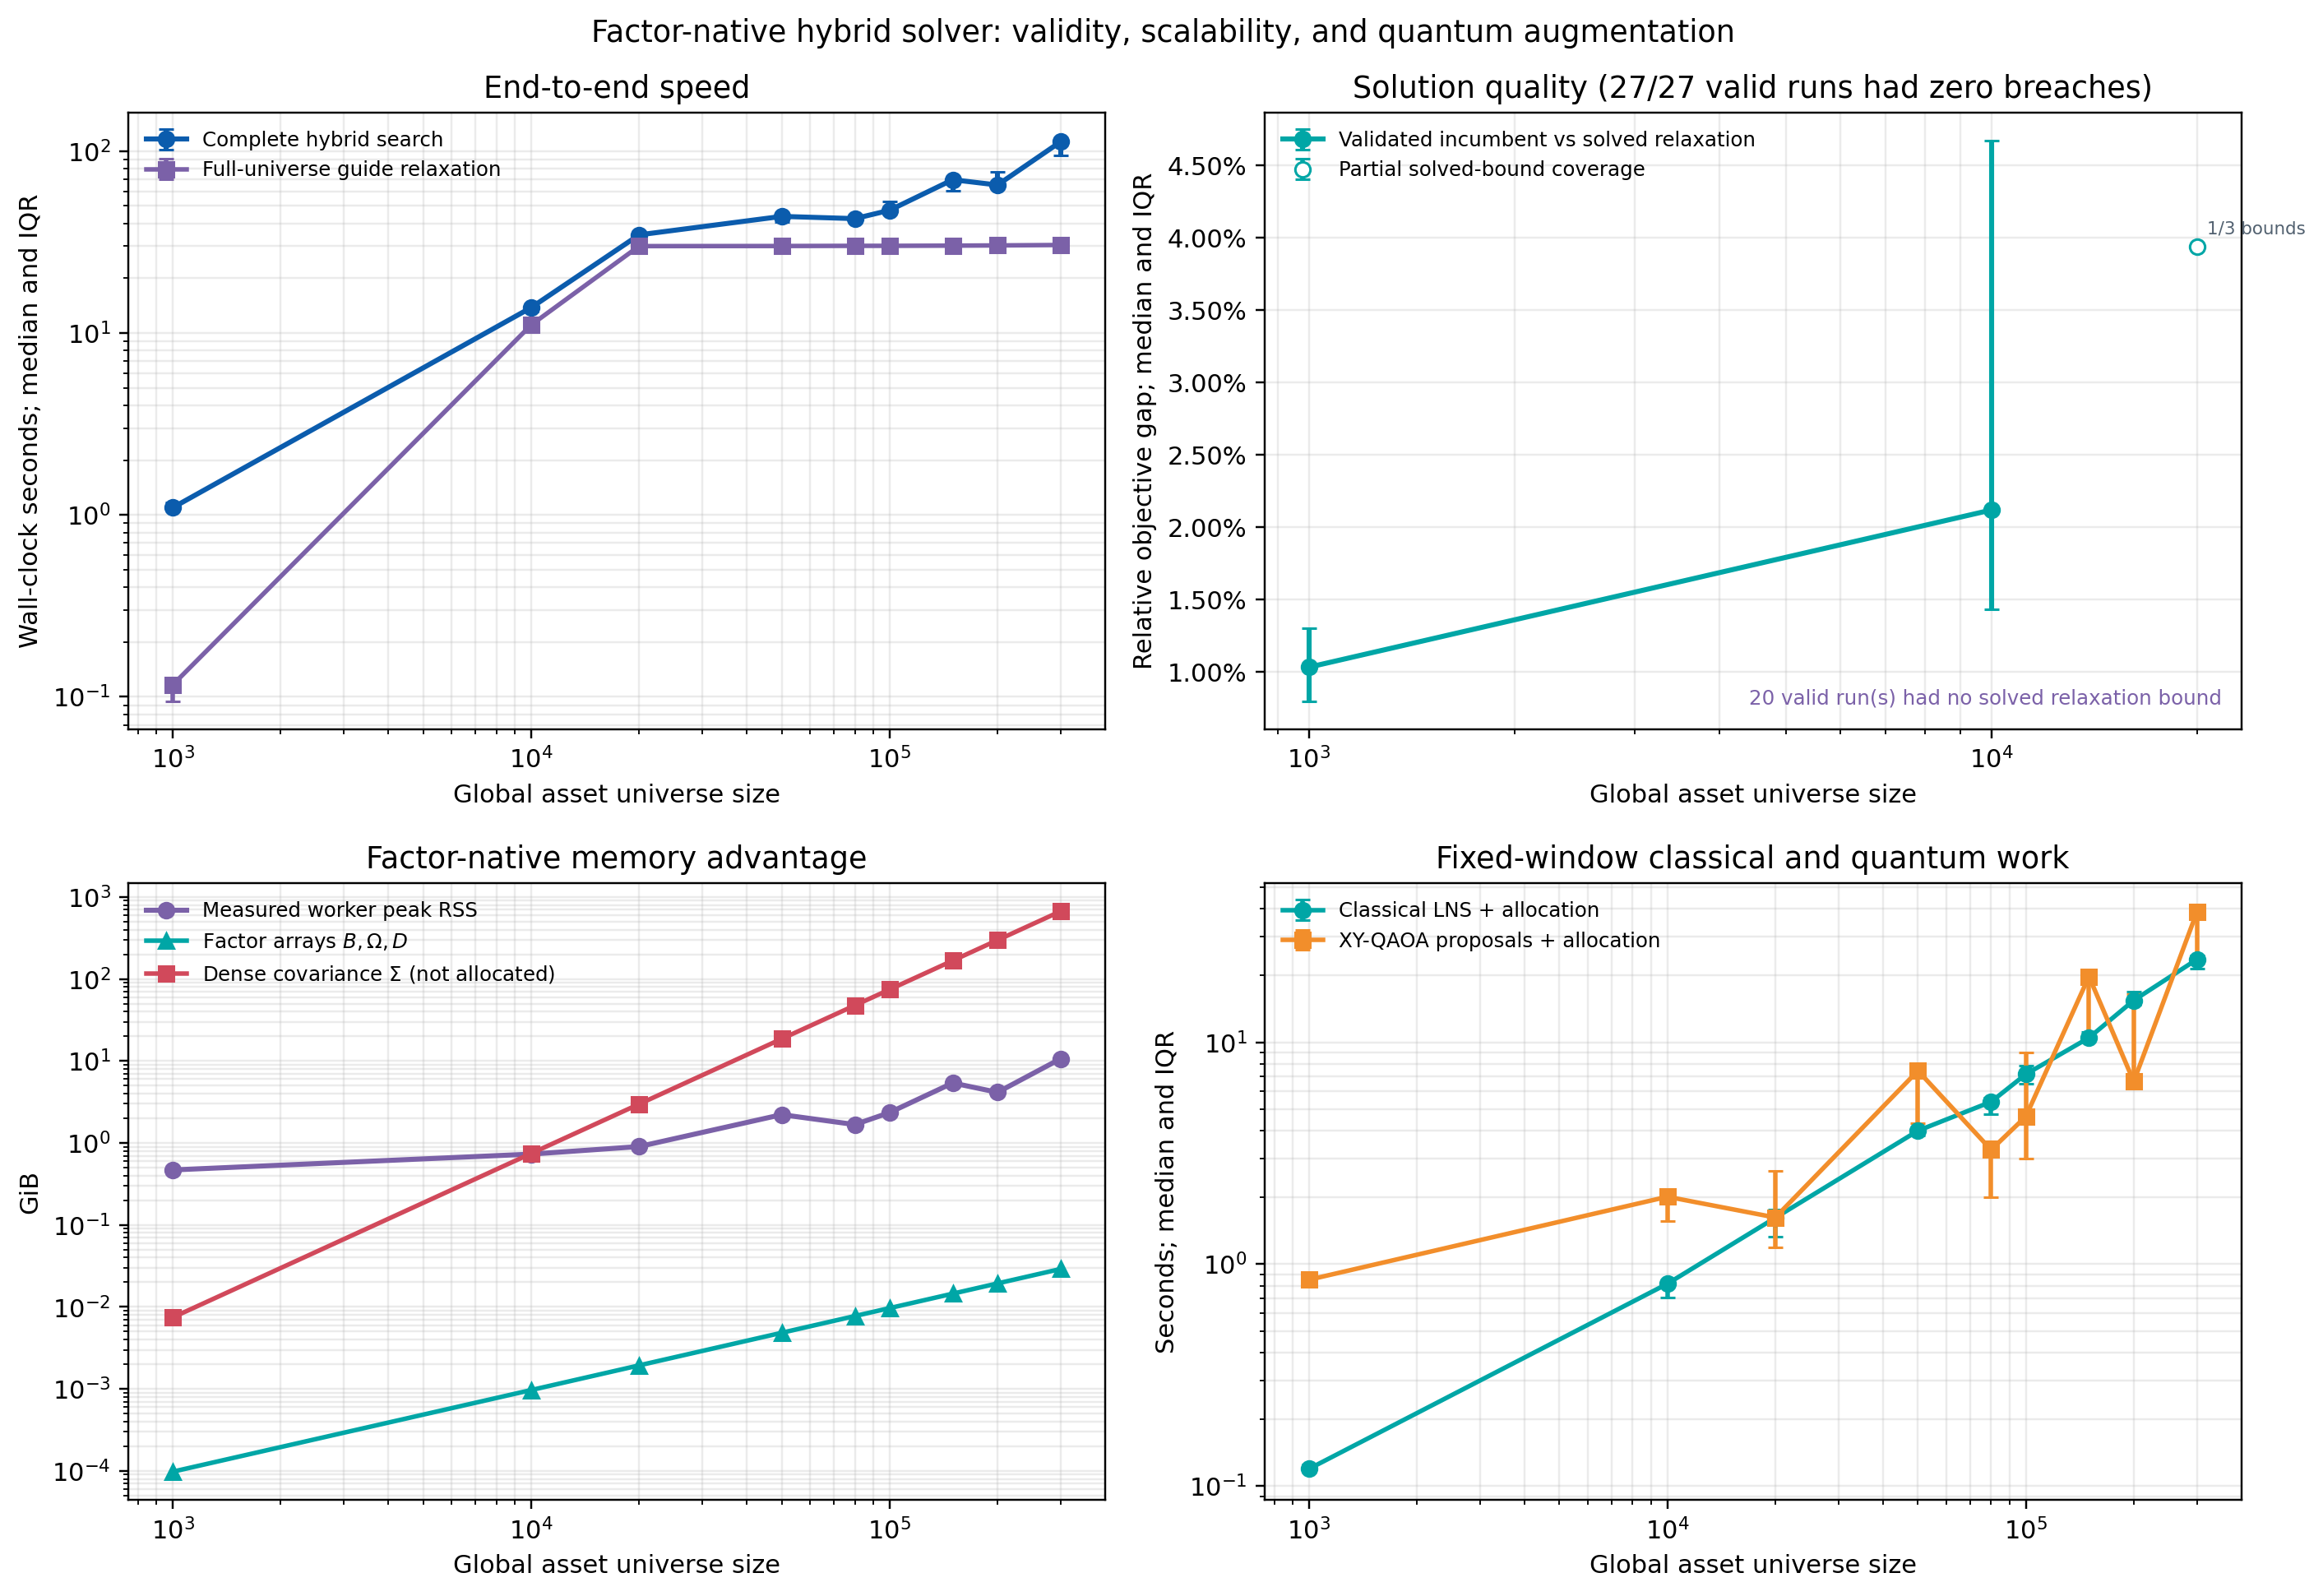

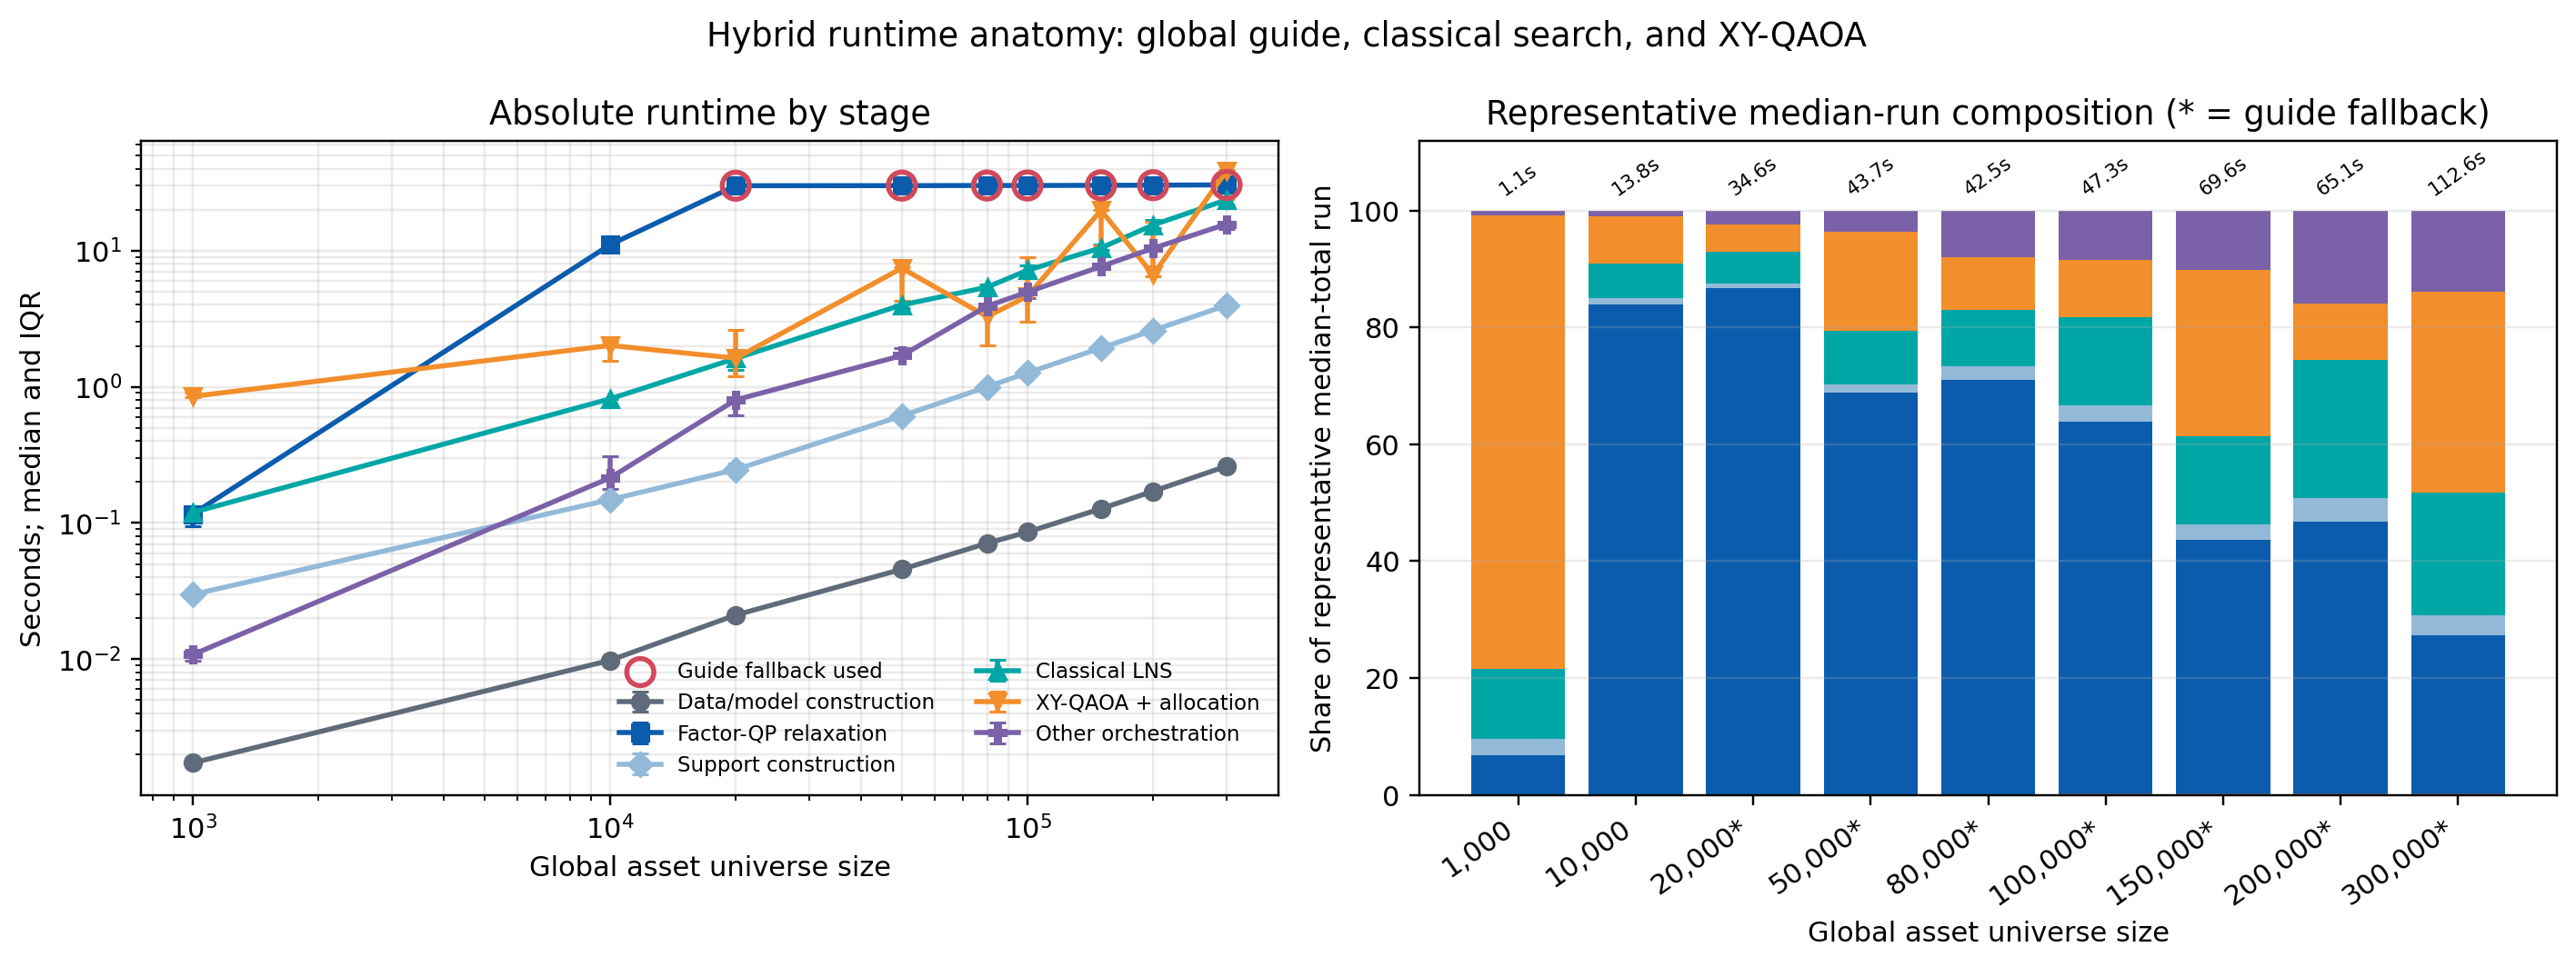

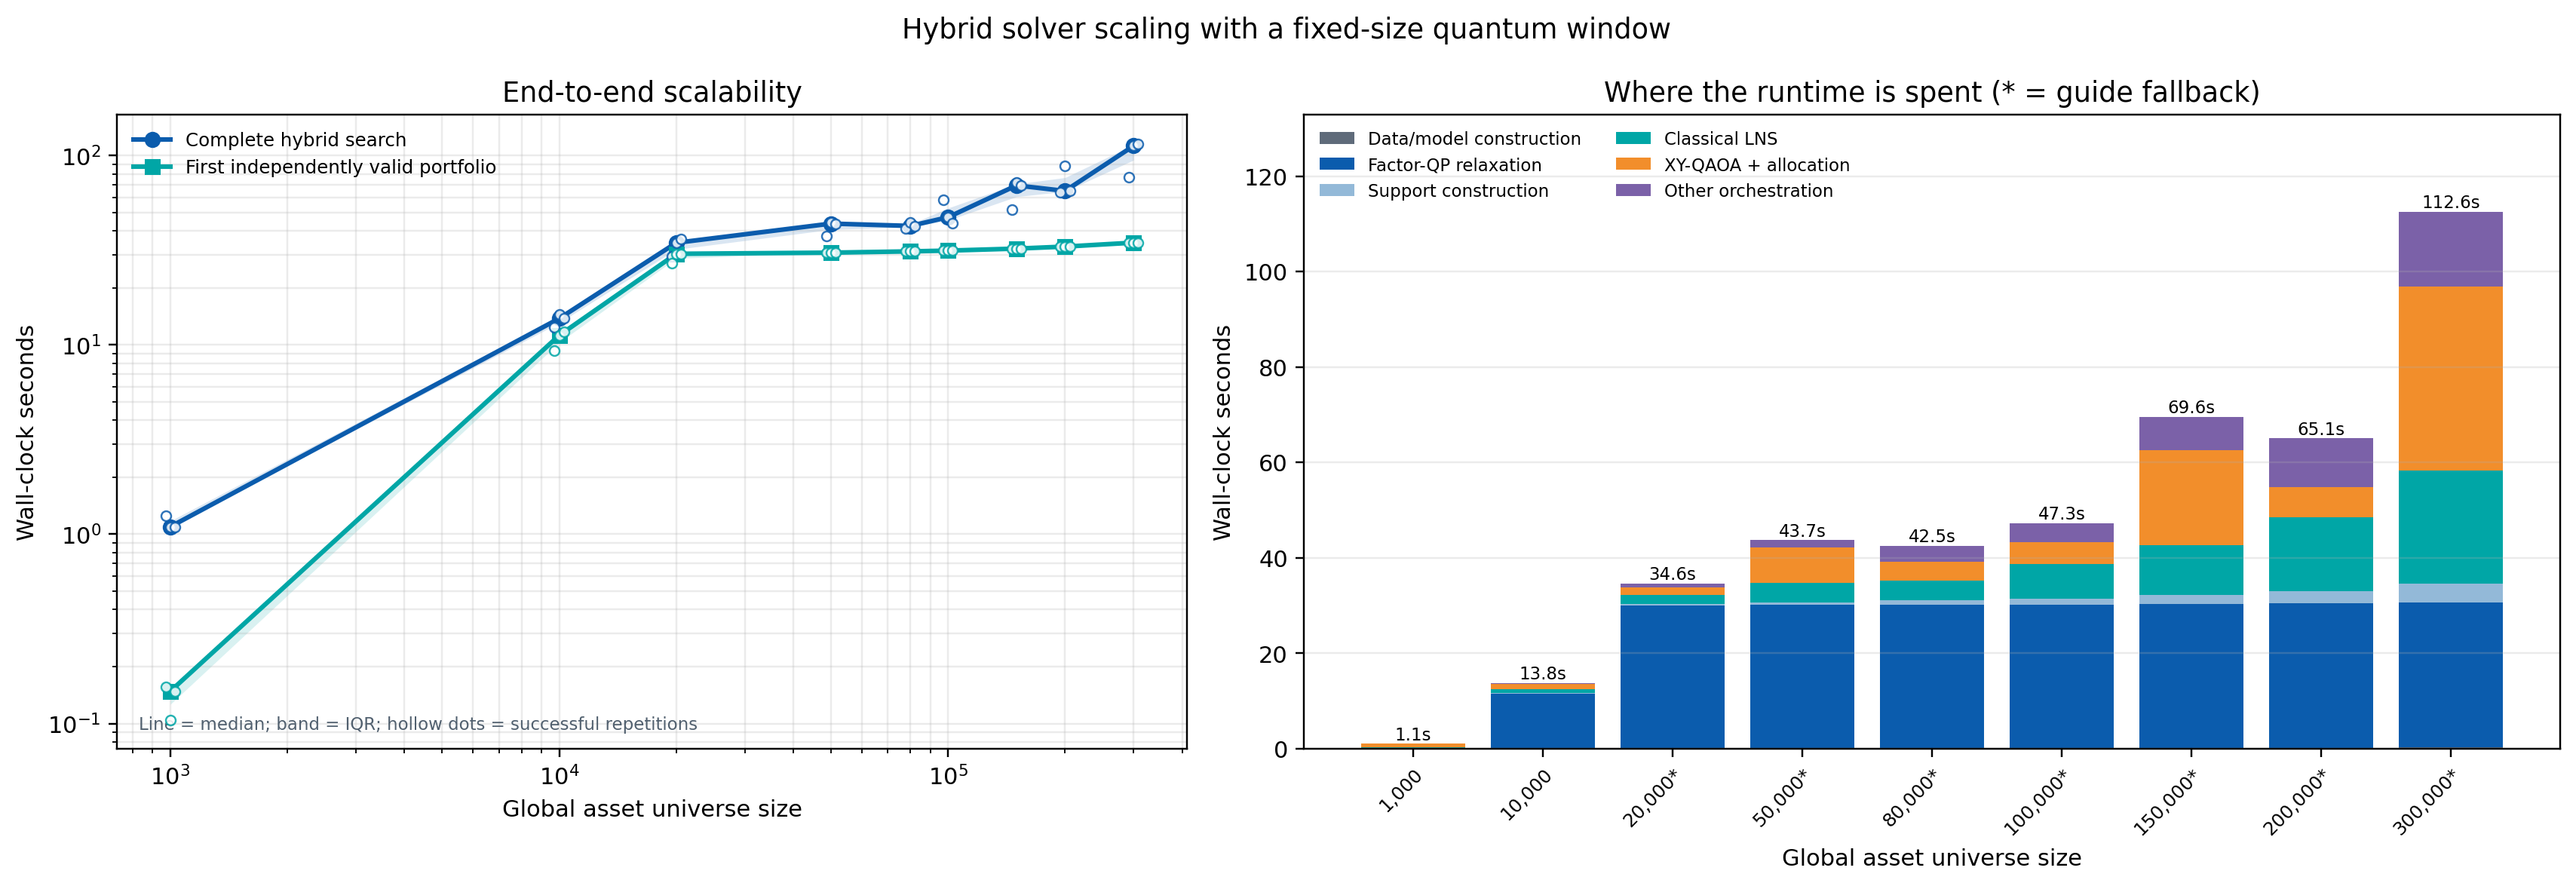

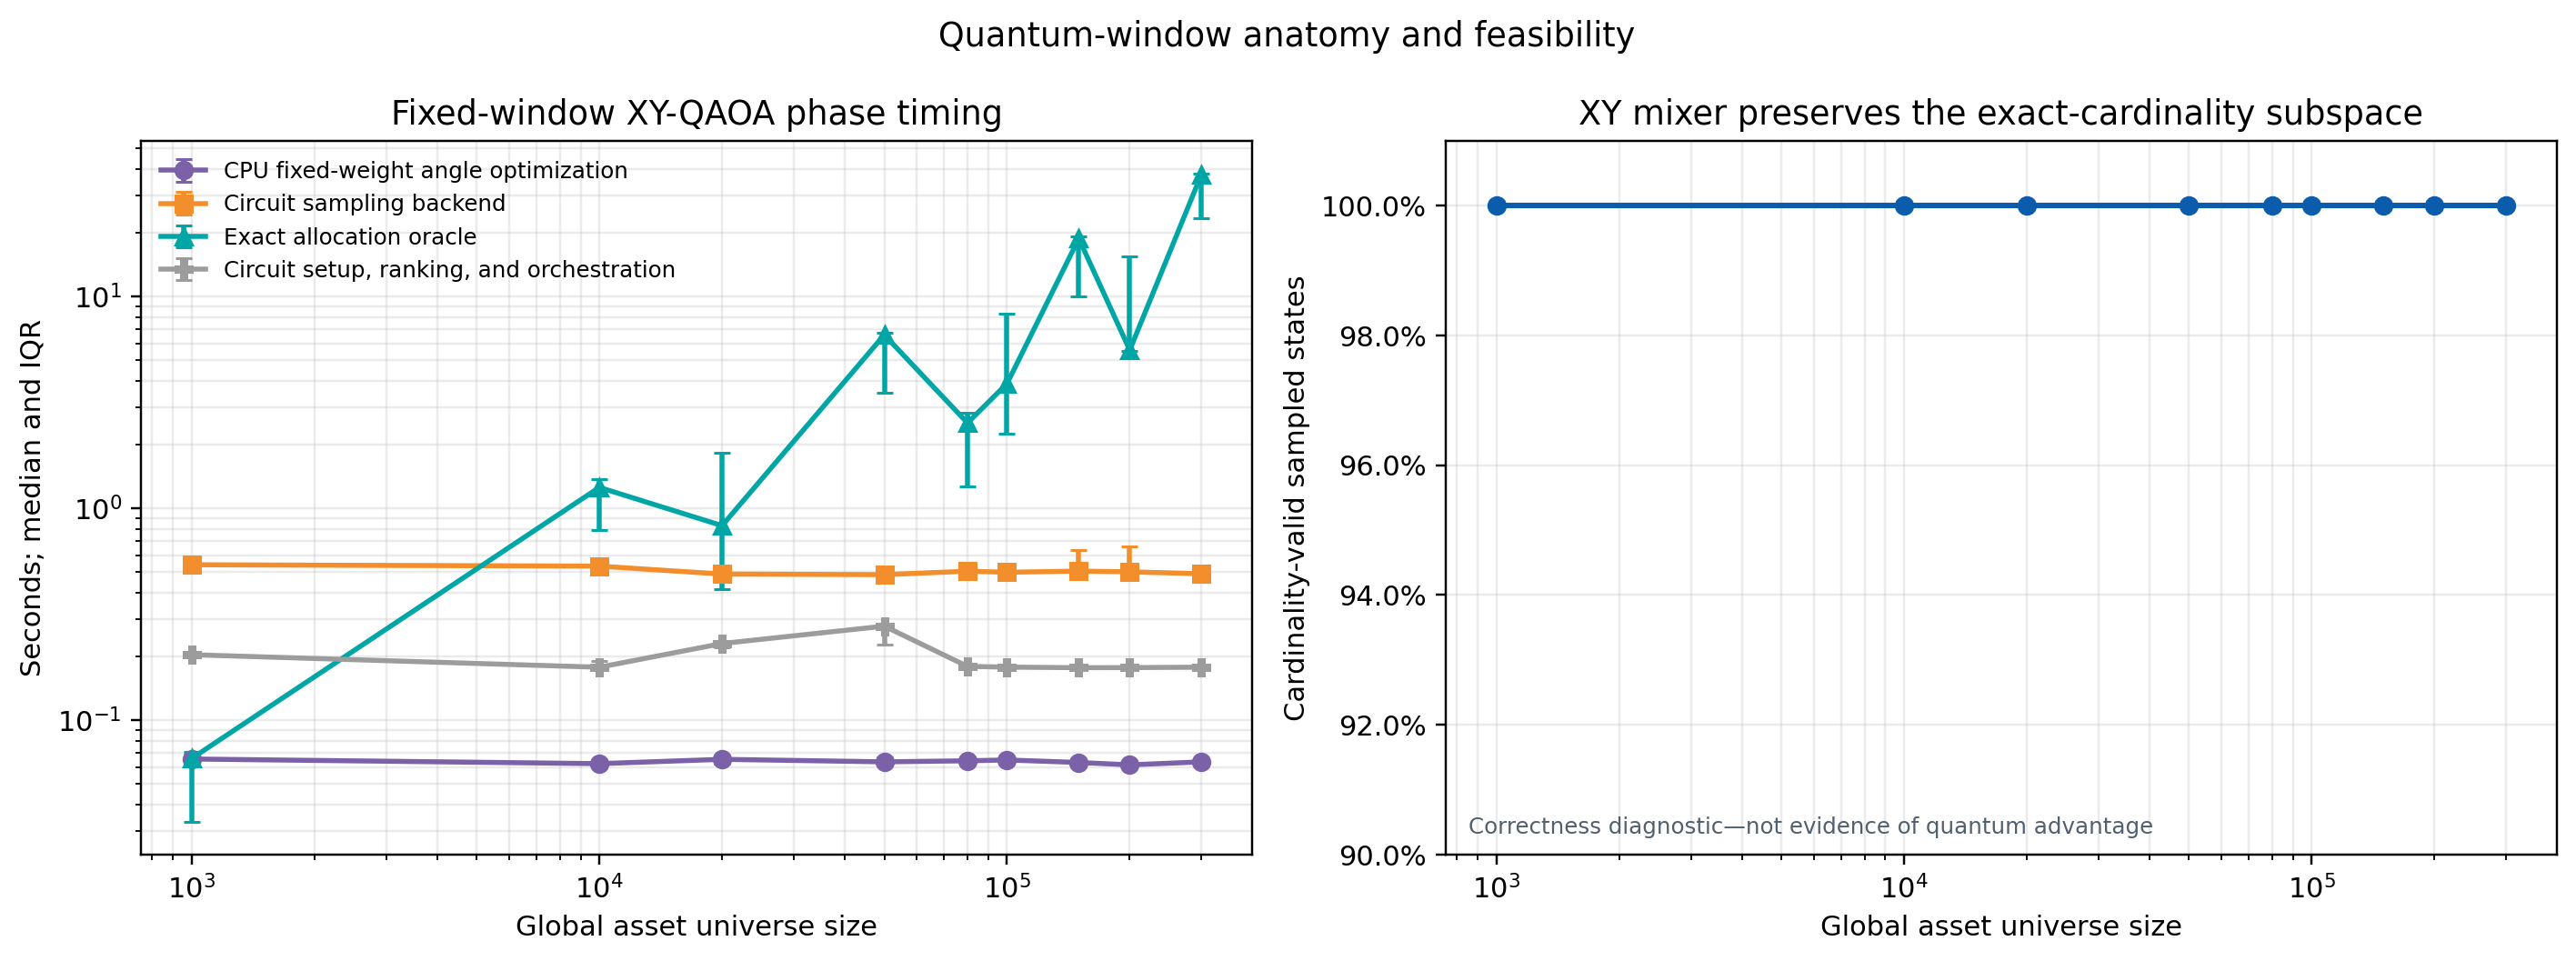

In [30]:
def run_scaling_study(
    *,
    label: str,
    sizes: list[int],
    repetitions: int,
    quantum_backend: str,
) -> tuple[int, Path]:
    output = OUTPUT_ROOT / label
    command = [
        sys.executable,
        str(REPO / "scripts" / "run_hybrid_scaling.py"),
        "--sizes",
        *[str(size) for size in sizes],
        "--repetitions",
        str(repetitions),
        "--cardinality",
        str(SCALING_CARDINALITY),
        "--groups",
        "10",
        "--factors",
        "12",
        "--window-size",
        str(SCALING_WINDOW_SIZE),
        "--iterations",
        "1",
        "--backend",
        ALLOCATION_BACKEND,
        "--relaxation-tolerance",
        str(QP_TOLERANCE),
        "--relaxation-max-iter",
        str(QP_MAX_ITERATIONS),
        "--relaxation-time-limit",
        str(GUIDE_TIME_LIMIT_SECONDS),
        "--allocation-tolerance",
        str(QP_TOLERANCE),
        "--allocation-max-iter",
        str(QP_MAX_ITERATIONS),
        "--case-time-limit",
        str(SCALING_CASE_TIME_LIMIT),
        "--minimum-active-weight",
        "0.005",
        "--maximum-weight",
        "0.04",
        "--max-turnover",
        "0.40",
        "--initial-trials",
        "200",
        "--initial-milp-time-limit",
        "45",
        "--classical-tabu-iterations",
        "30",
        "--classical-tabu-tenure",
        "8",
        "--classical-oracle-candidates",
        "1",
        "--enumerate-windows-up-to",
        "100",
        "--no-gurobi",
        "--certification-max-assets",
        "0",
        "--seed",
        str(BASE_SEED),
        "--allow-failures",
        "--output",
        str(output),
        "--quantum",
        "--quantum-backend",
        quantum_backend,
        "--quantum-depth",
        "1",
        "--quantum-shots",
        str(QAOA_SHOTS),
        "--quantum-optimizer-maxiter",
        str(QAOA_OPTIMIZER_MAXITER),
        "--quantum-optimizer-starts",
        str(QAOA_OPTIMIZER_STARTS),
        "--quantum-top-candidates",
        str(QAOA_TOP_CANDIDATES),
        "--maximum-subspace-states",
        str(QAOA_MAX_SUBSPACE_STATES),
        "--maximum-quantum-edges",
        str(QAOA_MAX_EDGES),
        "--transpile-optimization-level",
        str(TRANSPILE_OPTIMIZATION_LEVEL),
    ]
    command.append(
        "--relaxation-fallback"
        if ALLOW_GUIDE_FALLBACK
        else "--no-relaxation-fallback"
    )
    runs_path = output / "scaling_runs.csv"
    had_checkpoint = runs_path.is_file()
    if had_checkpoint:
        command.append("--resume")

    print(" ".join(command))
    completed = subprocess.run(command, cwd=REPO, check=False)
    if completed.returncode == 3 and had_checkpoint and OVERWRITE_OUTPUTS:
        print(
            "Checkpoint settings or schema changed; rerunning this generated "
            "scaling directory from scratch."
        )
        command = [argument for argument in command if argument != "--resume"]
        command.append("--overwrite")
        print(" ".join(command))
        completed = subprocess.run(command, cwd=REPO, check=False)
    if completed.returncode != 0:
        raise RuntimeError(
            f"Scaling runner exited with code {completed.returncode}; "
            "inspect the messages above before using old checkpoints."
        )
    if not runs_path.is_file():
        raise RuntimeError(f"Scaling study did not write {runs_path}")
    return completed.returncode, output


global_scaling_runs = global_scaling_summary = None
RISK_REPRESENTATION_PROJECTION_SIZES = np.unique(
    np.geomspace(250, 10_000_000, 80).astype(int)
)

if RUN_SCALING_PRESENTATION:
    _, core_output = run_scaling_study(
        label="05_scaling_core_repeated",
        sizes=GLOBAL_CORE_SIZES,
        repetitions=SCALING_REPETITIONS,
        quantum_backend=LOCAL_QUANTUM_BACKEND,
    )
    frames = []
    core_checkpoint_runs = pd.read_csv(core_output / "scaling_runs.csv")
    core_runs = core_checkpoint_runs[
        core_checkpoint_runs["n_assets"].isin(GLOBAL_CORE_SIZES)
        & (pd.to_numeric(core_checkpoint_runs["repetition"], errors="coerce")
           < SCALING_REPETITIONS)
    ].copy()
    core_runs["measurement_tier"] = "repeated core"
    frames.append(core_runs)

    if RUN_SCALING_STRETCH:
        legacy_stretch_runs = core_checkpoint_runs[
            core_checkpoint_runs["n_assets"].isin(GLOBAL_STRETCH_SIZES)
            & (pd.to_numeric(
                core_checkpoint_runs["repetition"], errors="coerce"
            ) < SCALING_STRETCH_REPETITIONS)
            & core_checkpoint_runs["success"].eq(True)
        ].copy()
        completed_legacy_sizes = set(
            pd.to_numeric(legacy_stretch_runs["n_assets"]).astype(int)
        )
        missing_stretch_sizes = [
            size
            for size in GLOBAL_STRETCH_SIZES
            if size not in completed_legacy_sizes
        ]
        stretch_frames = []
        if missing_stretch_sizes:
            _, stretch_output = run_scaling_study(
                label="06_scaling_large_stretch",
                sizes=missing_stretch_sizes,
                repetitions=SCALING_STRETCH_REPETITIONS,
                quantum_backend=LOCAL_QUANTUM_BACKEND,
            )
            stretch_checkpoint_runs = pd.read_csv(
                stretch_output / "scaling_runs.csv"
            )
            stretch_frames.append(
                stretch_checkpoint_runs[
                    stretch_checkpoint_runs["n_assets"].isin(
                        GLOBAL_STRETCH_SIZES
                    )
                    & (pd.to_numeric(
                        stretch_checkpoint_runs["repetition"],
                        errors="coerce",
                    ) < SCALING_STRETCH_REPETITIONS)
                ].copy()
            )
        stretch_frames.append(legacy_stretch_runs)
        stretch_runs = pd.concat(stretch_frames, ignore_index=True)
        stretch_runs = stretch_runs.drop_duplicates(
            ["n_assets", "repetition", "seed"], keep="last"
        )
        stretch_runs["measurement_tier"] = "time-limited stretch"
        frames.append(stretch_runs)

    global_scaling_runs = pd.concat(frames, ignore_index=True)
    successful = global_scaling_runs[global_scaling_runs["success"] == True].copy()
    if successful.empty:
        raise RuntimeError("No successful global scaling cases were produced")
    provenance_columns = {"scaling_schema_version", "case_config_sha256"}
    missing_provenance = provenance_columns - set(successful.columns)
    if missing_provenance:
        raise RuntimeError(
            f"Scaling checkpoints predate provenance validation: "
            f"{sorted(missing_provenance)}. Rerun the scaling cell once."
        )
    if successful["case_config_sha256"].nunique() != 1:
        raise RuntimeError(
            "Scaling checkpoints contain incompatible experiment settings; "
            "use a fresh output directory or allow the notebook to overwrite them."
        )

    summary_rows = []
    for (tier, n_assets), group in global_scaling_runs.groupby(
        ["measurement_tier", "n_assets"], sort=True
    ):
        successful_group = group[group["success"] == True]
        row = {
            "measurement_tier": tier,
            "n_assets": int(n_assets),
            "runs": len(group),
            "successful_runs": len(successful_group),
            "success_rate": len(successful_group) / max(len(group), 1),
            "scaling_schema_version": (
                int(successful_group["scaling_schema_version"].iloc[0])
                if not successful_group.empty else np.nan
            ),
            "case_config_sha256": (
                str(successful_group["case_config_sha256"].iloc[0])
                if not successful_group.empty else ""
            ),
            "failure_reason": " | ".join(
                sorted(
                    {
                        str(value)
                        for value in group.loc[group["success"] != True, "error"].dropna()
                        if str(value).strip()
                    }
                )
            ),
        }
        if successful_group.empty:
            summary_rows.append(row)
            continue
        dense_gib = int(n_assets) ** 2 * np.dtype(np.float64).itemsize / 1024.0**3
        factor_gib = float(successful_group["factor_risk_storage_mib"].median()) / 1024.0
        accepted_gaps = pd.to_numeric(
            successful_group["relative_gap_to_relaxation"], errors="coerce"
        ).dropna()
        row.update(
            {
                "search_seconds_median": float(
                    successful_group["search_end_to_end_seconds"].median()
                ),
                "peak_rss_gib_median": float(successful_group["peak_rss_gib"].median()),
                "factor_risk_gib": factor_gib,
                "dense_covariance_gib": dense_gib,
                "dense_to_factor_ratio": dense_gib / factor_gib,
                "zero_breach_rate": float((successful_group["breaches"] == 0).mean()),
                "relaxation_acceptance_rate": float(
                    successful_group["relaxation_accepted"].mean()
                ),
                "relaxation_bound_rate": float(
                    successful_group["relaxation_bound_available"].mean()
                ),
                "relaxation_bound_runs": int(
                    successful_group["relaxation_bound_available"].sum()
                ),
                "relaxation_fallback_rate": float(
                    successful_group["relaxation_fallback_used"].mean()
                ),
                "relative_gap_to_relaxation_median": (
                    float(accepted_gaps.median()) if not accepted_gaps.empty else np.nan
                ),
                "relaxation_iterations_median": float(
                    successful_group["relaxation_iterations"].median()
                ),
                "relaxation_requested_tolerance": float(
                    successful_group["relaxation_requested_tolerance"].iloc[0]
                ),
                "relaxation_native_tolerance": float(
                    successful_group["relaxation_native_tolerance"].iloc[0]
                ),
            }
        )
        summary_rows.append(row)
    global_scaling_summary = pd.DataFrame(summary_rows).sort_values(
        ["measurement_tier", "n_assets"]
    )
    display(global_scaling_summary)

    combined_output = OUTPUT_ROOT / "05_global_scaling_summary"
    clean_directory(combined_output)
    global_scaling_summary.to_csv(
        combined_output / "global_scaling_summary.csv", index=False
    )

    scaling_plotter_path = REPO / "scripts" / "run_hybrid_scaling.py"
    scaling_plotter_spec = importlib.util.spec_from_file_location(
        "vanguard_scaling_plotter", scaling_plotter_path
    )
    if scaling_plotter_spec is None or scaling_plotter_spec.loader is None:
        raise RuntimeError(f"Could not load {scaling_plotter_path}")
    scaling_plotter = importlib.util.module_from_spec(scaling_plotter_spec)
    scaling_plotter_spec.loader.exec_module(scaling_plotter)
    combined_scaling_records = json.loads(
        global_scaling_runs.to_json(orient="records")
    )
    combined_scaling_plots = scaling_plotter.create_scaling_plots(
        combined_scaling_records, combined_output
    )
    for plot_path in combined_scaling_plots:
        if plot_path.suffix == ".png":
            display(NotebookImage(filename=str(plot_path)))

    factors = 12
    projected_n = RISK_REPRESENTATION_PROJECTION_SIZES.astype(np.float64)
    projection = pd.DataFrame(
        {
            "n_assets": projected_n.astype(np.int64),
            "factor_risk_gib": (
                8.0 * (projected_n * factors + factors**2 + projected_n) / 1024.0**3
            ),
            "dense_covariance_gib": 8.0 * projected_n**2 / 1024.0**3,
        }
    )
    projection["dense_to_factor_ratio"] = (
        projection["dense_covariance_gib"] / projection["factor_risk_gib"]
    )
    projection.to_csv(
        combined_output / "risk_representation_projection.csv", index=False
    )

    figure, axis = plt.subplots(figsize=(8.4, 5.4))
    axis.plot(
        projection["n_assets"],
        projection["factor_risk_gib"],
        linewidth=2.2,
        color="#00A6A6",
        label=r"Factor representation $B,\Omega,D$",
    )
    axis.plot(
        projection["n_assets"],
        projection["dense_covariance_gib"],
        linewidth=2.2,
        color="#D1495B",
        label=r"Dense covariance $\Sigma$",
    )
    measured_rows = global_scaling_summary[
        global_scaling_summary["successful_runs"] > 0
    ]
    axis.scatter(
        measured_rows["n_assets"],
        measured_rows["factor_risk_gib"],
        color="#0B5CAD",
        s=35,
        zorder=3,
        label="Measured factor-array bytes",
    )
    measured_maximum = int(measured_rows["n_assets"].max())
    axis.axvline(measured_maximum, color="black", linestyle=":", linewidth=1.0)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Asset universe size")
    axis.set_ylabel("GiB")
    axis.set_title("Risk storage: measured factor arrays and analytical projection")
    axis.grid(alpha=0.25, which="both")
    axis.legend(frameon=False)
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            combined_output / f"factor_vs_dense_memory.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()


## 11A. IBM QPU hardware frontier and noise-management ablation

**Experiment.** Two controlled IBM SamplerV2 campaigns reuse CPU-trained
XY-QAOA angles on the same frozen portfolio window:

1. **Noise-management ablation:** two boundary circuits are each run with an
   unmitigated baseline, DD (XX), DD (XpXm), gate twirling, measurement
   twirling, and the combined treatment. Every treatment is paired with the
   same logical problem and repetition index.
2. **Width/depth frontier:** ten unmitigated circuits vary the quantum-window
   width F=8...28 and QAOA depth p=1...3. The experiment records
   fixed-cardinality survival, postselected CVaR tail quality, compiled depth,
   native two-qubit gates, calibration exposure, job IDs, and timing metadata.

**Importance.** The ablation asks whether a noise-management method improves
the QPU relative to the same unmitigated circuit. The frontier asks where useful
fixed-cardinality structure disappears as circuits become wider or deeper.
Neither comparison alone establishes quantum advantage: all sampled supports
still pass through the same classical continuous allocator and validator.

**Execution safety.** `RUN_IBM_QPU=False` is the committed default. With
`QPU_RESUME=True`, saved counts and job metadata are reanalysed without a new
submission. Fractional gates are disabled because they were not part of the
successful evidence and IBM Runtime does not allow gate twirling with
fractional gates in the same job.

**Primary outputs.** Raw CSV/count manifests plus diagnostic hardware,
ablation, frontier, timing, and calibration-repeat figures. Section 11B turns
those diagnostics into the final, fairness-controlled submission evidence.

In [31]:
def _json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if hasattr(value, "isoformat"):
        return value.isoformat()
    return str(value)


def _write_json(path: Path, payload) -> None:
    path.write_text(
        json.dumps(payload, indent=2, sort_keys=True, default=_json_default) + "\n",
        encoding="utf-8",
    )


def _backend_name(backend) -> str:
    value = getattr(backend, "name", "")
    return str(value() if callable(value) else value)


def _calibration_timestamp(backend) -> str:
    try:
        updated = backend.properties().last_update_date
        return updated.isoformat() if hasattr(updated, "isoformat") else str(updated)
    except Exception:  # noqa: BLE001 - calibration metadata is optional
        return ""


def _pending_jobs(backend) -> int:
    try:
        return int(backend.status().pending_jobs)
    except Exception:  # noqa: BLE001 - queue metadata is optional
        return -1


def _qubo_fingerprint(qubo) -> str:
    digest = hashlib.sha256()
    digest.update(np.asarray(qubo.linear, dtype=np.float64).tobytes())
    digest.update(np.asarray(qubo.quadratic, dtype=np.float64).tobytes())
    digest.update(np.asarray([qubo.offset], dtype=np.float64).tobytes())
    digest.update(str(qubo.required_ones).encode("utf-8"))
    return digest.hexdigest()


def _circuit_fingerprint(circuit) -> str:
    instructions = []
    for item in circuit.data:
        params = []
        for value in item.operation.params:
            try:
                params.append(round(float(value), 14))
            except (TypeError, ValueError):
                params.append(str(value))
        instructions.append(
            {
                "name": item.operation.name,
                "qubits": [circuit.find_bit(qubit).index for qubit in item.qubits],
                "clbits": [circuit.find_bit(bit).index for bit in item.clbits],
                "params": params,
            }
        )
    payload = json.dumps(instructions, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _wilson_interval(successes: int, trials: int, z: float = 1.96) -> tuple[float, float]:
    if trials <= 0:
        return np.nan, np.nan
    rate = successes / trials
    denominator = 1.0 + z * z / trials
    center = (rate + z * z / (2.0 * trials)) / denominator
    half = (
        z * math.sqrt(rate * (1.0 - rate) / trials + z * z / (4.0 * trials * trials)) / denominator
    )
    return max(center - half, 0.0), min(center + half, 1.0)


def _instruction_error(backend, name: str, qubits: tuple[int, ...]) -> float | None:
    try:
        properties = backend.target[name].get(qubits)
        value = None if properties is None else properties.error
        if value is None or not np.isfinite(float(value)):
            return None
        return min(max(float(value), 0.0), 1.0 - 1.0e-15)
    except Exception:  # noqa: BLE001 - not every instruction has calibration data
        return None


def _circuit_stats(circuit, backend) -> dict[str, object]:
    operations = {str(name): int(count) for name, count in circuit.count_ops().items()}
    two_qubit_gates = 0
    all_log_error = 0.0
    two_qubit_log_error = 0.0
    readout_log_error = 0.0
    calibrated_operations = 0

    for item in circuit.data:
        name = str(item.operation.name)
        if name in {"barrier", "delay"}:
            continue
        qubits = tuple(circuit.find_bit(qubit).index for qubit in item.qubits)
        if len(qubits) == 2:
            two_qubit_gates += 1
        error = _instruction_error(backend, name, qubits)
        if error is None:
            continue
        exposure = -math.log1p(-error)
        all_log_error += exposure
        calibrated_operations += 1
        if len(qubits) == 2:
            two_qubit_log_error += exposure
        if name == "measure":
            readout_log_error += exposure

    # This is a circuit-selection proxy under an independent-error assumption,
    # not a measured fidelity and not an error-mitigated result.
    success_proxy = math.exp(-all_log_error) if calibrated_operations > 0 else np.nan
    return {
        "transpiled_depth": int(circuit.depth()),
        "transpiled_size": int(circuit.size()),
        "two_qubit_gates": int(two_qubit_gates),
        "operations_json": json.dumps(operations, sort_keys=True),
        "calibrated_operations": calibrated_operations,
        "calibration_available": calibrated_operations > 0,
        "calibrated_log_error_exposure": all_log_error,
        "two_qubit_log_error_exposure": two_qubit_log_error,
        "readout_log_error_exposure": readout_log_error,
        "independent_error_success_proxy": success_proxy,
        "circuit_sha256": _circuit_fingerprint(circuit),
    }


def _best_transpilation(
    logical_circuit,
    backend,
    seeds,
) -> tuple[object, dict[str, object], list[dict[str, object]]]:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    candidates = []
    for seed in seeds:
        manager = generate_preset_pass_manager(
            backend=backend,
            optimization_level=int(TRANSPILE_OPTIMIZATION_LEVEL),
            seed_transpiler=int(seed),
        )
        started = time.perf_counter()
        isa = manager.run(logical_circuit)
        stats = _circuit_stats(isa, backend)
        stats.update(
            {
                "transpile_seed": int(seed),
                "transpile_seconds": time.perf_counter() - started,
            }
        )
        # Calibration exposure is primary; native 2Q count and depth break ties.
        score = (
            0 if int(stats["calibrated_operations"]) > 0 else 1,
            float(stats["calibrated_log_error_exposure"]),
            int(stats["two_qubit_gates"]),
            int(stats["transpiled_depth"]),
        )
        candidates.append((score, isa, stats))
    _, best_circuit, best_stats = min(candidates, key=lambda item: item[0])
    return best_circuit, best_stats, [dict(item[2]) for item in candidates]


def _ideal_distribution(qubo, initial_bits: np.ndarray, angles: np.ndarray) -> dict[str, object]:
    integers, basis_bits, _, pairs = _fixed_weight_structure(
        qubo.n,
        qubo.required_ones,
        "ring",
    )
    energies = _basis_energies(qubo, basis_bits)
    center = float(np.mean(energies))
    scale = max(float(np.std(energies)), float(np.ptp(energies)) / 10.0, 1.0e-12)
    normalized = (energies - center) / scale
    initial = np.zeros(len(integers), dtype=complex)
    integer = np.uint64(sum(int(value) << index for index, value in enumerate(initial_bits)))
    location = int(np.searchsorted(integers, integer))
    initial[location] = 1.0
    state = _subspace_state(normalized, list(pairs), angles, initial)
    probabilities = np.square(np.abs(state))
    probabilities /= probabilities.sum()
    return {
        "basis_bits": basis_bits,
        "energies": energies,
        "probabilities": probabilities,
        "expected_energy": float(probabilities @ energies),
    }


def _noise_modes_for_preset() -> tuple[str, ...]:
    if QPU_STRESS_PRESET == "ablation":
        return tuple(QPU_STRESS_ABLATION_MODES)
    selected = str(QPU_STRESS_FRONTIER_BEST_MODE)
    allowed = set(QPU_STRESS_ABLATION_MODES)
    if selected not in allowed:
        raise ValueError(
            f"QPU_STRESS_FRONTIER_BEST_MODE={selected!r} is not one of {sorted(allowed)}"
        )
    return ("baseline",) if selected == "baseline" else ("baseline", selected)


def _sampler_options(mode: str) -> dict[str, object]:
    options: dict[str, object] = {
        "default_shots": int(QPU_STRESS_SHOTS),
        "max_execution_time": int(QPU_STRESS_MAX_EXECUTION_SECONDS),
        "environment": {
            "job_tags": [
                "vanguard-wiser",
                QPU_STRESS_CAMPAIGN,
                str(mode).replace("_", "-"),
            ]
        },
    }
    if mode in {"baseline", "fractional_baseline"}:
        return options
    if mode == "dd_xx":
        options["dynamical_decoupling"] = {"enable": True, "sequence_type": "XX"}
    elif mode == "dd_xpxm":
        options["dynamical_decoupling"] = {"enable": True, "sequence_type": "XpXm"}
    elif mode == "gate_twirling":
        options["twirling"] = {
            "enable_gates": True,
            "enable_measure": False,
            "num_randomizations": "auto",
            "shots_per_randomization": "auto",
        }
    elif mode == "measure_twirling":
        options["twirling"] = {
            "enable_gates": False,
            "enable_measure": True,
            "num_randomizations": "auto",
            "shots_per_randomization": "auto",
        }
    elif mode == "dd_xpxm_gate_measure":
        options["dynamical_decoupling"] = {"enable": True, "sequence_type": "XpXm"}
        options["twirling"] = {
            "enable_gates": True,
            "enable_measure": True,
            "num_randomizations": "auto",
            "shots_per_randomization": "auto",
        }
    else:
        raise ValueError(f"Unknown noise-management mode {mode!r}")
    return options


def _bitstring_key(bits: np.ndarray) -> str:
    return "".join(str(int(value)) for value in np.asarray(bits, dtype=int))


def _best_known_reference(qubo, initial_bits: np.ndarray, seed: int) -> dict[str, object]:
    """Return exact states when tractable, otherwise a labelled local-search bound."""
    state_count = comb(qubo.n, qubo.required_ones)
    keep = max(int(QPU_STRESS_REFERENCE_KEEP), int(QPU_STRESS_TOP_CANDIDATES))
    if state_count <= int(QPU_STRESS_MAX_EXACT_STATES):
        exact = exact_qubo_top_states(
            qubo,
            top_k=min(keep, state_count),
            maximum_states=max(int(QPU_STRESS_MAX_EXACT_STATES), state_count),
        )
        if exact is None:
            raise RuntimeError("Exact QUBO enumeration unexpectedly returned no result")
        return {
            "reference_type": "exact_enumeration",
            "certified": True,
            "best_energy": float(exact["best_energy"]),
            "top_bitstrings": [
                np.asarray(bits, dtype=int) for bits in exact["top_bitstrings"][:keep]
            ],
            "states_examined": int(state_count),
        }

    candidates: dict[str, tuple[float, np.ndarray]] = {}

    def retain(bits: np.ndarray, energy: float | None = None) -> None:
        x = np.asarray(bits, dtype=int).reshape(qubo.n)
        key = _bitstring_key(x)
        if key not in candidates:
            value = float(qubo.energy(x)) if energy is None else float(energy)
            candidates[key] = (value, x.copy())

    retain(initial_bits)
    random_pool = random_fixed_weight_states(
        qubo.n,
        qubo.required_ones,
        int(QPU_STRESS_REFERENCE_RANDOM_STATES),
        int(seed) + 1,
    )
    random_matrix = np.asarray(random_pool, dtype=np.uint8)
    random_energies = _basis_energies(qubo, random_matrix)
    for bits, energy in zip(random_pool, random_energies):
        retain(bits, float(energy))

    starts = [np.asarray(initial_bits, dtype=int).copy()]
    starts.extend(
        np.asarray(bits, dtype=int).copy()
        for bits in random_pool[: int(QPU_STRESS_REFERENCE_RESTARTS)]
    )
    for start in starts:
        current = start.copy()
        current_energy = float(qubo.energy(current))
        qx = qubo.quadratic @ current
        for _ in range(max(8, 3 * qubo.n)):
            selected = np.flatnonzero(current)
            unselected = np.flatnonzero(1 - current)
            donor = selected[:, None]
            receiver = unselected[None, :]
            delta = (
                qubo.linear[receiver]
                - qubo.linear[donor]
                + 2.0 * (qx[receiver] - qx[donor])
                + qubo.quadratic[receiver, receiver]
                + qubo.quadratic[donor, donor]
                - 2.0 * qubo.quadratic[donor, receiver]
            )
            flat = int(np.argmin(delta))
            best_delta = float(delta.ravel()[flat])
            if best_delta >= -1.0e-12:
                break
            donor_position, receiver_position = np.unravel_index(flat, delta.shape)
            donor_index = int(selected[donor_position])
            receiver_index = int(unselected[receiver_position])
            current[donor_index] = 0
            current[receiver_index] = 1
            current_energy += best_delta
            qx = qx - qubo.quadratic[:, donor_index] + qubo.quadratic[:, receiver_index]
            retain(current)

    ordered = sorted(candidates.values(), key=lambda item: (item[0], _bitstring_key(item[1])))
    return {
        "reference_type": "best_known_multistart_swap",
        "certified": False,
        "best_energy": float(ordered[0][0]),
        "top_bitstrings": [item[1] for item in ordered[:keep]],
        "states_examined": int(len(candidates)),
    }


def _sampled_energy_scale(qubo, seed: int) -> tuple[float, float]:
    count = min(
        int(QPU_STRESS_REFERENCE_RANDOM_STATES),
        max(2_000, 500 * int(qubo.n)),
    )
    states = random_fixed_weight_states(
        qubo.n,
        qubo.required_ones,
        count,
        int(seed),
    )
    energies = _basis_energies(qubo, np.asarray(states, dtype=np.uint8))
    center = float(np.mean(energies))
    scale = max(float(np.std(energies)), float(np.ptp(energies)) / 10.0, 1.0e-12)
    return center, scale


def _solve_angle_anchor(depth: int, width: int) -> dict[str, object]:
    anchor_width = min(int(width), 12)
    bundle = make_window_bundle(
        frozen_base,
        anchor_width,
        maximum_edges=int(QPU_STRESS_MAX_EDGES),
    )
    qubo = bundle["qubo"]
    initial_bits = np.asarray(bundle["initial_bits"], dtype=int)
    states = comb(qubo.n, qubo.required_ones)
    config = XYQAOAConfig(
        depth=int(depth),
        shots=min(int(QPU_STRESS_SHOTS), 4_096),
        optimizer_maxiter=int(QPU_STRESS_OPTIMIZER_MAXITER),
        optimizer_starts=int(QPU_STRESS_OPTIMIZER_STARTS),
        seed=BASE_SEED + 70_000 + 100 * int(depth) + int(anchor_width),
        initial_state="warm",
        mixer="ring",
        backend="subspace",
        maximum_subspace_states=max(int(QPU_STRESS_MAX_SIMULATED_STATES), states),
        top_candidates=int(QPU_STRESS_TOP_CANDIDATES),
        transpile_optimization_level=int(TRANSPILE_OPTIMIZATION_LEVEL),
    )
    solved = solve_xy_qaoa(qubo, initial_bits, config)
    return {
        "angles": np.asarray(solved.angles, dtype=float),
        "source": f"F={anchor_width}, p={depth}",
    }


def _prepare_qpu_cases() -> dict[str, dict[str, object]]:
    global frozen_base
    if frozen_base is None:
        frozen_base = prepare_base_state()

    cases: dict[str, dict[str, object]] = {}
    angle_anchors: dict[int, dict[str, object]] = {}
    for width, depth in QPU_STRESS_CASES:
        bundle = make_window_bundle(
            frozen_base,
            int(width),
            maximum_edges=int(QPU_STRESS_MAX_EDGES),
        )
        qubo = bundle["qubo"]
        window = bundle["window"]
        initial_bits = np.asarray(bundle["initial_bits"], dtype=int)
        state_count = comb(qubo.n, qubo.required_ones)
        reference = _best_known_reference(
            qubo,
            initial_bits,
            BASE_SEED + 40_000 + 100 * int(width) + int(depth),
        )
        reference_energy = float(reference["best_energy"])
        warm_energy = float(qubo.energy(initial_bits))
        energy_tolerance = max(1.0e-10, 1.0e-8 * max(abs(reference_energy), 1.0))

        simulated = state_count <= int(QPU_STRESS_MAX_SIMULATED_STATES)
        ideal_optimum_rate = np.nan
        ideal_expected_energy = np.nan
        ideal_energy_quality = np.nan
        ideal_validated_improvement = np.nan
        if simulated:
            config = XYQAOAConfig(
                depth=int(depth),
                shots=int(QPU_STRESS_SHOTS),
                optimizer_maxiter=int(QPU_STRESS_OPTIMIZER_MAXITER),
                optimizer_starts=int(QPU_STRESS_OPTIMIZER_STARTS),
                seed=BASE_SEED + 700 + 100 * int(width) + int(depth),
                initial_state="warm",
                mixer="ring",
                backend="subspace",
                maximum_subspace_states=int(QPU_STRESS_MAX_SIMULATED_STATES),
                top_candidates=int(QPU_STRESS_TOP_CANDIDATES),
                transpile_optimization_level=int(TRANSPILE_OPTIMIZATION_LEVEL),
            )
            ideal = solve_xy_qaoa(qubo, initial_bits, config)
            ideal_distribution = _ideal_distribution(qubo, initial_bits, ideal.angles)
            angles = np.asarray(ideal.angles, dtype=float)
            cost_scale = float(ideal.metadata["cost_scale"])
            angle_source = f"optimized_{width}q_subspace"
            angle_anchors[int(depth)] = {
                "angles": angles.copy(),
                "source": f"F={width}, p={depth}",
            }
            ideal_expected_energy = float(ideal_distribution["expected_energy"])
            ideal_optimum_rate = float(
                ideal_distribution["probabilities"][
                    ideal_distribution["energies"]
                    <= reference_energy + energy_tolerance
                ].sum()
            )
            denominator = warm_energy - reference_energy
            ideal_energy_quality = (
                np.nan
                if abs(denominator) <= 1.0e-14
                else (warm_energy - ideal_expected_energy) / denominator
            )
            ideal_oracle = new_oracle(bundle)
            ideal_allocated = evaluate_bitstrings(
                ideal.method,
                qubo,
                [initial_bits.copy(), *ideal.bitstrings],
                ideal_oracle,
                window.frozen_support,
            )
            ideal_validated_improvement = float(bundle["initial"].objective) - float(
                ideal_allocated.best.objective
            )
        else:
            if int(depth) not in angle_anchors:
                angle_anchors[int(depth)] = _solve_angle_anchor(int(depth), int(width))
            anchor = angle_anchors[int(depth)]
            angles = np.asarray(anchor["angles"], dtype=float).copy()
            angle_source = f"transferred_from_{anchor['source']}"
            _, cost_scale = _sampled_energy_scale(
                qubo,
                BASE_SEED + 50_000 + 100 * int(width) + int(depth),
            )

        reference_oracle = new_oracle(bundle)
        reference_allocated = evaluate_bitstrings(
            str(reference["reference_type"]),
            qubo,
            [
                initial_bits.copy(),
                *reference["top_bitstrings"][: int(QPU_STRESS_TOP_CANDIDATES)],
            ],
            reference_oracle,
            window.frozen_support,
        )
        lns_oracle = new_oracle(bundle)
        lns = tabu_window_search(
            qubo,
            lns_oracle,
            window.frozen_support,
            initial_bits,
            max_iterations=max(int(QPU_STRESS_TOP_CANDIDATES) - 1, 1),
            tabu_tenure=8,
            oracle_candidates_per_iteration=1,
            seed=BASE_SEED + 900 + 100 * int(width) + int(depth),
        )

        logical = build_xy_qaoa_circuit(
            qubo,
            initial_bits,
            angles,
            mixer="ring",
            cost_scale=float(cost_scale),
            dicke=False,
        )
        logical.measure_all()
        case_id = f"F={width}, p={depth}"
        initial_objective = float(bundle["initial"].objective)
        cases[case_id] = {
            "case_id": case_id,
            "width": int(width),
            "depth": int(depth),
            "bundle": bundle,
            "qubo": qubo,
            "window": window,
            "initial_bits": initial_bits,
            "logical_circuit": logical,
            "angles": angles,
            "angle_source": angle_source,
            "cost_scale": float(cost_scale),
            "state_count": int(state_count),
            "required_ones": int(qubo.required_ones),
            "qubo_sha256": _qubo_fingerprint(qubo),
            "reference_type": str(reference["reference_type"]),
            "reference_certified": bool(reference["certified"]),
            "reference_states_examined": int(reference["states_examined"]),
            "reference_energy": reference_energy,
            "reference_bitstrings": reference["top_bitstrings"],
            "warm_energy": warm_energy,
            "energy_tolerance": energy_tolerance,
            "ideal_optimum_probability": float(ideal_optimum_rate),
            "ideal_expected_energy": float(ideal_expected_energy),
            "ideal_energy_quality": float(ideal_energy_quality),
            "initial_objective": initial_objective,
            "ideal_validated_improvement": float(ideal_validated_improvement),
            "reference_validated_improvement": (
                initial_objective - float(reference_allocated.best.objective)
            ),
            "lns_validated_improvement": initial_objective - float(lns.best.objective),
            "lns_runtime_seconds": float(lns.runtime),
            "logical_two_qubit_gates": int(depth)
            * (len(qubo.to_ising().couplings) + 2 * int(width)),
        }
    return cases


def _requested_configuration(cases: dict[str, dict[str, object]]) -> dict[str, object]:
    payload = {
        "schema_version": QPU_STRESS_SCHEMA_VERSION,
        "campaign": QPU_STRESS_CAMPAIGN,
        "calibration_day": QPU_STRESS_CALIBRATION_DAY,
        "preset": QPU_STRESS_PRESET,
        "cases": list(QPU_STRESS_CASES),
        "noise_modes": list(_noise_modes_for_preset()),
        "repetitions": QPU_STRESS_REPETITIONS,
        "shots": QPU_STRESS_SHOTS,
        "top_candidates": QPU_STRESS_TOP_CANDIDATES,
        "maximum_edges": QPU_STRESS_MAX_EDGES,
        "optimizer_maxiter": QPU_STRESS_OPTIMIZER_MAXITER,
        "optimizer_starts": QPU_STRESS_OPTIMIZER_STARTS,
        "transpile_seeds": list(QPU_STRESS_TRANSPILE_SEEDS),
        "transpile_optimization_level": TRANSPILE_OPTIMIZATION_LEVEL,
        "backend_override": QPU_STRESS_BACKEND_OVERRIDE,
        "fractional_gates": QPU_STRESS_ENABLE_FRACTIONAL_GATES,
        "fractional_cases": list(QPU_STRESS_FRACTIONAL_CASES),
        "oracle_budgets": list(QPU_STRESS_ORACLE_BUDGETS),
        "maximum_exact_states": QPU_STRESS_MAX_EXACT_STATES,
        "maximum_simulated_states": QPU_STRESS_MAX_SIMULATED_STATES,
        "reference_restarts": QPU_STRESS_REFERENCE_RESTARTS,
        "reference_random_states": QPU_STRESS_REFERENCE_RANDOM_STATES,
        "base_seed": BASE_SEED,
        "qiskit": package_metadata.version("qiskit"),
        "qiskit_ibm_runtime": package_metadata.version("qiskit-ibm-runtime"),
        "qubo_fingerprints": {case_id: case["qubo_sha256"] for case_id, case in cases.items()},
    }
    encoded = json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    payload["config_sha256"] = hashlib.sha256(encoded).hexdigest()
    return payload


def _select_backend_and_transpile(service, cases):
    maximum_width = max(case["width"] for case in cases.values())
    if QPU_STRESS_BACKEND_OVERRIDE:
        candidates = [service.backend(QPU_STRESS_BACKEND_OVERRIDE, use_fractional_gates=False)]
    else:
        try:
            accessible = service.backends(
                operational=True,
                simulator=False,
                min_num_qubits=maximum_width,
            )
        except TypeError:
            accessible = service.backends(operational=True, simulator=False)
        candidates = []
        for backend in accessible:
            if int(getattr(backend, "num_qubits", 0)) < maximum_width:
                continue
            try:
                if not bool(backend.status().operational):
                    continue
            except Exception as exc:  # noqa: BLE001
                print(
                    "WARNING: could not confirm backend status for",
                    _backend_name(backend),
                    f"({type(exc).__name__}: {exc})",
                )
            try:
                backend = service.backend(
                    _backend_name(backend),
                    use_fractional_gates=False,
                )
            except TypeError:
                backend = service.backend(_backend_name(backend))
            candidates.append(backend)
        candidates.sort(key=lambda backend: (_pending_jobs(backend) < 0, _pending_jobs(backend)))
        candidates = candidates[: int(QPU_STRESS_BACKEND_POOL)]
    if not candidates:
        raise RuntimeError(f"No operational IBM QPU has at least {maximum_width} qubits.")

    representative = max(
        cases.values(),
        key=lambda case: (case["logical_two_qubit_gates"], case["width"]),
    )
    backend_rows = []
    preview_seeds = QPU_STRESS_TRANSPILE_SEEDS[: min(3, len(QPU_STRESS_TRANSPILE_SEEDS))]
    for backend in candidates:
        _, stats, _ = _best_transpilation(
            representative["logical_circuit"],
            backend,
            preview_seeds,
        )
        name = _backend_name(backend)
        backend_rows.append(
            {
                "backend": name,
                "pending_jobs": _pending_jobs(backend),
                "backend_qubits": int(getattr(backend, "num_qubits", 0)),
                "calibration_timestamp": _calibration_timestamp(backend),
                **stats,
            }
        )

    selection = pd.DataFrame(backend_rows).sort_values(
        [
            "calibration_available",
            "calibrated_log_error_exposure",
            "two_qubit_gates",
            "transpiled_depth",
        ],
        ascending=[False, True, True, True],
        ignore_index=True,
    )
    selected_name = str(selection.iloc[0]["backend"])
    selected_backend = next(
        backend for backend in candidates if _backend_name(backend) == selected_name
    )
    display(selection)
    print("Selected IBM backend:", selected_name)

    transpiled = {}
    audit_rows = []
    for case_id, case in cases.items():
        isa, stats, candidates_stats = _best_transpilation(
            case["logical_circuit"],
            selected_backend,
            QPU_STRESS_TRANSPILE_SEEDS,
        )
        transpiled[case_id] = {"circuit": isa, "stats": stats}
        for row in candidates_stats:
            audit_rows.append(
                {
                    "circuit_family": "standard",
                    "case_id": case_id,
                    "backend": selected_name,
                    "selected": bool(row["circuit_sha256"] == stats["circuit_sha256"]),
                    **row,
                }
            )
    pd.DataFrame(audit_rows).to_csv(QPU_STRESS_TRANSPILES, index=False)
    return selected_backend, selection, transpiled, audit_rows


def _rank_hardware_counts(counts: dict[str, int], case) -> dict[str, object]:
    qubo = case["qubo"]
    required = int(case["required_ones"])
    total_shots = int(sum(int(value) for value in counts.values()))
    valid_shots = 0
    reference_hit_shots = 0
    absolute_hamming_error = 0
    valid_rows = []
    postselected_energy_sum = 0.0
    hamming_histogram: dict[int, int] = {}

    for key, count_value in counts.items():
        count = int(count_value)
        bits = np.fromiter((int(value) for value in key), dtype=int, count=qubo.n)
        weight = int(bits.sum())
        hamming_histogram[weight] = hamming_histogram.get(weight, 0) + count
        absolute_hamming_error += count * abs(weight - required)
        if weight != required:
            continue
        energy = float(qubo.energy(bits))
        valid_shots += count
        postselected_energy_sum += count * energy
        if energy <= float(case["reference_energy"]) + float(case["energy_tolerance"]):
            reference_hit_shots += count
        valid_rows.append((energy, -count, key, bits))

    if not valid_rows:
        raise RuntimeError(f"{case['case_id']} returned no fixed-cardinality shots.")
    valid_rows.sort(key=lambda item: (item[0], item[1], item[2]))
    candidates = [item[3] for item in valid_rows[: int(QPU_STRESS_TOP_CANDIDATES)]]
    postselected_mean = postselected_energy_sum / valid_shots
    denominator = float(case["warm_energy"]) - float(case["reference_energy"])
    energy_quality = (
        np.nan
        if abs(denominator) <= 1.0e-14
        else (float(case["warm_energy"]) - postselected_mean) / denominator
    )
    card_low, card_high = _wilson_interval(valid_shots, total_shots)
    hit_low, hit_high = _wilson_interval(reference_hit_shots, total_shots)

    def lower_tail_mean(alpha: float) -> float:
        target = max(1, int(math.ceil(alpha * valid_shots)))
        remaining = target
        total = 0.0
        for energy, negative_count, _, _ in valid_rows:
            take = min(-int(negative_count), remaining)
            total += take * float(energy)
            remaining -= take
            if remaining <= 0:
                break
        return total / target

    cvar10 = lower_tail_mean(0.10)
    cvar25 = lower_tail_mean(0.25)
    cvar10_quality = (
        np.nan if abs(denominator) <= 1.0e-14 else (float(case["warm_energy"]) - cvar10) / denominator
    )
    cvar25_quality = (
        np.nan if abs(denominator) <= 1.0e-14 else (float(case["warm_energy"]) - cvar25) / denominator
    )
    certified = bool(case["reference_certified"])
    return {
        "total_shots": total_shots,
        "valid_shots": valid_shots,
        "raw_cardinality_rate": valid_shots / max(total_shots, 1),
        "raw_cardinality_ci_low": card_low,
        "raw_cardinality_ci_high": card_high,
        "reference_hit_shots": reference_hit_shots,
        "raw_reference_hit_rate": reference_hit_shots / max(total_shots, 1),
        "raw_reference_hit_ci_low": hit_low,
        "raw_reference_hit_ci_high": hit_high,
        "postselected_reference_hit_rate": reference_hit_shots / max(valid_shots, 1),
        "optimal_shots": reference_hit_shots if certified else np.nan,
        "raw_optimum_rate": (
            reference_hit_shots / max(total_shots, 1) if certified else np.nan
        ),
        "postselected_optimum_rate": (
            reference_hit_shots / max(valid_shots, 1) if certified else np.nan
        ),
        "mean_absolute_hamming_error": absolute_hamming_error / max(total_shots, 1),
        "hamming_weight_histogram_json": json.dumps(hamming_histogram, sort_keys=True),
        "unique_raw_bitstrings": len(counts),
        "unique_valid_bitstrings": len(valid_rows),
        "best_sampled_energy": float(valid_rows[0][0]),
        "energy_regret_to_reference": (
            float(valid_rows[0][0]) - float(case["reference_energy"])
        ),
        "postselected_mean_energy": postselected_mean,
        "postselected_energy_quality": float(energy_quality),
        "postselected_cvar10_energy": float(cvar10),
        "postselected_cvar25_energy": float(cvar25),
        "postselected_cvar10_quality": float(cvar10_quality),
        "postselected_cvar25_quality": float(cvar25_quality),
        "candidates": candidates,
    }


def _validated_fields(evaluation) -> dict[str, object]:
    report = getattr(evaluation, "report", None)
    if report is None:
        raise RuntimeError(
            "The allocation oracle returned no independent validation report; "
            "the candidate cannot be included in final evidence."
        )
    return {
        "breaches": int(report.breaches),
        "max_violation": float(report.max_violation),
    }


def _matched_lns_candidates(qubo, initial_bits: np.ndarray, count: int, seed: int):
    """Generate exactly ``count`` unique fixed-weight classical candidates."""
    rng = np.random.default_rng(int(seed))
    current = np.asarray(initial_bits, dtype=int).copy()
    seen = {_bitstring_key(current)}
    candidates: list[np.ndarray] = []
    tabu_until: dict[tuple[int, int], int] = {}
    attempts = 0
    while len(candidates) < int(count) and attempts < max(100, 40 * int(count)):
        attempts += 1
        selected = np.flatnonzero(current)
        unselected = np.flatnonzero(1 - current)
        moves = []
        for donor in selected:
            for receiver in unselected:
                trial = current.copy()
                trial[int(donor)] = 0
                trial[int(receiver)] = 1
                key = _bitstring_key(trial)
                if key in seen:
                    continue
                move = (int(donor), int(receiver))
                if tabu_until.get(move, -1) > attempts:
                    continue
                moves.append((float(qubo.energy(trial)), move, key, trial))
        if moves:
            moves.sort(key=lambda item: (item[0], item[2]))
            _, move, key, current = moves[0]
            tabu_until[(move[1], move[0])] = attempts + 8
        else:
            current = np.zeros(qubo.n, dtype=int)
            current[
                rng.choice(qubo.n, size=int(qubo.required_ones), replace=False)
            ] = 1
            key = _bitstring_key(current)
            if key in seen:
                continue
        seen.add(key)
        candidates.append(current.copy())
    return candidates


def _evaluate_hardware_candidates(
    case,
    ranked,
    repetition: int,
    noise_management: str,
):
    bundle = case["bundle"]
    qubo = case["qubo"]
    frozen_support = case["window"].frozen_support
    initial = case["initial_bits"].copy()
    initial_objective = float(case["initial_objective"])
    qpu_candidates = list(ranked["candidates"])
    max_actual = min(max(QPU_STRESS_ORACLE_BUDGETS), len(qpu_candidates))
    random_states = random_fixed_weight_states(
        case["width"],
        case["required_ones"],
        max_actual,
        BASE_SEED + 20_000 + 100 * case["width"] + 10 * case["depth"] + repetition,
    )
    reference_states = list(case["reference_bitstrings"])
    lns_states = _matched_lns_candidates(
        qubo,
        initial,
        max_actual,
        BASE_SEED
        + 60_000
        + 1_000 * int(repetition)
        + 100 * int(case["width"])
        + int(case["depth"]),
    )
    qpu_oracle = new_oracle(bundle)
    random_oracle = new_oracle(bundle)
    reference_oracle = new_oracle(bundle)
    lns_oracle = new_oracle(bundle)
    budget_rows: list[dict[str, object]] = []
    final_qpu = None
    final_random = None

    def append_result(method: str, requested_budget: int, result, supplied: int) -> None:
        validation = _validated_fields(result.best)
        budget_rows.append(
            {
                "campaign": QPU_STRESS_CAMPAIGN,
                "case_id": case["case_id"],
                "width": case["width"],
                "depth": case["depth"],
                "noise_management": noise_management,
                "repetition": int(repetition),
                "method": method,
                "requested_oracle_budget": int(requested_budget),
                "candidate_supports_supplied": int(supplied),
                "allocation_supports_evaluated": int(result.evaluated_supports),
                "financially_feasible_supports": int(result.feasible_supports),
                "validated_objective": float(result.best.objective),
                "objective_improvement": initial_objective - float(result.best.objective),
                "final_breaches": validation["breaches"],
                "final_max_violation": validation["max_violation"],
                "runtime_seconds": float(result.runtime),
            }
        )

    for requested_budget in QPU_STRESS_ORACLE_BUDGETS:
        actual = min(int(requested_budget), max_actual)
        if actual <= 0:
            continue
        final_qpu = evaluate_bitstrings(
            "ibm_qpu_postselected",
            qubo,
            [initial, *qpu_candidates[:actual]],
            qpu_oracle,
            frozen_support,
        )
        append_result("IBM QPU", requested_budget, final_qpu, actual)
        final_random = evaluate_bitstrings(
            "uniform_random_matched",
            qubo,
            [initial, *random_states[:actual]],
            random_oracle,
            frozen_support,
        )
        append_result("Uniform random", requested_budget, final_random, actual)

        # The QUBO reference and classical LNS do not depend on the noise mode.
        # Record them only for baseline to avoid duplicate evidence and work.
        if noise_management == "baseline":
            reference_count = min(actual, len(reference_states))
            reference_result = evaluate_bitstrings(
                str(case["reference_type"]),
                qubo,
                [initial, *reference_states[:reference_count]],
                reference_oracle,
                frozen_support,
            )
            append_result("QUBO reference", requested_budget, reference_result, reference_count)
            lns_count = min(actual, len(lns_states))
            lns = evaluate_bitstrings(
                "classical_lns_matched_budget",
                qubo,
                [initial, *lns_states[:lns_count]],
                lns_oracle,
                frozen_support,
            )
            append_result("Classical LNS", requested_budget, lns, lns_count)

    if final_qpu is None or final_random is None:
        raise RuntimeError(f"{case['case_id']} produced no candidates for oracle evaluation")
    validation = _validated_fields(final_qpu.best)
    return (
        {
            "candidate_supports_sent": int(max_actual),
            "allocation_supports_evaluated": int(final_qpu.evaluated_supports),
            "financially_feasible_supports": int(final_qpu.feasible_supports),
            "validated_objective": float(final_qpu.best.objective),
            "objective_improvement": initial_objective - float(final_qpu.best.objective),
            "final_breaches": validation["breaches"],
            "final_max_violation": validation["max_violation"],
            "random_candidate_supports": int(max_actual),
            "random_objective_improvement": (
                initial_objective - float(final_random.best.objective)
            ),
        },
        budget_rows,
    )


def _service_wall_seconds(metrics: dict[str, object]) -> float | None:
    timestamps = metrics.get("timestamps", {})
    if not isinstance(timestamps, dict):
        return None
    start = next(
        (timestamps.get(key) for key in ("created", "submitted", "queued") if timestamps.get(key)),
        None,
    )
    finish = next(
        (timestamps.get(key) for key in ("finished", "completed", "done") if timestamps.get(key)),
        None,
    )
    if start is None or finish is None:
        return None
    try:
        seconds = (pd.Timestamp(finish) - pd.Timestamp(start)).total_seconds()
        return float(seconds) if seconds >= 0.0 else None
    except Exception:  # noqa: BLE001 - metrics formats vary across Runtime versions
        return None


def _runtime_job_record(
    job,
    mode: str,
    pub_count: int,
    wait_seconds: float,
) -> dict[str, object]:
    try:
        metrics = job.metrics()
    except Exception as exc:  # noqa: BLE001
        metrics = {"metrics_error": f"{type(exc).__name__}: {exc}"}
    return {
        "mode": mode,
        "job_id": job.job_id(),
        "status": str(job.status()),
        "pub_count": int(pub_count),
        "shots_per_pub": int(QPU_STRESS_SHOTS),
        "total_requested_shots": int(pub_count * QPU_STRESS_SHOTS),
        "qpu_usage_seconds": _runtime_quantum_seconds(job),
        "client_result_wait_seconds": float(wait_seconds),
        "service_wall_seconds": _service_wall_seconds(metrics),
        "metrics_json": json.dumps(metrics, sort_keys=True, default=_json_default),
    }


def _run_ibm_qpu_stress_campaign():
    from qiskit_ibm_runtime import Batch, QiskitRuntimeService, SamplerV2

    versions = {
        "qiskit": package_metadata.version("qiskit"),
        "qiskit-ibm-runtime": package_metadata.version("qiskit-ibm-runtime"),
    }
    expected = {"qiskit": "2.5.1", "qiskit-ibm-runtime": "0.48.0"}
    if versions != expected:
        raise RuntimeError(
            f"Unexpected quantum stack {versions}; expected {expected}. "
            "Run scripts/install_environment.py and restart the kernel."
        )

    cases = _prepare_qpu_cases()
    requested = _requested_configuration(cases)
    standard_pubs = (
        len(cases) * len(_noise_modes_for_preset()) * int(QPU_STRESS_REPETITIONS)
    )
    fractional_case_count = sum(
        f"F={width}, p={depth}" in cases for width, depth in QPU_STRESS_FRACTIONAL_CASES
    )
    fractional_pubs = (
        fractional_case_count * int(QPU_STRESS_REPETITIONS)
        if QPU_STRESS_ENABLE_FRACTIONAL_GATES
        else 0
    )
    print(
        "IBM campaign preflight:",
        {
            "preset": QPU_STRESS_PRESET,
            "standard_pubs": standard_pubs,
            "optional_fractional_pubs": fractional_pubs,
            "shots_per_pub": int(QPU_STRESS_SHOTS),
            "maximum_requested_shots": int(
                (standard_pubs + fractional_pubs) * int(QPU_STRESS_SHOTS)
            ),
        },
    )
    if QPU_STRESS_CONFIG.is_file():
        prior_config = json.loads(QPU_STRESS_CONFIG.read_text(encoding="utf-8"))
        if prior_config.get("config_sha256") != requested["config_sha256"]:
            raise RuntimeError(
                f"Campaign {QPU_STRESS_CAMPAIGN!r} already contains incompatible "
                "settings. Choose a new QPU_STRESS_CAMPAIGN label."
            )
    else:
        _write_json(QPU_STRESS_CONFIG, requested)

    if QPU_RESUME and QPU_STRESS_RESULTS.is_file():
        results = pd.read_csv(QPU_STRESS_RESULTS)
        expected_result_rows = None
        if QPU_STRESS_MANIFEST.is_file():
            saved_manifest = json.loads(QPU_STRESS_MANIFEST.read_text(encoding="utf-8"))
            expected_result_rows = sum(
                len(specs) for specs in saved_manifest.get("pub_specs_by_mode", {}).values()
            )
        if (
            "config_sha256" in results
            and results["config_sha256"].astype(str).eq(requested["config_sha256"]).all()
            and expected_result_rows is not None
            and len(results) == int(expected_result_rows)
            and results["status"].astype(str).eq("success").all()
        ):
            jobs = pd.read_csv(QPU_STRESS_JOBS) if QPU_STRESS_JOBS.is_file() else pd.DataFrame()
            print(f"Loaded {len(results)} completed hardware rows; no QPU job submitted.")
            return results, jobs, []

    service = QiskitRuntimeService()
    errors = []
    manifest = None
    transpiled_metadata: dict[str, dict[str, object]] = {}
    pub_specs_by_mode: dict[str, list[dict[str, object]]] = {}
    jobs_by_mode = {}

    if QPU_RESUME and QPU_STRESS_MANIFEST.is_file():
        manifest = json.loads(QPU_STRESS_MANIFEST.read_text(encoding="utf-8"))
        if manifest.get("config_sha256") != requested["config_sha256"]:
            raise RuntimeError(
                "The saved Runtime job manifest belongs to another configuration; "
                "choose a new campaign label."
            )
        selected_backend = service.backend(
            str(manifest["backend"]),
            use_fractional_gates=False,
        )
        transpiled_metadata = manifest["transpiled_metadata"]
        pub_specs_by_mode = manifest["pub_specs_by_mode"]
        jobs_by_mode = {mode: service.job(job_id) for mode, job_id in manifest["job_ids"].items()}
        print("Retrieving previously submitted Runtime jobs:", manifest["job_ids"])
    else:
        selected_backend, backend_selection, transpiled, _ = _select_backend_and_transpile(
            service, cases
        )
        backend_selection.to_csv(
            QPU_STRESS_DIR / "backend_selection.csv",
            index=False,
        )
        for case_id, item in transpiled.items():
            transpiled_metadata[f"standard|{case_id}"] = item["stats"]

        for mode in _noise_modes_for_preset():
            pub_specs_by_mode[mode] = [
                {
                    "case_id": case_id,
                    "repetition": repetition,
                    "circuit_family": "standard",
                }
                for case_id in cases
                for repetition in range(1, int(QPU_STRESS_REPETITIONS) + 1)
            ]
        submit_started = time.perf_counter()
        with Batch(backend=selected_backend, max_time="60m") as batch:
            for mode in _noise_modes_for_preset():
                sampler = SamplerV2(mode=batch, options=_sampler_options(mode))
                circuits = [
                    transpiled[spec["case_id"]]["circuit"]
                    for spec in pub_specs_by_mode[mode]
                ]
                jobs_by_mode[mode] = sampler.run(
                    circuits, shots=int(QPU_STRESS_SHOTS)
                )

        manifest = {
            "schema_version": QPU_STRESS_SCHEMA_VERSION,
            "config_sha256": requested["config_sha256"],
            "campaign": QPU_STRESS_CAMPAIGN,
            "submitted_at_utc": datetime.now(timezone.utc).isoformat(),
            "backend": _backend_name(selected_backend),
            "backend_version": str(getattr(selected_backend, "backend_version", "")),
            "backend_qubits": int(getattr(selected_backend, "num_qubits", 0)),
            "pending_jobs_at_submission": _pending_jobs(selected_backend),
            "calibration_timestamp": _calibration_timestamp(selected_backend),
            "transpiled_metadata": transpiled_metadata,
            "pub_specs_by_mode": pub_specs_by_mode,
            "job_ids": {mode: job.job_id() for mode, job in jobs_by_mode.items()},
            "submission_seconds": time.perf_counter() - submit_started,
            "fractional_status": "not_requested",
        }
        # Persist standard jobs immediately.  They remain recoverable even if
        # the optional fractional-gate path is unavailable or the kernel stops.
        _write_json(QPU_STRESS_MANIFEST, manifest)

        fractional_cases = [
            f"F={width}, p={depth}"
            for width, depth in QPU_STRESS_FRACTIONAL_CASES
            if f"F={width}, p={depth}" in cases
        ]
        if QPU_STRESS_ENABLE_FRACTIONAL_GATES and fractional_cases:
            try:
                fractional_backend = service.backend(
                    _backend_name(selected_backend),
                    use_fractional_gates=True,
                )
                fractional_transpiled = {}
                fractional_audit = []
                for case_id in fractional_cases:
                    isa, stats, audit = _best_transpilation(
                        cases[case_id]["logical_circuit"],
                        fractional_backend,
                        QPU_STRESS_TRANSPILE_SEEDS,
                    )
                    fractional_transpiled[case_id] = {"circuit": isa, "stats": stats}
                    transpiled_metadata[f"fractional|{case_id}"] = stats
                    for row in audit:
                        fractional_audit.append(
                            {
                                "circuit_family": "fractional",
                                "case_id": case_id,
                                "backend": _backend_name(fractional_backend),
                                "selected": bool(
                                    row["circuit_sha256"] == stats["circuit_sha256"]
                                ),
                                **row,
                            }
                        )
                if fractional_audit:
                    prior = pd.read_csv(QPU_STRESS_TRANSPILES)
                    pd.concat(
                        [prior, pd.DataFrame(fractional_audit)],
                        ignore_index=True,
                    ).to_csv(QPU_STRESS_TRANSPILES, index=False)
                pub_specs_by_mode["fractional_baseline"] = [
                    {
                        "case_id": case_id,
                        "repetition": repetition,
                        "circuit_family": "fractional",
                    }
                    for case_id in fractional_cases
                    for repetition in range(1, int(QPU_STRESS_REPETITIONS) + 1)
                ]
                with Batch(backend=fractional_backend, max_time="60m") as fractional_batch:
                    sampler = SamplerV2(
                        mode=fractional_batch,
                        options=_sampler_options("fractional_baseline"),
                    )
                    jobs_by_mode["fractional_baseline"] = sampler.run(
                        [
                            fractional_transpiled[spec["case_id"]]["circuit"]
                            for spec in pub_specs_by_mode["fractional_baseline"]
                        ],
                        shots=int(QPU_STRESS_SHOTS),
                    )
                manifest["fractional_status"] = "submitted"
            except Exception as exc:  # noqa: BLE001 - optional capability
                manifest["fractional_status"] = (
                    f"skipped:{type(exc).__name__}:{exc}"
                )
                print("Fractional-gate comparison skipped:", manifest["fractional_status"])

        manifest["transpiled_metadata"] = transpiled_metadata
        manifest["pub_specs_by_mode"] = pub_specs_by_mode
        manifest["job_ids"] = {mode: job.job_id() for mode, job in jobs_by_mode.items()}
        manifest["submission_seconds"] = time.perf_counter() - submit_started
        _write_json(QPU_STRESS_MANIFEST, manifest)
        print("Submitted Runtime jobs:", manifest["job_ids"])

    rows = []
    budget_rows = []
    counts_archive = {}
    job_rows = []
    batch_wait_started = time.perf_counter()
    for mode, job in jobs_by_mode.items():
        wait_started = time.perf_counter()
        try:
            runtime_result = job.result()
            wait_seconds = time.perf_counter() - wait_started
            specs = pub_specs_by_mode[mode]
            if len(runtime_result) != len(specs):
                raise RuntimeError(
                    f"{mode} returned {len(runtime_result)} PUBs; expected {len(specs)}."
                )
            job_rows.append(_runtime_job_record(job, mode, len(specs), wait_seconds))
        except Exception as exc:
            error = f"{type(exc).__name__}: {exc}"
            errors.append({"mode": mode, "job_id": job.job_id(), "error": error})
            print("Runtime job failed:", mode, job.job_id(), error)
            if QPU_FAIL_FAST:
                raise
            continue

        for publication, spec in zip(runtime_result, specs):
            case = cases[str(spec["case_id"])]
            raw = publication.data.meas.get_counts()
            counts = _decode_qiskit_counts(raw, int(case["width"]))
            count_key = f"{mode}|{case['case_id']}|rep={int(spec['repetition'])}|job={job.job_id()}"
            counts_archive[count_key] = counts
            ranked = _rank_hardware_counts(counts, case)
            allocated, publication_budget_rows = _evaluate_hardware_candidates(
                case,
                ranked,
                int(spec["repetition"]),
                mode,
            )
            budget_rows.extend(publication_budget_rows)
            family = str(spec.get("circuit_family", "standard"))
            stats = transpiled_metadata[f"{family}|{case['case_id']}"]
            rows.append(
                {
                    "schema_version": QPU_STRESS_SCHEMA_VERSION,
                    "config_sha256": requested["config_sha256"],
                    "status": "success",
                    "error": "",
                    "campaign": QPU_STRESS_CAMPAIGN,
                    "calibration_day": QPU_STRESS_CALIBRATION_DAY,
                    "preset": QPU_STRESS_PRESET,
                    "backend": _backend_name(selected_backend),
                    "backend_version": str(getattr(selected_backend, "backend_version", "")),
                    "calibration_timestamp": manifest.get("calibration_timestamp", ""),
                    "job_id": job.job_id(),
                    "execution_mode": "batch",
                    "noise_management": mode,
                    "circuit_family": family,
                    "case_id": case["case_id"],
                    "width": case["width"],
                    "required_ones": case["required_ones"],
                    "depth": case["depth"],
                    "repetition": int(spec["repetition"]),
                    "shots": QPU_STRESS_SHOTS,
                    "state_count": case["state_count"],
                    "qubo_sha256": case["qubo_sha256"],
                    "reference_type": case["reference_type"],
                    "reference_certified": case["reference_certified"],
                    "reference_states_examined": case["reference_states_examined"],
                    "reference_qubo_energy": case["reference_energy"],
                    "exact_qubo_energy": (
                        case["reference_energy"] if case["reference_certified"] else np.nan
                    ),
                    "warm_qubo_energy": case["warm_energy"],
                    "angle_source": case["angle_source"],
                    "cost_scale": case["cost_scale"],
                    "ideal_optimum_probability": case["ideal_optimum_probability"],
                    "ideal_expected_energy": case["ideal_expected_energy"],
                    "ideal_energy_quality": case["ideal_energy_quality"],
                    "ideal_validated_improvement": case["ideal_validated_improvement"],
                    "reference_validated_improvement": case[
                        "reference_validated_improvement"
                    ],
                    "lns_validated_improvement": case["lns_validated_improvement"],
                    "lns_runtime_seconds": case["lns_runtime_seconds"],
                    "logical_two_qubit_gates": case["logical_two_qubit_gates"],
                    **{key: value for key, value in ranked.items() if key != "candidates"},
                    **allocated,
                    **stats,
                }
            )

    batch_wall_seconds = time.perf_counter() - batch_wait_started
    for row in job_rows:
        row["batch_result_wall_seconds"] = batch_wall_seconds
        row["backend"] = _backend_name(selected_backend)
        row["campaign"] = QPU_STRESS_CAMPAIGN
        row["config_sha256"] = requested["config_sha256"]

    results = pd.DataFrame(rows)
    if not results.empty:
        results = results.sort_values(
            ["noise_management", "width", "depth", "repetition"],
            ignore_index=True,
        )
    jobs = pd.DataFrame(job_rows)
    if not results.empty:
        results.to_csv(QPU_STRESS_RESULTS, index=False)
        jobs.to_csv(QPU_STRESS_JOBS, index=False)
        pd.DataFrame(budget_rows).to_csv(QPU_STRESS_BUDGETS, index=False)
        _write_json(QPU_STRESS_COUNTS, counts_archive)
    return results, jobs, errors


def _aggregate_qpu_results(results: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "raw_cardinality_rate",
        "raw_reference_hit_rate",
        "raw_optimum_rate",
        "postselected_optimum_rate",
        "postselected_energy_quality",
        "postselected_cvar10_quality",
        "postselected_cvar25_quality",
        "objective_improvement",
        "random_objective_improvement",
        "valid_shots",
        "unique_valid_bitstrings",
        "financially_feasible_supports",
        "two_qubit_gates",
        "transpiled_depth",
        "calibrated_log_error_exposure",
        "ideal_optimum_probability",
        "ideal_energy_quality",
        "ideal_validated_improvement",
        "reference_validated_improvement",
        "lns_validated_improvement",
    ]
    available = [metric for metric in metrics if metric in results]
    keys = ["case_id", "width", "depth", "noise_management"]
    grouped = results.groupby(keys, dropna=False)
    median = grouped[available].median(numeric_only=True).reset_index()
    q25 = grouped[available].quantile(0.25).reset_index()
    q75 = grouped[available].quantile(0.75).reset_index()
    q25 = q25.rename(columns={column: f"{column}_q25" for column in available})
    q75 = q75.rename(columns={column: f"{column}_q75" for column in available})
    counts = grouped.size().rename("repetitions").reset_index()
    return (
        median.merge(q25, on=keys, how="left")
        .merge(q75, on=keys, how="left")
        .merge(counts, on=keys, how="left")
        .sort_values(["width", "depth", "noise_management"], ignore_index=True)
    )


def _noise_ablation_table(results: pd.DataFrame) -> pd.DataFrame:
    baseline = results[results["noise_management"] == "baseline"]
    rows = []
    metrics = (
        "raw_cardinality_rate",
        "postselected_cvar10_quality",
        "objective_improvement",
    )
    for mode in sorted(set(results["noise_management"]) - {"baseline"}):
        treated = results[results["noise_management"] == mode]
        paired = baseline.merge(
            treated,
            on=["case_id", "width", "depth", "repetition"],
            suffixes=("_baseline", "_treated"),
        )
        if paired.empty:
            continue
        row = {"noise_management": mode, "paired_observations": len(paired)}
        for metric in metrics:
            delta = (
                paired[f"{metric}_treated"].astype(float)
                - paired[f"{metric}_baseline"].astype(float)
            )
            row[f"median_delta_{metric}"] = float(delta.median())
            row[f"q25_delta_{metric}"] = float(delta.quantile(0.25))
            row[f"q75_delta_{metric}"] = float(delta.quantile(0.75))
            row[f"win_rate_{metric}"] = float((delta > 0.0).mean())
        rows.append(row)
    return pd.DataFrame(rows)


def _go_no_go_table(results: pd.DataFrame) -> pd.DataFrame:
    baseline = results[results["noise_management"] == "baseline"].copy()
    rows = []
    for (case_id, width, depth), group in baseline.groupby(["case_id", "width", "depth"]):
        card = float(group["raw_cardinality_rate"].median())
        quality = float(group["postselected_cvar10_quality"].median())
        qpu = group["objective_improvement"].astype(float)
        random = group["random_objective_improvement"].astype(float)
        repeat_wins = int((qpu >= random - 1.0e-12).sum())
        required_wins = max(2, int(math.ceil(2 * len(group) / 3)))
        rows.append(
            {
                "case_id": case_id,
                "width": int(width),
                "depth": int(depth),
                "repetitions": int(len(group)),
                "median_fixed_weight_rate": card,
                "median_cvar10_quality": quality,
                "qpu_beats_random_repetitions": repeat_wins,
                "required_repeat_wins": required_wins,
                "passes_fixed_weight_20pct": bool(card >= 0.20),
                "passes_positive_cvar10": bool(quality > 0.0),
                "passes_matched_random": bool(repeat_wins >= required_wins),
                "proceed_harder": bool(
                    card >= 0.20 and quality > 0.0 and repeat_wins >= required_wins
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(["width", "depth"], ignore_index=True)


def _load_multi_day_results() -> pd.DataFrame:
    frames = []
    pattern = f"06_ibm_qpu_stress_calibration_day_*_{QPU_STRESS_PRESET}"
    for directory in sorted(OUTPUT_ROOT.glob(pattern)):
        path = directory / QPU_STRESS_RESULTS.name
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        if "preset" in frame and frame["preset"].astype(str).eq(QPU_STRESS_PRESET).all():
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()



# Version-3 plotting replaces the legacy four-panel renderer above.  It keeps
# the familiar filenames and adds causal ablation, frontier, budget, and
# calibration-day evidence.
def _plot_qpu_stress_results(results: pd.DataFrame, jobs: pd.DataFrame) -> None:
    if results.empty:
        print("No successful IBM hardware rows are available to plot.")
        return

    aggregate = _aggregate_qpu_results(results)
    ablation = _noise_ablation_table(results)
    go_no_go = _go_no_go_table(results)
    budgets = pd.read_csv(QPU_STRESS_BUDGETS) if QPU_STRESS_BUDGETS.is_file() else pd.DataFrame()
    multi_day = _load_multi_day_results()

    aggregate.to_csv(QPU_STRESS_DIR / "ibm_qpu_aggregate.csv", index=False)
    ablation.to_csv(QPU_STRESS_DIR / "ibm_qpu_noise_ablation.csv", index=False)
    go_no_go.to_csv(QPU_STRESS_DIR / "ibm_qpu_go_no_go.csv", index=False)

    display_columns = [
        "case_id",
        "noise_management",
        "repetitions",
        "raw_cardinality_rate",
        "raw_reference_hit_rate",
        "postselected_cvar10_quality",
        "postselected_energy_quality",
        "objective_improvement",
        "random_objective_improvement",
        "lns_validated_improvement",
        "two_qubit_gates",
        "transpiled_depth",
    ]
    display(aggregate[[column for column in display_columns if column in aggregate]])
    display(go_no_go)
    if not ablation.empty:
        display(ablation)
    if not jobs.empty:
        display(
            jobs[
                [
                    column
                    for column in (
                        "mode",
                        "job_id",
                        "pub_count",
                        "total_requested_shots",
                        "qpu_usage_seconds",
                        "service_wall_seconds",
                        "client_result_wait_seconds",
                    )
                    if column in jobs
                ]
            ]
        )

    case_order = sorted(
        set(results["case_id"]),
        key=lambda label: (
            int(results.loc[results["case_id"] == label, "width"].iloc[0]),
            int(results.loc[results["case_id"] == label, "depth"].iloc[0]),
        ),
    )
    modes = [mode for mode in _noise_modes_for_preset() if mode in set(results["noise_management"])]
    if "fractional_baseline" in set(results["noise_management"]):
        modes.append("fractional_baseline")
    cmap = plt.get_cmap("tab10")
    colors = {mode: cmap(index % 10) for index, mode in enumerate(modes)}
    x = np.arange(len(case_order), dtype=float)

    def values(column: str, mode: str) -> np.ndarray:
        subset = aggregate[aggregate["noise_management"] == mode].set_index("case_id")
        return np.asarray(
            [
                float(subset.loc[case_id, column]) if case_id in subset.index else np.nan
                for case_id in case_order
            ],
            dtype=float,
        )

    def save_figure(figure, stem: str) -> None:
        figure.tight_layout()
        for suffix in ("png", "pdf"):
            figure.savefig(
                OUTPUT_ROOT / f"{stem}.{suffix}",
                dpi=220 if suffix == "png" else None,
                bbox_inches="tight",
            )
        plt.show()
        plt.close(figure)

    figure, axes = plt.subplots(2, 2, figsize=(17, 10))
    for mode in modes:
        axes[0, 0].plot(
            x,
            values("raw_cardinality_rate", mode),
            marker="o",
            linewidth=1.8,
            label=mode.replace("_", " "),
            color=colors[mode],
        )
        axes[0, 1].plot(
            x,
            values("postselected_cvar10_quality", mode),
            marker="o",
            linewidth=1.8,
            label=mode.replace("_", " "),
            color=colors[mode],
        )
    random_cardinality_floor = np.asarray(
        [
            comb(
                int(results.loc[results["case_id"].eq(case_id), "width"].iloc[0]),
                int(results.loc[results["case_id"].eq(case_id), "required_ones"].iloc[0]),
            )
            / 2 ** int(results.loc[results["case_id"].eq(case_id), "width"].iloc[0])
            for case_id in case_order
        ],
        dtype=float,
    )
    axes[0, 0].plot(
        x,
        random_cardinality_floor,
        marker="x",
        color="#555555",
        linestyle="--",
        label="Uniform-bitstring cardinality floor",
    )
    axes[0, 0].set_title("Fixed-cardinality symmetry survival")
    axes[0, 0].set_ylabel("Valid fixed-weight shots")
    axes[0, 0].set_ylim(0.0, 1.02)
    axes[0, 1].axhline(0.0, color="black", linestyle="--", label="Warm-start quality")
    axes[0, 1].axhline(1.0, color="grey", linestyle=":", label="Reference quality")
    axes[0, 1].set_title("Best-tail quality: postselected CVaR 10%")
    axes[0, 1].set_ylabel("0 = warm; 1 = exact/best-known reference")

    baseline = aggregate[aggregate["noise_management"] == "baseline"].set_index("case_id")
    axes[1, 0].plot(
        x,
        values("objective_improvement", "baseline"),
        marker="o",
        label="IBM QPU",
    )
    axes[1, 0].plot(
        x,
        values("random_objective_improvement", "baseline"),
        marker="x",
        label="Uniform random (direct M)",
    )
    axes[1, 0].plot(
        x,
        values("lns_validated_improvement", "baseline"),
        marker="s",
        label="Classical LNS",
    )
    axes[1, 0].plot(
        x,
        values("reference_validated_improvement", "baseline"),
        marker="D",
        linestyle=":",
        label="QUBO reference",
    )
    axes[1, 0].set_title("Validated portfolio improvement at max candidate budget")
    axes[1, 0].set_ylabel("Improvement over warm start")

    axes[1, 1].plot(
        x,
        values("raw_reference_hit_rate", "baseline"),
        marker="o",
        label="Reference hits / all shots",
    )
    if baseline["raw_optimum_rate"].notna().any():
        axes[1, 1].plot(
            x,
            values("raw_optimum_rate", "baseline"),
            marker="s",
            label="Certified optimum hits / all shots",
        )
    axes[1, 1].set_title("Tail-hit probability (not best-of-shots)")
    axes[1, 1].set_ylabel("Probability")
    axes[1, 1].set_ylim(bottom=0.0)

    for axis in axes.flat:
        axis.set_xticks(x)
        axis.set_xticklabels(case_order, rotation=25, ha="right")
        axis.set_xlabel("Quantum window and QAOA depth")
        axis.grid(alpha=0.22)
        axis.legend(fontsize=8)
    save_figure(figure, "ibm_qpu_hardware_validation")

    figure, axes = plt.subplots(2, 2, figsize=(17, 9.5))
    two_qubit = baseline.reindex(case_order)["two_qubit_gates"].to_numpy(float)
    circuit_depth = baseline.reindex(case_order)["transpiled_depth"].to_numpy(float)
    axes[0, 0].bar(x - 0.18, two_qubit, width=0.36, label="Native 2Q gates")
    depth_axis = axes[0, 0].twinx()
    depth_axis.plot(x + 0.18, circuit_depth, marker="o", color="#E15759", label="Depth")
    axes[0, 0].set_title("Compiled circuit burden")
    axes[0, 0].set_ylabel("Native two-qubit gates")
    depth_axis.set_ylabel("Transpiled depth")
    left_lines, left_labels = axes[0, 0].get_legend_handles_labels()
    right_lines, right_labels = depth_axis.get_legend_handles_labels()
    axes[0, 0].legend(left_lines + right_lines, left_labels + right_labels, fontsize=8)

    exposure = baseline.reindex(case_order)["calibrated_log_error_exposure"].to_numpy(float)
    survival = baseline.reindex(case_order)["raw_cardinality_rate"].to_numpy(float)
    axes[0, 1].scatter(exposure, survival, s=75)
    for label, x_value, y_value in zip(case_order, exposure, survival):
        axes[0, 1].annotate(label, (x_value, y_value), xytext=(4, 4), textcoords="offset points")
    axes[0, 1].set_title("Predicted exposure versus measured symmetry")
    axes[0, 1].set_xlabel("Calibration error-exposure proxy (lower is better)")
    axes[0, 1].set_ylabel("Fixed-weight survival")

    if not budgets.empty:
        hardest = max(
            case_order,
            key=lambda case_id: float(baseline.loc[case_id, "two_qubit_gates"]),
        )
        budget_subset = budgets[
            (budgets["case_id"] == hardest)
            & (budgets["noise_management"] == "baseline")
        ]
        for method, group in budget_subset.groupby("method"):
            curve = group.groupby("requested_oracle_budget")["objective_improvement"].median()
            axes[1, 0].plot(curve.index, curve.values, marker="o", label=method)
        axes[1, 0].set_xscale("log", base=2)
        axes[1, 0].set_xticks(list(QPU_STRESS_ORACLE_BUDGETS))
        axes[1, 0].set_xticklabels(list(QPU_STRESS_ORACLE_BUDGETS))
        axes[1, 0].set_title(f"Pilot direct-M oracle budget: {hardest}")
        axes[1, 0].set_xlabel("Candidate support budget")
        axes[1, 0].set_ylabel("Validated improvement")
        axes[1, 0].legend(fontsize=8)
    else:
        axes[1, 0].axis("off")

    if not jobs.empty and jobs["qpu_usage_seconds"].notna().any():
        job_labels = jobs["mode"].astype(str).str.replace("_", " ").tolist()
        qpu_seconds = jobs["qpu_usage_seconds"].astype(float).to_numpy()
        service_seconds = jobs["service_wall_seconds"].astype(float).to_numpy()
        positions = np.arange(len(jobs))
        axes[1, 1].bar(positions - 0.18, qpu_seconds, width=0.36, label="IBM-reported QPU usage")
        axes[1, 1].bar(positions + 0.18, service_seconds, width=0.36, label="Created-to-finished wall")
        axes[1, 1].set_xticks(positions)
        axes[1, 1].set_xticklabels(job_labels, rotation=30, ha="right")
        axes[1, 1].set_ylabel("Seconds")
        axes[1, 1].set_title("Platform-reported usage and job wall time")
        axes[1, 1].legend(fontsize=8)
    else:
        axes[1, 1].axis("off")

    for axis in (axes[0, 0], axes[0, 1], axes[1, 0]):
        axis.grid(alpha=0.22)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(case_order, rotation=25, ha="right")
    save_figure(figure, "ibm_qpu_hardware_stress")

    if not ablation.empty:
        delta_columns = [
            ("median_delta_raw_cardinality_rate", "Fixed-weight survival"),
            ("median_delta_postselected_cvar10_quality", "CVaR 10% quality"),
            ("median_delta_objective_improvement", "Portfolio improvement"),
        ]
        figure, axes = plt.subplots(1, 3, figsize=(18, 5.5))
        labels = ablation["noise_management"].astype(str).str.replace("_", " ")
        for axis, (column, title) in zip(axes, delta_columns):
            values_delta = ablation[column].astype(float).to_numpy()
            axis.barh(labels, values_delta, color=np.where(values_delta >= 0, "#59A14F", "#E15759"))
            axis.axvline(0.0, color="black", linewidth=1.0)
            axis.set_title(f"Paired change: {title}")
            axis.set_xlabel("Median treated − baseline")
            axis.grid(axis="x", alpha=0.22)
        save_figure(figure, "ibm_qpu_noise_ablation")

    baseline_rows = results[results["noise_management"] == "baseline"]
    widths = sorted(baseline_rows["width"].unique())
    depths = sorted(baseline_rows["depth"].unique())
    if len(widths) >= 2 and len(depths) >= 2:
        figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))
        for axis, column, title in (
            (axes[0], "raw_cardinality_rate", "Fixed-weight survival"),
            (axes[1], "postselected_cvar10_quality", "CVaR 10% quality"),
        ):
            pivot = baseline_rows.pivot_table(
                index="depth", columns="width", values=column, aggfunc="median"
            ).reindex(index=depths, columns=widths)
            values_matrix = pivot.to_numpy(float)
            colormap = plt.get_cmap("viridis").copy()
            colormap.set_bad("#E8E8E8")
            image = axis.imshow(
                np.ma.masked_invalid(values_matrix), aspect="auto", cmap=colormap
            )
            for row_index in range(values_matrix.shape[0]):
                for column_index in range(values_matrix.shape[1]):
                    value = values_matrix[row_index, column_index]
                    label = "not run" if not np.isfinite(value) else f"{value:.2f}"
                    axis.text(
                        column_index,
                        row_index,
                        label,
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="black" if not np.isfinite(value) else "white",
                    )
            axis.set_xticks(np.arange(len(widths)))
            axis.set_xticklabels(widths)
            axis.set_yticks(np.arange(len(depths)))
            axis.set_yticklabels(depths)
            axis.set_xlabel("Window width F")
            axis.set_ylabel("QAOA depth p")
            axis.set_title(title)
            figure.colorbar(image, ax=axis, shrink=0.85)
        save_figure(figure, "ibm_qpu_width_depth_frontier")

    if not multi_day.empty and multi_day["calibration_day"].nunique() >= 2:
        stable = multi_day[multi_day["noise_management"] == "baseline"]
        figure, axes = plt.subplots(1, 2, figsize=(15, 5.5))
        for day, group in stable.groupby("calibration_day"):
            medians = group.groupby("case_id", sort=False)[
                ["raw_cardinality_rate", "postselected_cvar10_quality"]
            ].median()
            medians = medians.reindex(case_order)
            axes[0].plot(x, medians["raw_cardinality_rate"], marker="o", label=day)
            axes[1].plot(x, medians["postselected_cvar10_quality"], marker="o", label=day)
        axes[0].set_title("Calibration-day stability: symmetry")
        axes[1].set_title("Calibration-day stability: CVaR tail quality")
        for axis in axes:
            axis.set_xticks(x)
            axis.set_xticklabels(case_order, rotation=25, ha="right")
            axis.grid(alpha=0.22)
            axis.legend(fontsize=8)
        save_figure(figure, "ibm_qpu_calibration_stability")


qpu_results = pd.DataFrame()
qpu_jobs = pd.DataFrame()
qpu_errors = []

if RUN_IBM_QPU:
    try:
        qpu_results, qpu_jobs, qpu_errors = _run_ibm_qpu_stress_campaign()
    except Exception as exc:
        import traceback

        message = f"{type(exc).__name__}: {exc}"
        qpu_errors = [{"stage": "QPU stress campaign", "error": message}]
        print("IBM QPU campaign or local analysis did not complete:", message)
        traceback.print_exc()
        if "account" in message.lower() or "authentication" in message.lower():
            print(
                "Authentication appears to be the failing stage. Save the account once "
                "with QiskitRuntimeService.save_account(...); never put the token in "
                "the notebook."
            )
        if QPU_FAIL_FAST:
            raise
elif QPU_RESUME and QPU_STRESS_RESULTS.is_file():
    qpu_results = pd.read_csv(QPU_STRESS_RESULTS)
    qpu_jobs = pd.read_csv(QPU_STRESS_JOBS) if QPU_STRESS_JOBS.is_file() else pd.DataFrame()
    print(f"Loaded {len(qpu_results)} prior QPU stress rows; no job submitted.")
else:
    print(
        "IBM hardware run skipped. Set RUN_IBM_QPU=True to submit this controlled "
        "batch, or keep it False to replot an existing campaign."
    )

if not qpu_results.empty:
    _plot_qpu_stress_results(qpu_results, qpu_jobs)
if qpu_errors:
    display(pd.DataFrame(qpu_errors))

IBM campaign preflight: {'preset': 'frontier', 'standard_pubs': 30, 'optional_fractional_pubs': 0, 'shots_per_pub': 8192, 'maximum_requested_shots': 245760}


,backend,pending_jobs,backend_qubits,calibration_timestamp,transpiled_depth,transpiled_size,two_qubit_gates,operations_json,calibrated_operations,calibration_available,calibrated_log_error_exposure,two_qubit_log_error_exposure,readout_log_error_exposure,independent_error_success_proxy,circuit_sha256,transpile_seed,transpile_seconds
0,ibm_kingston,2,156,2026-08-07T00:37:20-04:00,913,2361,490,"{""barrier"": 1, ""cz"": 490, ""measure"": 12, ""rz"":...",2361,True,1.342011,0.960691,0.079689,0.26132,c37c6b1766f0b1207eef46c91ca3f0190f3f8bb718fd00...,11,0.058676


Selected IBM backend: ibm_kingston
Submitted Runtime jobs: {'baseline': 'd9qmec1dsedc73afg2d0'}


,case_id,noise_management,repetitions,raw_cardinality_rate,raw_reference_hit_rate,postselected_cvar10_quality,postselected_energy_quality,objective_improvement,random_objective_improvement,lns_validated_improvement,two_qubit_gates,transpiled_depth
0,"F=8, p=1",baseline,3,0.671265,0.001099,0.997018,0.227442,0.002253,0.002253,0.001853,101.0,171.0
1,"F=12, p=1",baseline,3,0.483887,0.000000,0.952535,0.176232,0.001980,0.002186,0.001811,162.0,304.0
2,"F=12, p=2",baseline,3,0.338257,0.000122,0.957350,0.085625,0.002184,0.002186,0.001953,321.0,621.0
3,"F=12, p=3",baseline,3,0.280396,0.000366,0.980028,0.030961,0.002184,0.002153,0.001811,483.0,923.0
4,"F=16, p=1",baseline,3,0.304077,0.000000,0.621465,-0.106809,0.001759,0.002275,0.002137,198.0,372.0
5,"F=16, p=2",baseline,3,0.229858,0.000000,0.600371,-0.377646,0.002181,0.002198,0.002187,411.0,832.0
6,"F=20, p=1",baseline,3,0.296631,0.000000,0.816516,0.394901,0.001792,0.002230,0.002187,180.0,358.0
7,"F=20, p=2",baseline,3,0.173340,0.000000,0.703902,0.065225,0.002065,0.002157,0.002187,396.0,843.0
8,"F=24, p=1",baseline,3,0.177856,0.000000,0.498153,0.000836,0.002044,0.002217,0.002439,239.0,506.0
9,"F=28, p=1",baseline,3,0.077515,0.000000,0.479057,-0.061608,0.001904,0.002233,0.002462,294.0,619.0


,case_id,width,depth,repetitions,median_fixed_weight_rate,median_cvar10_quality,qpu_beats_random_repetitions,required_repeat_wins,passes_fixed_weight_20pct,passes_positive_cvar10,passes_matched_random,proceed_harder
0,"F=8, p=1",8,1,3,0.671265,0.997018,3,2,True,True,True,True
1,"F=12, p=1",12,1,3,0.483887,0.952535,0,2,True,True,False,False
2,"F=12, p=2",12,2,3,0.338257,0.957350,2,2,True,True,True,True
3,"F=12, p=3",12,3,3,0.280396,0.980028,3,2,True,True,True,True
4,"F=16, p=1",16,1,3,0.304077,0.621465,0,2,True,True,False,False
5,"F=16, p=2",16,2,3,0.229858,0.600371,1,2,True,True,False,False
6,"F=20, p=1",20,1,3,0.296631,0.816516,0,2,True,True,False,False
7,"F=20, p=2",20,2,3,0.173340,0.703902,0,2,False,True,False,False
8,"F=24, p=1",24,1,3,0.177856,0.498153,0,2,False,True,False,False
9,"F=28, p=1",28,1,3,0.077515,0.479057,0,2,False,True,False,False


,mode,job_id,pub_count,total_requested_shots,qpu_usage_seconds,service_wall_seconds,client_result_wait_seconds
0,baseline,d9qmec1dsedc73afg2d0,30,245760,86.325477,207.062702,206.835154


## 11B. IBM quantum value-attribution and surrogate-alignment audit

**Experiment.** This is an offline analysis of the saved IBM campaigns; it
submits no hardware jobs. It answers four questions:

1. Does one coherent frontier campaign show a width/depth boundary after the
   correct case-specific random-cardinality floor and repetition uncertainty
   are included?
2. Do noise-management gains survive paired analysis, and do they improve
   feasibility, QAOA tail quality, or the final allocated portfolio?
3. At the same number of continuous-allocation calls, does the QPU beat direct
   random supports, a random fixed-cardinality pool matched to the QPU's unique
   valid pool, a random fixed-cardinality pool matched to its raw draw count,
   classical LNS, and the exact/best-known QUBO ranking?
4. Does QUBO energy rank the same supports that become best after exact
   continuous reallocation? Tractable widths are exhaustively enumerated and
   compared using Spearman correlation and top-set overlap.

**Importance.** The QPU is only the discrete support proposer. The classical
allocator can rescue a mediocre support, and screening thousands of candidates
can make any method look stronger. This audit separates quantum sampling,
screening-pool size, surrogate quality, continuous allocation, and final
constraint validation. It is therefore the correct place to judge whether the
quantum component adds value to the complete hybrid solver.

**Execution safety.** This cell never submits hardware work. If no saved
frontier campaign is present, it reports the expected directory pattern and
exits cleanly so a fresh clone can continue through the remaining sections.

**Interpretation rule.** A mitigation method beating the unmitigated QPU is a
hardware result, not automatically a solver-level advantage. A solver-level
claim requires the QPU to remain competitive with the fair random-pool and LNS
baselines after identical allocation and validation budgets.

**Primary outputs.** Submission-ready frontier, paired-ablation,
candidate-fairness, calibration-repeat, and QUBO-alignment figures, plus their
provenance and summary CSVs.

In [32]:
# ---------------------------------------------------------------------------
# Controls
# ---------------------------------------------------------------------------
RUN_FINAL_QUANTUM_AUDIT = True

# Fifty trials give stable percentile bands without making the continuous
# allocation audit unnecessarily long.  Increase to 100 only for the final
# archived run if runtime is acceptable.
FINAL_AUDIT_RANDOM_TRIALS = 50
FINAL_AUDIT_ORACLE_BUDGETS = (4, 8, 16, 32, 64)
FINAL_AUDIT_ALIGNMENT_WIDTHS = (8, 12, 16)
FINAL_AUDIT_ALIGNMENT_MAX_STATES = 15_000
FINAL_AUDIT_BOOTSTRAP_DRAWS = 2_000
FINAL_AUDIT_SEED = int(BASE_SEED) + 910_000

# These four cases summarize the easy regime, the depth cliff, the width
# frontier, and the largest executed window.  Missing cases are skipped.
FINAL_AUDIT_PLOT_CASES = (
    "F=8, p=1",
    "F=12, p=3",
    "F=20, p=1",
    "F=28, p=1",
)

FINAL_AUDIT_DIR = Path(OUTPUT_ROOT) / f"06_final_quantum_audit_v{QPU_ANALYSIS_SCHEMA_VERSION}"
FINAL_AUDIT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------------
# Saved-campaign loading and validation
# ---------------------------------------------------------------------------
def _audit_load_campaign_file(preset: str, filename: str) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    pattern = f"06_ibm_qpu_stress_calibration_day_*_{preset}"
    for directory in sorted(Path(OUTPUT_ROOT).glob(pattern)):
        path = directory / filename
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        if frame.empty:
            continue
        frame["source_campaign_directory"] = directory.name
        if "calibration_day" not in frame:
            suffix = directory.name.removeprefix("06_ibm_qpu_stress_")
            frame["calibration_day"] = suffix.removesuffix(f"_{preset}")
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _audit_deduplicate_campaign_rows(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame
    keys = [
        column
        for column in (
            "job_id",
            "case_id",
            "noise_management",
            "repetition",
            "circuit_sha256",
        )
        if column in frame
    ]
    if keys and "calibration_day" in frame:
        reused = frame.groupby(keys, dropna=False)["calibration_day"].nunique()
        if bool((reused > 1).any()):
            raise RuntimeError(
                "The same hardware observation appears under multiple calibration-day "
                "labels. Fix the campaign directories before making a stability claim."
            )
    return frame.drop_duplicates(keys or None).reset_index(drop=True)


def _audit_campaign_summary(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()
    rows = []
    for day, group in frame.groupby("calibration_day", dropna=False):
        timestamps = (
            group.get("calibration_timestamp", pd.Series(dtype=str))
            .dropna()
            .astype(str)
        )
        rows.append(
            {
                "calibration_day": str(day),
                "successful_rows": int(len(group)),
                "unique_cases": int(group["case_id"].nunique()),
                "unique_jobs": int(group["job_id"].dropna().astype(str).nunique()),
                "unique_calibration_timestamps": int(timestamps.nunique()),
                "backend_names": ", ".join(sorted(set(group["backend"].dropna().astype(str)))),
                "first_calibration_timestamp": timestamps.min() if len(timestamps) else "",
                "last_calibration_timestamp": timestamps.max() if len(timestamps) else "",
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["unique_cases", "successful_rows", "calibration_day"],
        ascending=[False, False, False],
        ignore_index=True,
    )


def _audit_case_sort(frame: pd.DataFrame) -> list[str]:
    rows = (
        frame[["case_id", "width", "depth"]]
        .drop_duplicates()
        .sort_values(["width", "depth"])
    )
    return rows["case_id"].astype(str).tolist()


def _audit_save_figure(
    figure: plt.Figure,
    stem: str,
    *,
    layout_rect: tuple[float, float, float, float] | None = None,
) -> None:
    figure.tight_layout(rect=layout_rect)
    for suffix in ("png", "pdf"):
        figure.savefig(
            FINAL_AUDIT_DIR / f"{stem}.{suffix}",
            dpi=240 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()
    plt.close(figure)


def _audit_quantiles(frame: pd.DataFrame, keys: list[str], value: str) -> pd.DataFrame:
    grouped = frame.groupby(keys, dropna=False)[value]
    return grouped.agg(
        median="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        q025=lambda values: values.quantile(0.025),
        q975=lambda values: values.quantile(0.975),
        observations="count",
    ).reset_index()


frontier_results_all = _audit_deduplicate_campaign_rows(
    _audit_load_campaign_file("frontier", "ibm_qpu_hardware_validation.csv")
)
frontier_budgets_all = _audit_load_campaign_file(
    "frontier", "ibm_qpu_oracle_budget_curves.csv"
)
ablation_results = _audit_deduplicate_campaign_rows(
    _audit_load_campaign_file("ablation", "ibm_qpu_hardware_validation.csv")
)
if "status" in frontier_results_all:
    frontier_results_all = frontier_results_all[
        frontier_results_all["status"].astype(str).eq("success")
    ].copy()
if "status" in ablation_results:
    ablation_results = ablation_results[
        ablation_results["status"].astype(str).eq("success")
    ].copy()
frontier_campaign_summary = _audit_campaign_summary(frontier_results_all)

# The primary frontier must come from one coherent campaign. Partial later-day
# anchors belong only in the calibration-repeat analysis and must not give two
# cases twice the statistical weight of the rest of the frontier.
if not frontier_campaign_summary.empty:
    PRIMARY_FRONTIER_CALIBRATION_DAY = str(
        frontier_campaign_summary.iloc[0]["calibration_day"]
    )
    frontier_results = frontier_results_all[
        frontier_results_all["calibration_day"].astype(str).eq(
            PRIMARY_FRONTIER_CALIBRATION_DAY
        )
    ].copy()
    frontier_budgets = frontier_budgets_all[
        frontier_budgets_all["calibration_day"].astype(str).eq(
            PRIMARY_FRONTIER_CALIBRATION_DAY
        )
    ].copy()
else:
    PRIMARY_FRONTIER_CALIBRATION_DAY = ""
    frontier_results = pd.DataFrame()
    frontier_budgets = pd.DataFrame()

if RUN_FINAL_QUANTUM_AUDIT and frontier_results_all.empty:
    print(
        "Final quantum audit skipped: no saved frontier hardware results were "
        "found beneath OUTPUT_ROOT. Copy the completed "
        "06_ibm_qpu_stress_calibration_day_*_frontier directories into the "
        "output root, then rerun this cell; no QPU submission is required."
    )
    RUN_FINAL_QUANTUM_AUDIT = False

if RUN_FINAL_QUANTUM_AUDIT:
    if "status" in frontier_results:
        frontier_results = frontier_results[
            frontier_results["status"].astype(str).eq("success")
        ].copy()
    if frontier_results.empty:
        raise RuntimeError("The saved frontier contains no successful rows.")

    # A label such as calibration_day_2 does not by itself establish an
    # independent calibration repeat.  Save provenance so the report can check
    # actual timestamps, backend names, job IDs, and physical circuit hashes.
    provenance_columns = [
        column
        for column in (
            "calibration_day",
            "calibration_timestamp",
            "backend",
            "backend_version",
            "job_id",
            "case_id",
            "noise_management",
            "circuit_sha256",
            "transpile_seed",
            "shots",
            "source_campaign_directory",
        )
        if column in frontier_results
    ]
    frontier_results_all[provenance_columns].drop_duplicates().to_csv(
        FINAL_AUDIT_DIR / "qpu_campaign_provenance.csv", index=False
    )


# ---------------------------------------------------------------------------
# 1. Compact hardware frontier with honest reference floors and uncertainty
# ---------------------------------------------------------------------------
def _audit_plot_frontier(results: pd.DataFrame) -> pd.DataFrame:
    baseline = results[results["noise_management"].astype(str).eq("baseline")].copy()
    if baseline.empty:
        raise RuntimeError("The frontier contains no unmitigated baseline rows.")

    case_order = _audit_case_sort(baseline)
    summary = (
        baseline.groupby(["case_id", "width", "required_ones", "depth"], as_index=False)
        .agg(
            repetitions=("raw_cardinality_rate", "size"),
            survival=("raw_cardinality_rate", "median"),
            survival_q25=("raw_cardinality_rate", lambda x: x.quantile(0.25)),
            survival_q75=("raw_cardinality_rate", lambda x: x.quantile(0.75)),
            cvar10=("postselected_cvar10_quality", "median"),
            cvar10_q25=("postselected_cvar10_quality", lambda x: x.quantile(0.25)),
            cvar10_q75=("postselected_cvar10_quality", lambda x: x.quantile(0.75)),
            exposure=("calibrated_log_error_exposure", "median"),
            two_qubit_gates=("two_qubit_gates", "median"),
            transpiled_depth=("transpiled_depth", "median"),
        )
        .set_index("case_id")
        .reindex(case_order)
        .reset_index()
    )
    summary["random_bitstring_cardinality_floor"] = [
        comb(int(width), int(required)) / (2 ** int(width))
        for width, required in zip(summary["width"], summary["required_ones"])
    ]
    summary.to_csv(FINAL_AUDIT_DIR / "qpu_frontier_summary.csv", index=False)

    x = np.arange(len(summary), dtype=float)
    figure, axes = plt.subplots(2, 2, figsize=(17, 10))

    survival = summary["survival"].to_numpy(float)
    axes[0, 0].errorbar(
        x,
        survival,
        yerr=np.vstack(
            [
                survival - summary["survival_q25"].to_numpy(float),
                summary["survival_q75"].to_numpy(float) - survival,
            ]
        ),
        marker="o",
        capsize=3,
        linewidth=1.8,
        label="IBM baseline median (IQR)",
    )
    axes[0, 0].plot(
        x,
        summary["random_bitstring_cardinality_floor"],
        marker="x",
        linestyle="--",
        color="#555555",
        label="Uniform-bitstring cardinality floor",
    )
    axes[0, 0].set_title("Fixed-cardinality survival")
    axes[0, 0].set_ylabel("Fraction of all shots")
    axes[0, 0].set_ylim(0.0, 1.02)

    cvar = summary["cvar10"].to_numpy(float)
    axes[0, 1].errorbar(
        x,
        cvar,
        yerr=np.vstack(
            [
                cvar - summary["cvar10_q25"].to_numpy(float),
                summary["cvar10_q75"].to_numpy(float) - cvar,
            ]
        ),
        marker="o",
        capsize=3,
        linewidth=1.8,
        label="IBM baseline median (IQR)",
    )
    axes[0, 1].axhline(0.0, color="black", linestyle="--", label="Warm start")
    axes[0, 1].axhline(1.0, color="grey", linestyle=":", label="QUBO reference")
    axes[0, 1].set_title("Postselected best-tail quality (CVaR 10%)")
    axes[0, 1].set_ylabel("0 = warm start; 1 = exact/best-known reference")

    exposure = summary["exposure"].to_numpy(float)
    rho = pd.Series(exposure).corr(pd.Series(survival), method="spearman")
    axes[1, 0].scatter(exposure, survival, s=75)
    for label, x_value, y_value in zip(summary["case_id"], exposure, survival):
        axes[1, 0].annotate(
            label, (x_value, y_value), xytext=(4, 4), textcoords="offset points"
        )
    axes[1, 0].set_title(f"Calibration exposure versus symmetry (Spearman rho={rho:.2f})")
    axes[1, 0].set_xlabel("Calibration error-exposure proxy (lower is better)")
    axes[1, 0].set_ylabel("Fixed-cardinality survival")

    gates = summary["two_qubit_gates"].to_numpy(float)
    depth = summary["transpiled_depth"].to_numpy(float)
    axes[1, 1].bar(x - 0.18, gates, width=0.36, label="Native 2Q gates")
    depth_axis = axes[1, 1].twinx()
    depth_axis.plot(x + 0.18, depth, marker="o", color="#E15759", label="Depth")
    axes[1, 1].set_title("Compiled circuit burden")
    axes[1, 1].set_ylabel("Native two-qubit gates")
    depth_axis.set_ylabel("Transpiled depth")
    left_lines, left_labels = axes[1, 1].get_legend_handles_labels()
    right_lines, right_labels = depth_axis.get_legend_handles_labels()
    axes[1, 1].legend(left_lines + right_lines, left_labels + right_labels, fontsize=8)

    for axis in (axes[0, 0], axes[0, 1], axes[1, 1]):
        axis.set_xticks(x)
        axis.set_xticklabels(summary["case_id"], rotation=25, ha="right")
    for axis in (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]):
        axis.grid(alpha=0.22)
    axes[0, 0].legend(fontsize=8)
    axes[0, 1].legend(fontsize=8)
    _audit_save_figure(figure, "ibm_qpu_frontier_submission")
    return summary


def _audit_plot_calibration_repeat(results: pd.DataFrame) -> pd.DataFrame:
    if results.empty or results["calibration_day"].nunique() < 2:
        print("Fewer than two calibration campaigns; skipping repeatability figure.")
        return pd.DataFrame()
    baseline = results[results["noise_management"].astype(str).eq("baseline")].copy()
    day_jobs = {
        str(day): set(group["job_id"].dropna().astype(str))
        for day, group in baseline.groupby("calibration_day")
    }
    if "calibration_timestamp" not in baseline:
        print("Calibration timestamps are unavailable; skipping repeatability figure.")
        return pd.DataFrame()
    day_calibrations = {
        str(day): set(
            value
            for value in group["calibration_timestamp"].dropna().astype(str)
            if value
        )
        for day, group in baseline.groupby("calibration_day")
    }
    days = sorted(day_jobs)
    for index, first in enumerate(days):
        for second in days[index + 1 :]:
            if day_jobs[first] & day_jobs[second]:
                raise RuntimeError(
                    f"Calibration labels {first!r} and {second!r} reuse job IDs."
                )
            if not day_calibrations[first] or not day_calibrations[second]:
                print(
                    "A calibration label has no timestamp; skipping repeatability figure."
                )
                return pd.DataFrame()
            if day_calibrations[first] & day_calibrations[second]:
                print(
                    "Campaigns reuse the same backend calibration snapshot; "
                    "keeping provenance but skipping a cross-calibration claim."
                )
                return pd.DataFrame()
    common_cases = set.intersection(
        *[
            set(group["case_id"].astype(str))
            for _, group in baseline.groupby("calibration_day")
        ]
    )
    if not common_cases:
        print("Calibration campaigns have no common circuit cases.")
        return pd.DataFrame()
    case_rows = (
        baseline[baseline["case_id"].astype(str).isin(common_cases)][
            ["case_id", "width", "depth"]
        ]
        .drop_duplicates()
        .sort_values(["width", "depth"])
    )
    case_order = case_rows["case_id"].astype(str).tolist()
    summary = (
        baseline[baseline["case_id"].astype(str).isin(case_order)]
        .groupby(["calibration_day", "case_id"], as_index=False)
        .agg(
            repetitions=("raw_cardinality_rate", "size"),
            survival=("raw_cardinality_rate", "median"),
            cvar10=("postselected_cvar10_quality", "median"),
            unique_jobs=("job_id", "nunique"),
            calibration_timestamp=("calibration_timestamp", "first"),
        )
    )
    summary.to_csv(
        FINAL_AUDIT_DIR / "qpu_calibration_repeat_summary.csv", index=False
    )
    x = np.arange(len(case_order), dtype=float)
    figure, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
    for day, group in summary.groupby("calibration_day"):
        ordered = group.set_index("case_id").reindex(case_order)
        axes[0].plot(x, ordered["survival"], marker="o", label=str(day))
        axes[1].plot(x, ordered["cvar10"], marker="o", label=str(day))
    axes[0].set_title("Cross-calibration repeat: symmetry")
    axes[0].set_ylabel("Fixed-cardinality survival")
    axes[1].set_title("Cross-calibration repeat: CVaR 10%")
    axes[1].set_ylabel("0 = warm start; 1 = QUBO reference")
    for axis in axes:
        axis.set_xticks(x)
        axis.set_xticklabels(case_order, rotation=25, ha="right")
        axis.set_xlabel("Cases repeated on every calibration campaign")
        axis.grid(alpha=0.22)
        axis.legend(fontsize=8)
    _audit_save_figure(figure, "ibm_qpu_calibration_repeat_submission")
    return summary


# ---------------------------------------------------------------------------
# 2. Paired ablation with sampling-bootstrap intervals
# ---------------------------------------------------------------------------
def _audit_bootstrap_median(values: np.ndarray, seed: int) -> tuple[float, float]:
    clean = np.asarray(values, dtype=float)
    clean = clean[np.isfinite(clean)]
    if clean.size <= 1:
        value = float(clean[0]) if clean.size else np.nan
        return value, value
    rng = np.random.default_rng(seed)
    draws = rng.choice(
        clean,
        size=(int(FINAL_AUDIT_BOOTSTRAP_DRAWS), clean.size),
        replace=True,
    )
    medians = np.median(draws, axis=1)
    return float(np.quantile(medians, 0.025)), float(np.quantile(medians, 0.975))


def _audit_plot_ablation(results: pd.DataFrame) -> pd.DataFrame:
    if results.empty:
        print("No ablation campaign found; skipping the mitigation figure.")
        return pd.DataFrame()
    if "status" in results:
        results = results[results["status"].astype(str).eq("success")].copy()
    baseline = results[results["noise_management"].astype(str).eq("baseline")]
    modes = [
        mode
        for mode in results["noise_management"].dropna().astype(str).unique()
        if mode not in {"baseline", "fractional_baseline"}
    ]
    keys = [
        column
        for column in ("calibration_day", "case_id", "width", "depth", "repetition")
        if column in results
    ]
    metrics = (
        "raw_cardinality_rate",
        "postselected_cvar10_quality",
        "objective_improvement",
    )
    rows: list[dict[str, object]] = []
    deltas_by_mode_metric: dict[tuple[str, str], np.ndarray] = {}
    for mode in modes:
        treated = results[results["noise_management"].astype(str).eq(mode)]
        paired = baseline.merge(treated, on=keys, suffixes=("_baseline", "_treated"))
        for metric in metrics:
            delta = (
                paired[f"{metric}_treated"].astype(float)
                - paired[f"{metric}_baseline"].astype(float)
            ).to_numpy()
            low, high = _audit_bootstrap_median(
                delta, FINAL_AUDIT_SEED + 31 * len(rows)
            )
            deltas_by_mode_metric[(mode, metric)] = delta
            rows.append(
                {
                    "noise_management": mode,
                    "metric": metric,
                    "paired_observations": int(np.isfinite(delta).sum()),
                    "median_delta": float(np.nanmedian(delta)),
                    "bootstrap_95_low": low,
                    "bootstrap_95_high": high,
                }
            )
    summary = pd.DataFrame(rows)
    summary.to_csv(FINAL_AUDIT_DIR / "qpu_noise_ablation_with_intervals.csv", index=False)
    if summary.empty:
        return summary

    case_rows: list[dict[str, object]] = []
    for mode in modes:
        treated = results[results["noise_management"].astype(str).eq(mode)]
        paired = baseline.merge(treated, on=keys, suffixes=("_baseline", "_treated"))
        for case_id, case_group in paired.groupby("case_id", dropna=False):
            for metric in metrics:
                delta = (
                    case_group[f"{metric}_treated"].astype(float)
                    - case_group[f"{metric}_baseline"].astype(float)
                ).to_numpy()
                low, high = _audit_bootstrap_median(
                    delta,
                    FINAL_AUDIT_SEED + 10_000 + 37 * len(case_rows),
                )
                case_rows.append(
                    {
                        "case_id": str(case_id),
                        "noise_management": mode,
                        "metric": metric,
                        "paired_observations": int(np.isfinite(delta).sum()),
                        "median_delta": float(np.nanmedian(delta)),
                        "bootstrap_95_low": low,
                        "bootstrap_95_high": high,
                    }
                )
    case_summary = pd.DataFrame(case_rows)
    case_summary.to_csv(
        FINAL_AUDIT_DIR / "qpu_noise_ablation_by_case.csv", index=False
    )

    labels = {
        "dd_xx": "DD (XX)",
        "dd_xpxm": "DD (XpXm)",
        "gate_twirling": "Gate twirling",
        "measure_twirling": "Measurement twirling",
        "dd_xpxm_gate_measure": "DD + gate/measurement twirling",
    }
    metric_titles = {
        "raw_cardinality_rate": "Fixed-cardinality survival",
        "postselected_cvar10_quality": "CVaR 10% quality",
        "objective_improvement": "Final portfolio improvement",
    }
    ordered_modes = [mode for mode in labels if mode in modes]
    ordered_modes.extend(mode for mode in modes if mode not in ordered_modes)
    figure, axes = plt.subplots(1, 3, figsize=(19, 5.8))
    y = np.arange(len(ordered_modes))
    for axis, metric in zip(axes, metrics):
        subset = summary[summary["metric"].eq(metric)].set_index("noise_management")
        medians = np.asarray([subset.loc[mode, "median_delta"] for mode in ordered_modes])
        lows = np.asarray([subset.loc[mode, "bootstrap_95_low"] for mode in ordered_modes])
        highs = np.asarray([subset.loc[mode, "bootstrap_95_high"] for mode in ordered_modes])
        colors = np.where(medians >= 0.0, "#59A14F", "#E15759")
        axis.barh(
            y,
            medians,
            xerr=np.vstack([medians - lows, highs - medians]),
            capsize=3,
            color=colors,
            alpha=0.9,
        )
        axis.axvline(0.0, color="black", linewidth=1.0)
        axis.set_yticks(y)
        axis.set_yticklabels([labels.get(mode, mode.replace("_", " ")) for mode in ordered_modes])
        axis.set_title(metric_titles[metric])
        axis.set_xlabel("Paired treated - unmitigated baseline\n(95% sampling-bootstrap interval)")
        axis.grid(axis="x", alpha=0.22)
    _audit_save_figure(figure, "ibm_qpu_ablation_submission")

    case_order = sorted(case_summary["case_id"].unique())
    if len(case_order) > 1:
        figure, axes = plt.subplots(
            len(case_order),
            len(metrics),
            figsize=(18, 4.4 * len(case_order)),
            squeeze=False,
        )
        for row_index, case_id in enumerate(case_order):
            for column_index, metric in enumerate(metrics):
                axis = axes[row_index, column_index]
                subset = case_summary[
                    case_summary["case_id"].eq(case_id)
                    & case_summary["metric"].eq(metric)
                ].set_index("noise_management")
                present = [mode for mode in ordered_modes if mode in subset.index]
                medians = np.asarray(
                    [subset.loc[mode, "median_delta"] for mode in present]
                )
                lows = np.asarray(
                    [subset.loc[mode, "bootstrap_95_low"] for mode in present]
                )
                highs = np.asarray(
                    [subset.loc[mode, "bootstrap_95_high"] for mode in present]
                )
                y_case = np.arange(len(present))
                axis.barh(
                    y_case,
                    medians,
                    xerr=np.vstack([medians - lows, highs - medians]),
                    capsize=3,
                    color=np.where(medians >= 0.0, "#59A14F", "#E15759"),
                    alpha=0.9,
                )
                axis.axvline(0.0, color="black", linewidth=1.0)
                axis.set_yticks(y_case)
                axis.set_yticklabels(
                    [labels.get(mode, mode.replace("_", " ")) for mode in present]
                    if column_index == 0
                    else []
                )
                axis.set_title(f"{case_id}: {metric_titles[metric]}")
                axis.grid(axis="x", alpha=0.22)
        _audit_save_figure(figure, "ibm_qpu_ablation_by_case_submission")
    return summary


# ---------------------------------------------------------------------------
# 3. Fair random-pool comparison at matched allocation-oracle budgets
# ---------------------------------------------------------------------------
def _audit_rank_by_qubo(qubo, states: list[np.ndarray]) -> list[np.ndarray]:
    if not states:
        return []
    matrix = np.asarray(states, dtype=np.uint8)
    energies = _basis_energies(qubo, matrix)
    order = np.argsort(energies, kind="stable")
    return [np.asarray(states[index], dtype=int) for index in order]


def _audit_evaluate_prefix(
    bundle: dict[str, object],
    oracle,
    states: list[np.ndarray],
    budget: int,
    method: str,
) -> dict[str, object]:
    actual = min(int(budget), len(states))
    if actual < 1:
        raise ValueError(f"{method} produced an empty candidate pool")
    result = evaluate_bitstrings(
        method,
        bundle["qubo"],
        [np.asarray(bundle["initial_bits"], dtype=int).copy(), *states[:actual]],
        oracle,
        bundle["window"].frozen_support,
    )
    report = result.best.report
    return {
        "requested_oracle_budget": int(budget),
        "candidate_supports_supplied": int(actual),
        "allocation_supports_evaluated": int(result.evaluated_supports),
        "financially_feasible_supports": int(result.feasible_supports),
        "objective_improvement": (
            float(bundle["initial"].objective) - float(result.best.objective)
        ),
        "final_breaches": int(report.breaches),
        "final_max_violation": float(report.max_violation),
    }


def _audit_build_bundles(results: pd.DataFrame) -> dict[int, dict[str, object]]:
    global frozen_base
    if globals().get("frozen_base") is None:
        frozen_base = prepare_base_state()
    maximum_edges = globals().get(
        "QPU_STRESS_MAX_EDGES", globals().get("QAOA_MAX_EDGES", None)
    )
    bundles: dict[int, dict[str, object]] = {}
    for width in sorted(results["width"].astype(int).unique()):
        bundle = make_window_bundle(
            frozen_base,
            int(width),
            maximum_edges=None if maximum_edges is None else int(maximum_edges),
        )
        observed_required = set(
            results.loc[results["width"].astype(int).eq(width), "required_ones"]
            .dropna()
            .astype(int)
        )
        if observed_required and observed_required != {int(bundle["qubo"].required_ones)}:
            raise RuntimeError(
                f"Rebuilt F={width} QUBO has k={bundle['qubo'].required_ones}, "
                f"but saved hardware rows contain {sorted(observed_required)}."
            )
        if "qubo_sha256" in results and "_qubo_fingerprint" in globals():
            observed_hashes = set(
                results.loc[results["width"].astype(int).eq(width), "qubo_sha256"]
                .dropna()
                .astype(str)
            )
            rebuilt_hash = str(_qubo_fingerprint(bundle["qubo"]))
            if observed_hashes and rebuilt_hash not in observed_hashes:
                raise RuntimeError(
                    f"Rebuilt F={width} QUBO does not match the saved hardware "
                    "fingerprint. Use the same notebook seed and model settings."
                )
        bundles[int(width)] = bundle
    return bundles


def _audit_uniform_fixed_weight_raw_draws(
    n: int,
    k: int,
    draws: int,
    seed: int,
) -> list[np.ndarray]:
    rng = np.random.default_rng(int(seed))
    unique: dict[tuple[int, ...], np.ndarray] = {}
    for _ in range(int(draws)):
        state = np.zeros(int(n), dtype=int)
        state[rng.choice(int(n), size=int(k), replace=False)] = 1
        key = tuple(int(value) for value in state)
        unique.setdefault(key, state)
    return list(unique.values())


def _audit_random_candidate_pools(
    results: pd.DataFrame,
    bundles: dict[int, dict[str, object]],
) -> pd.DataFrame:
    baseline = results[results["noise_management"].astype(str).eq("baseline")].copy()
    rows: list[dict[str, object]] = []
    oracles = {width: new_oracle(bundle) for width, bundle in bundles.items()}

    for case_index, case_id in enumerate(_audit_case_sort(baseline), start=1):
        observed = baseline[baseline["case_id"].astype(str).eq(case_id)].copy()
        width = int(observed["width"].iloc[0])
        depth = int(observed["depth"].iloc[0])
        bundle = bundles[width]
        qubo = bundle["qubo"]
        state_count = comb(int(qubo.n), int(qubo.required_ones))
        raw_draw_count = int(np.nanmedian(observed["shots"]))
        unique_valid_sizes = (
            observed["unique_valid_bitstrings"].dropna().astype(int).clip(lower=1).to_numpy()
        )
        if unique_valid_sizes.size == 0:
            raise RuntimeError(f"{case_id} has no unique_valid_bitstrings measurements")

        print(
            f"Random-pool audit {case_index}: {case_id}; "
            f"states={state_count:,}, raw_draws={raw_draw_count:,}"
        )
        for trial in range(int(FINAL_AUDIT_RANDOM_TRIALS)):
            seed = FINAL_AUDIT_SEED + 100_000 * width + 1_000 * depth + trial
            direct = random_fixed_weight_states(
                qubo.n,
                qubo.required_ones,
                min(max(FINAL_AUDIT_ORACLE_BUDGETS), state_count),
                seed + 11,
            )
            raw_draw_pool = _audit_uniform_fixed_weight_raw_draws(
                qubo.n,
                qubo.required_ones,
                raw_draw_count,
                seed + 23,
            )
            valid_pool_size = min(
                int(unique_valid_sizes[trial % len(unique_valid_sizes)]), state_count
            )
            valid_pool = random_fixed_weight_states(
                qubo.n,
                qubo.required_ones,
                valid_pool_size,
                seed + 37,
            )
            ranked_raw_draw_pool = _audit_rank_by_qubo(qubo, raw_draw_pool)
            ranked_valid_pool = _audit_rank_by_qubo(qubo, valid_pool)
            pools = {
                "Uniform random: direct M": direct,
                "Random ranked: QPU-valid-unique matched": ranked_valid_pool,
                "Random ranked: QPU-raw-draw matched": ranked_raw_draw_pool,
            }
            for method, states in pools.items():
                for budget in FINAL_AUDIT_ORACLE_BUDGETS:
                    row = _audit_evaluate_prefix(
                        bundle, oracles[width], states, int(budget), method
                    )
                    rows.append(
                        {
                            "case_id": case_id,
                            "width": width,
                            "depth": depth,
                            "trial": int(trial),
                            "method": method,
                            "raw_draws": (
                                int(budget)
                                if method == "Uniform random: direct M"
                                else (
                                    raw_draw_count
                                    if method == "Random ranked: QPU-raw-draw matched"
                                    else len(states)
                                )
                            ),
                            "unique_pool_size": int(len(states)),
                            **row,
                        }
                    )
    audit = pd.DataFrame(rows)
    audit.to_csv(FINAL_AUDIT_DIR / "fair_random_candidate_pool_trials.csv", index=False)
    summary = _audit_quantiles(
        audit,
        ["case_id", "width", "depth", "method", "requested_oracle_budget"],
        "objective_improvement",
    )
    summary.to_csv(FINAL_AUDIT_DIR / "fair_random_candidate_pool_summary.csv", index=False)
    return audit


def _audit_plot_candidate_fairness(
    hardware_budgets: pd.DataFrame,
    random_trials: pd.DataFrame,
) -> None:
    if hardware_budgets.empty:
        print("No saved hardware budget curves found; skipping the fairness plot.")
        return
    baseline = hardware_budgets[
        hardware_budgets["noise_management"].astype(str).eq("baseline")
    ].copy()
    hardware_summary = _audit_quantiles(
        baseline,
        ["case_id", "method", "requested_oracle_budget"],
        "objective_improvement",
    )
    random_summary = _audit_quantiles(
        random_trials,
        ["case_id", "method", "requested_oracle_budget"],
        "objective_improvement",
    )

    available = set(baseline["case_id"].astype(str))
    selected = [case_id for case_id in FINAL_AUDIT_PLOT_CASES if case_id in available]
    if not selected:
        selected = _audit_case_sort(frontier_results)[:4]
    figure, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes_flat = list(axes.flat)
    styles = {
        "IBM QPU": ("#1F77B4", "o", "-"),
        "Random ranked: QPU-valid-unique matched": ("#F28E2B", "s", "-"),
        "Random ranked: QPU-raw-draw matched": ("#E15759", "^", "--"),
        "Classical LNS": ("#59A14F", "D", "-"),
        "QUBO reference": ("#777777", "X", ":"),
    }
    for axis, case_id in zip(axes_flat, selected):
        for method in styles:
            source = random_summary if method.startswith("Random ranked") else hardware_summary
            curve = source[
                source["case_id"].astype(str).eq(case_id)
                & source["method"].astype(str).eq(method)
            ].sort_values("requested_oracle_budget")
            if curve.empty:
                continue
            color, marker, linestyle = styles[method]
            x = curve["requested_oracle_budget"].to_numpy(float)
            y = curve["median"].to_numpy(float)
            axis.plot(
                x,
                y,
                color=color,
                marker=marker,
                linestyle=linestyle,
                linewidth=1.8,
                label=method,
            )
            low_column = "q025" if method.startswith("Random ranked") else "q25"
            high_column = "q975" if method.startswith("Random ranked") else "q75"
            low = curve[low_column].to_numpy(float)
            high = curve[high_column].to_numpy(float)
            if np.any(np.isfinite(high - low)) and np.nanmax(high - low) > 0.0:
                axis.fill_between(x, low, high, color=color, alpha=0.12)
        axis.set_xscale("log", base=2)
        axis.set_xticks(list(FINAL_AUDIT_ORACLE_BUDGETS))
        axis.set_xticklabels(list(FINAL_AUDIT_ORACLE_BUDGETS))
        axis.set_xlabel("Supports sent to the continuous allocation oracle")
        axis.set_ylabel("Best validated improvement over warm start")
        axis.set_title(case_id)
        axis.grid(alpha=0.22)
    for axis in axes_flat[len(selected) :]:
        axis.axis("off")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(
        handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=3, fontsize=9
    )
    figure.suptitle(
        "Candidate quality at matched allocation budgets\n"
        "Bands: QPU repetition IQR; random-pool 95% trial interval",
        y=0.995,
    )
    _audit_save_figure(
        figure, "candidate_pool_fairness_submission", layout_rect=(0.0, 0.0, 1.0, 0.89)
    )


# ---------------------------------------------------------------------------
# 4. Exact QUBO-to-continuous-objective alignment for tractable widths
# ---------------------------------------------------------------------------
def _audit_qubo_alignment(
    bundles: dict[int, dict[str, object]],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    detail_frames: list[pd.DataFrame] = []
    summary_rows: list[dict[str, object]] = []

    for width in FINAL_AUDIT_ALIGNMENT_WIDTHS:
        if int(width) not in bundles:
            continue
        bundle = bundles[int(width)]
        qubo = bundle["qubo"]
        state_count = comb(int(qubo.n), int(qubo.required_ones))
        if state_count > int(FINAL_AUDIT_ALIGNMENT_MAX_STATES):
            print(
                f"Skipping exact alignment at F={width}: {state_count:,} states "
                f"> {FINAL_AUDIT_ALIGNMENT_MAX_STATES:,}."
            )
            continue
        print(f"Exact QUBO-alignment audit: F={width}, states={state_count:,}")
        _, bits = _fixed_weight_basis(qubo.n, qubo.required_ones)
        energies = _basis_energies(qubo, bits)
        oracle = new_oracle(bundle)
        objectives = np.full(len(bits), np.nan, dtype=float)
        feasible = np.zeros(len(bits), dtype=bool)
        frozen = set(int(index) for index in bundle["window"].frozen_support)
        for index, state in enumerate(bits):
            support = tuple(sorted(frozen | set(qubo.support(state))))
            evaluated = oracle.evaluate(support)
            feasible[index] = bool(evaluated.feasible)
            if evaluated.feasible:
                objectives[index] = float(evaluated.objective)
            if (index + 1) % 1_000 == 0 or index + 1 == len(bits):
                print(f"  allocated {index + 1:,}/{len(bits):,} supports")

        frame = pd.DataFrame(
            {
                "width": int(width),
                "required_ones": int(qubo.required_ones),
                "state_index": np.arange(len(bits), dtype=int),
                "bitstring": ["".join(str(int(value)) for value in state) for state in bits],
                "qubo_energy": energies,
                "final_objective": objectives,
                "objective_improvement": float(bundle["initial"].objective) - objectives,
                "financially_feasible": feasible,
            }
        )
        detail_frames.append(frame)
        accepted = frame[frame["financially_feasible"]].copy()
        rho = accepted["qubo_energy"].corr(
            accepted["final_objective"], method="spearman"
        )
        qubo_order = accepted.nsmallest(len(accepted), "qubo_energy")
        final_order = accepted.nsmallest(len(accepted), "final_objective")
        global_best_final = float(final_order.iloc[0]["final_objective"])
        for budget in FINAL_AUDIT_ORACLE_BUDGETS:
            actual = min(int(budget), len(accepted))
            qubo_top = qubo_order.head(actual)
            final_top = final_order.head(actual)
            overlap = len(set(qubo_top["bitstring"]) & set(final_top["bitstring"]))
            best_from_qubo_top = float(qubo_top["final_objective"].min())
            summary_rows.append(
                {
                    "width": int(width),
                    "required_ones": int(qubo.required_ones),
                    "state_count": int(state_count),
                    "financially_feasible_states": int(len(accepted)),
                    "spearman_qubo_vs_final_objective": float(rho),
                    "top_budget": int(budget),
                    "top_set_overlap_count": int(overlap),
                    "top_set_overlap_fraction": float(overlap / actual),
                    "best_final_objective_in_top_qubo": best_from_qubo_top,
                    "globally_best_final_objective": global_best_final,
                    "final_objective_regret_of_top_qubo_set": (
                        best_from_qubo_top - global_best_final
                    ),
                }
            )

    detail = pd.concat(detail_frames, ignore_index=True) if detail_frames else pd.DataFrame()
    summary = pd.DataFrame(summary_rows)
    detail.to_csv(FINAL_AUDIT_DIR / "qubo_alignment_supports.csv", index=False)
    summary.to_csv(FINAL_AUDIT_DIR / "qubo_alignment_summary.csv", index=False)
    if detail.empty:
        return detail, summary

    widths = sorted(detail["width"].unique())
    figure, axes = plt.subplots(1, len(widths), figsize=(6.2 * len(widths), 5.5), squeeze=False)
    for axis, width in zip(axes.flat, widths):
        frame = detail[
            detail["width"].astype(int).eq(int(width))
            & detail["financially_feasible"]
        ]
        rho = frame["qubo_energy"].corr(frame["final_objective"], method="spearman")
        axis.hexbin(
            frame["qubo_energy"],
            frame["final_objective"],
            gridsize=38,
            mincnt=1,
            cmap="viridis",
        )
        qubo_best = frame.nsmallest(1, "qubo_energy").iloc[0]
        final_best = frame.nsmallest(1, "final_objective").iloc[0]
        axis.scatter(
            [qubo_best["qubo_energy"]],
            [qubo_best["final_objective"]],
            marker="*",
            s=170,
            color="#E15759",
            label="Best QUBO support",
            zorder=4,
        )
        axis.scatter(
            [final_best["qubo_energy"]],
            [final_best["final_objective"]],
            marker="X",
            s=110,
            color="#59A14F",
            label="Best final portfolio support",
            zorder=4,
        )
        axis.set_title(f"F={int(width)}; Spearman rho={rho:.2f}")
        axis.set_xlabel("QUBO surrogate energy (lower is better)")
        axis.set_ylabel("Objective after continuous allocation (lower is better)")
        axis.grid(alpha=0.18)
        axis.legend(fontsize=8)
    figure.suptitle("Does QUBO ranking predict the final allocated portfolio?", y=1.02)
    _audit_save_figure(figure, "qubo_alignment_submission")
    return detail, summary


frontier_summary = pd.DataFrame()
calibration_repeat_summary = pd.DataFrame()
ablation_summary = pd.DataFrame()
fair_random_trials = pd.DataFrame()
qubo_alignment_supports = pd.DataFrame()
qubo_alignment_summary = pd.DataFrame()

if RUN_FINAL_QUANTUM_AUDIT:
    frontier_summary = _audit_plot_frontier(frontier_results)
    calibration_repeat_summary = _audit_plot_calibration_repeat(frontier_results_all)
    ablation_summary = _audit_plot_ablation(ablation_results)
    audit_bundles = _audit_build_bundles(frontier_results)
    fair_random_trials = _audit_random_candidate_pools(frontier_results, audit_bundles)
    _audit_plot_candidate_fairness(frontier_budgets, fair_random_trials)
    qubo_alignment_supports, qubo_alignment_summary = _audit_qubo_alignment(
        audit_bundles
    )

    print("Final quantum audit written to:", FINAL_AUDIT_DIR)
    display(frontier_campaign_summary)
    display(frontier_summary)
    if not calibration_repeat_summary.empty:
        display(calibration_repeat_summary)
    if not ablation_summary.empty:
        display(ablation_summary)
    if not qubo_alignment_summary.empty:
        display(qubo_alignment_summary)

Fewer than two calibration campaigns; skipping repeatability figure.
No ablation campaign found; skipping the mitigation figure.
Random-pool audit 1: F=8, p=1; states=70, raw_draws=8,192
Random-pool audit 2: F=12, p=1; states=792, raw_draws=8,192
Random-pool audit 3: F=12, p=2; states=792, raw_draws=8,192
Random-pool audit 4: F=12, p=3; states=792, raw_draws=8,192
Random-pool audit 5: F=16, p=1; states=11,440, raw_draws=8,192
Random-pool audit 6: F=16, p=2; states=11,440, raw_draws=8,192
Random-pool audit 7: F=20, p=1; states=167,960, raw_draws=8,192
Random-pool audit 8: F=20, p=2; states=167,960, raw_draws=8,192
Random-pool audit 9: F=24, p=1; states=2,496,144, raw_draws=8,192
Random-pool audit 10: F=28, p=1; states=37,442,160, raw_draws=8,192
Exact QUBO-alignment audit: F=8, states=70
  allocated 70/70 supports
Exact QUBO-alignment audit: F=12, states=792
  allocated 792/792 supports
Exact QUBO-alignment audit: F=16, states=11,440
  allocated 1,000/11,440 supports
  allocated 2,000/1

,calibration_day,successful_rows,unique_cases,unique_jobs,unique_calibration_timestamps,backend_names,first_calibration_timestamp,last_calibration_timestamp
0,calibration_day_2,30,10,1,1,ibm_kingston,2026-08-07T00:37:20-04:00,2026-08-07T00:37:20-04:00


,case_id,width,required_ones,depth,repetitions,survival,survival_q25,survival_q75,cvar10,cvar10_q25,cvar10_q75,exposure,two_qubit_gates,transpiled_depth,random_bitstring_cardinality_floor
0,"F=8, p=1",8,4,1,3,0.671265,0.670776,0.672852,0.997018,0.996990,0.997030,0.277357,101.0,171.0,0.273438
1,"F=12, p=1",12,5,1,3,0.483887,0.478333,0.486328,0.952535,0.952326,0.952800,0.474930,162.0,304.0,0.193359
2,"F=12, p=2",12,5,2,3,0.338257,0.337891,0.340881,0.957350,0.956741,0.958487,0.892450,321.0,621.0,0.193359
3,"F=12, p=3",12,5,3,3,0.280396,0.280212,0.284302,0.980028,0.979895,0.980577,1.318596,483.0,923.0,0.193359
4,"F=16, p=1",16,7,1,3,0.304077,0.303589,0.304382,0.621465,0.611588,0.622417,0.576512,198.0,372.0,0.174561
5,"F=16, p=2",16,7,2,3,0.229858,0.228088,0.232300,0.600371,0.590750,0.661520,1.090974,411.0,832.0,0.174561
6,"F=20, p=1",20,9,1,3,0.296631,0.295593,0.298950,0.816516,0.793113,0.826470,0.670999,180.0,358.0,0.160179
7,"F=20, p=2",20,9,2,3,0.173340,0.172791,0.175842,0.703902,0.682737,0.706250,1.160584,396.0,843.0,0.160179
8,"F=24, p=1",24,11,1,3,0.177856,0.175659,0.179382,0.498153,0.493721,0.499589,0.791135,239.0,506.0,0.148782
9,"F=28, p=1",28,13,1,3,0.077515,0.076172,0.078186,0.479057,0.478328,0.494400,0.953549,294.0,619.0,0.139483


,width,required_ones,state_count,financially_feasible_states,spearman_qubo_vs_final_objective,top_budget,top_set_overlap_count,top_set_overlap_fraction,best_final_objective_in_top_qubo,globally_best_final_objective,final_objective_regret_of_top_qubo_set
0,8,4,70,70,0.275584,4,0,0.000000,-0.043475,-0.044425,0.000950
1,8,4,70,70,0.275584,8,2,0.250000,-0.044054,-0.044425,0.000370
2,8,4,70,70,0.275584,16,6,0.375000,-0.044054,-0.044425,0.000370
3,8,4,70,70,0.275584,32,16,0.500000,-0.044054,-0.044425,0.000370
4,8,4,70,70,0.275584,64,59,0.921875,-0.044425,-0.044425,0.000000
5,12,5,792,792,0.237416,4,0,0.000000,-0.043982,-0.044519,0.000537
6,12,5,792,792,0.237416,8,0,0.000000,-0.043982,-0.044519,0.000537
7,12,5,792,792,0.237416,16,0,0.000000,-0.043982,-0.044519,0.000537
8,12,5,792,792,0.237416,32,0,0.000000,-0.043982,-0.044519,0.000537
9,12,5,792,792,0.237416,64,15,0.234375,-0.044383,-0.044519,0.000136


## 12. Optional Copilot launch

This cell prints the command for the interactive decision-support interface.
It is separated from numerical experiments so launching a web process cannot
interfere with benchmark timing.


In [38]:
def copilot_command() -> list[str]:
    return [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(
            REPO
            / "src"
            / "vanguard_portfolio"
            / "copilot_app.py"
        ),
    ]

print("Copilot command:")
print(" ".join(copilot_command()))

Copilot command:
/Volumes/Local_Scratch/Andrei/miniconda3/envs/vanguard-portfolio/bin/python -m streamlit run /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/src/vanguard_portfolio/copilot_app.py


## 13. Generate evidence-backed presentation claims

**Experiment.** Writes only claims supported by results produced in this run.


**Importance.** Certified MIQP gaps, continuous-relaxation gaps, GPU
execution, QPU jobs, and zero-breach validation remain explicitly distinct.


In [39]:
claim_lines = [
    "# Evidence-backed presentation claims",
    "",
    (
        f"- Repository commit: `{environment['commit']}` "
        f"on branch `{environment['branch']}`."
    ),
]


if continuous_backend_crosscheck is not None:
    successful_backends = continuous_backend_crosscheck[
        continuous_backend_crosscheck["success"] == True
    ]
    if len(successful_backends) >= 2:
        spread = (
            successful_backends["objective"].max()
            - successful_backends["objective"].min()
        )
        claim_lines.append(
            f"- {len(successful_backends)} independent continuous-QP "
            f"backends agreed within an objective spread of {spread:.3e}."
        )

if tiny_run is not None:
    claim_lines.append(
        f"- Tiny exact-certification case completed with "
        f"{tiny_run.best.breaches} hard-constraint breaches."
    )
    tiny_gurobi = tiny_frame[
        tiny_frame["method"] == "gurobi_cardinality_miqp"
    ]
    tiny_enum = tiny_frame[
        tiny_frame["method"] == "classical_enumeration"
    ]
    if not tiny_gurobi.empty and not tiny_enum.empty:
        spread = abs(
            float(tiny_gurobi.iloc[-1]["objective"])
            - float(tiny_enum.iloc[-1]["objective"])
        )
        claim_lines.append(
            f"- Tiny enumeration and Gurobi objectives differ by "
            f"{spread:.3e}."
        )

if main_run is not None:
    claim_lines.append(
        f"- The 100-asset canonical hybrid case returned "
        f"{np.count_nonzero(main_run.best.weights > 1e-8)} "
        f"holdings with {main_run.best.breaches} "
        "hard-constraint breaches."
    )
    gurobi_rows = main_frame[
        main_frame["method"] == "gurobi_cardinality_miqp"
    ]
    if not gurobi_rows.empty:
        row = gurobi_rows.iloc[-1]
        gap = row.get("reported_mip_gap")
        if pd.notna(gap):
            claim_lines.append(
                f"- Gurobi reported a MIP gap of "
                f"{float(gap):.4%} for the 100-asset reference."
            )


if gurobi_start_study is not None:
    fastest = gurobi_start_study.loc[
        gurobi_start_study["total_seconds"].idxmin()
    ]
    claim_lines.append(
        f"- In the controlled Gurobi start study, "
        f"`{fastest['start']}` was fastest at "
        f"{float(fastest['total_seconds']):.3f} s; "
        "cold and warm starts are reported separately."
    )

if backtest_robustness_summary is not None:
    claim_lines.append(
        f"- Out-of-sample behavior was evaluated across "
        f"{BACKTEST_ROBUSTNESS_PATHS} independent synthetic paths, "
        "with medians and 10th–90th percentile ranges reported."
    )

if gauntlet_run is not None:
    claim_lines.append(
        "- One constraint-gauntlet case simultaneously enforced "
        "exact cardinality, minimum/maximum positions, eligibility, "
        "mandatory assets, group limits, turnover, target return, "
        "minimum income, factor bands, stress floors, and empirical CVaR."
    )
    claim_lines.append(
        f"- The all-constraints portfolio had "
        f"{gauntlet_run.best.breaches} independently recomputed breaches."
    )


if scenario_penalty_summary is not None and not scenario_penalty_summary.empty:
    unpenalized = scenario_penalty_summary[
        scenario_penalty_summary["lambda_scenario"].eq(0.0)
    ].iloc[0]
    best_tail = scenario_penalty_summary.loc[
        scenario_penalty_summary["heldout_cvar_95_median"].idxmin()
    ]
    claim_lines.append(
        f"- The scenario-based CVaR preference sweep evaluated "
        f"{int(scenario_penalty_summary['runs'].sum())} independently validated "
        f"allocations on a fixed exact-K support; every penalty level had a "
        f"zero-breach rate of {scenario_penalty_summary['zero_breach_rate'].min():.0%}."
    )
    claim_lines.append(
        f"- Relative to lambda_scenario=0, the lowest median held-out CVaR "
        f"occurred at lambda_scenario={float(best_tail['lambda_scenario']):g}: "
        f"tail loss fell by "
        f"{10_000.0 * float(best_tail['heldout_cvar_reduction_median']):.2f} bp "
        f"with an expected-return sacrifice of "
        f"{10_000.0 * float(best_tail['expected_return_sacrifice_median']):.2f} bp."
    )

if frozen_benchmark is not None:
    best_row = frozen_benchmark.iloc[0]
    claim_lines.append(
        f"- On the frozen {FROZEN_WINDOW_WIDTH}-asset window, "
        f"the best tested method was `{best_row['method']}` "
        f"with validated improvement "
        f"{float(best_row['objective_improvement']):.6g} "
        "over the warm start."
    )
    gpu_rows = frozen_benchmark[
        frozen_benchmark["method"].astype(str).str.contains(
            "aer_gpu"
        )
    ]
    if (
        not gpu_rows.empty
        and bool(gpu_rows.iloc[0].get("gpu_accelerated", False))
    ):
        claim_lines.append(
            "- Aer execution metadata verified GPU sampling "
            "for the frozen-window circuit."
        )

if global_scaling_runs is not None:
    successful = global_scaling_runs[
        global_scaling_runs["success"] == True
    ].copy()
    if not successful.empty:
        maximum_size = int(successful["n_assets"].max())
        maximum_rows = successful[successful["n_assets"] == maximum_size]
        claim_lines.append(
            f"- The largest successful measured factor-native universe "
            f"contained {maximum_size:,} assets."
        )
        claim_lines.append(
            f"- At {maximum_size:,} assets, median time to the first valid "
            f"portfolio was {maximum_rows['time_to_first_valid_seconds'].median():.3f} s "
            f"and median complete hybrid search time was "
            f"{maximum_rows['search_end_to_end_seconds'].median():.3f} s."
        )
        claim_lines.append(
            f"- Across recorded scaling trials, "
            f"{int((successful['breaches'] == 0).sum())}/{len(successful)} "
            "successful runs had zero breaches."
        )

frontier_claim_rows = globals().get("frontier_results", pd.DataFrame())
if frontier_claim_rows is not None and not frontier_claim_rows.empty:
    hardware = frontier_claim_rows[
        frontier_claim_rows["status"].astype(str).eq("success")
        & frontier_claim_rows["job_id"].fillna("").astype(str).ne("")
    ].copy()
    if not hardware.empty:
        claim_lines.append(
            f"- IBM Runtime evidence contains {hardware['job_id'].nunique()} "
            f"successful job IDs across {hardware['case_id'].nunique()} "
            "width/depth cases in the primary frontier campaign."
        )
        claim_lines.append(
            f"- All {len(hardware)} primary-frontier hardware observations "
            f"completed allocation and validation with "
            f"{int(hardware['final_breaches'].sum())} total hard-constraint breaches."
        )
        claim_lines.append(
            f"- Primary-frontier fixed-cardinality survival ranged from "
            f"{hardware['raw_cardinality_rate'].median():.2%} at the median "
            f"to {hardware['raw_cardinality_rate'].max():.2%} at the best observation."
        )

if globals().get("ablation_summary") is not None and not ablation_summary.empty:
    gate = ablation_summary[
        ablation_summary["noise_management"].eq("gate_twirling")
    ].set_index("metric")
    if "raw_cardinality_rate" in gate.index:
        row = gate.loc["raw_cardinality_rate"]
        claim_lines.append(
            f"- Gate twirling increased median fixed-cardinality survival by "
            f"{float(row['median_delta']):.2%} versus the paired unmitigated QPU "
            f"baseline (sampling-bootstrap interval "
            f"{float(row['bootstrap_95_low']):.2%} to "
            f"{float(row['bootstrap_95_high']):.2%})."
        )
    if "objective_improvement" in gate.index:
        row = gate.loc["objective_improvement"]
        claim_lines.append(
            f"- Gate twirling's median final-objective change versus the "
            f"unmitigated QPU was {float(row['median_delta']):.3g}; this paired "
            "hardware comparison is not a quantum-advantage claim."
        )

if globals().get("qubo_alignment_summary") is not None and not qubo_alignment_summary.empty:
    correlations = (
        qubo_alignment_summary.groupby("width")[
            "spearman_qubo_vs_final_objective"
        ].first()
    )
    claim_lines.append(
        f"- Exact QUBO-to-final-objective alignment was weak over the tractable "
        f"windows (Spearman rho {correlations.min():.2f} to "
        f"{correlations.max():.2f}), so QUBO quality and final allocated "
        "portfolio quality are reported separately."
    )

claim_lines.extend(
    [
        "",
        "## Required interpretation limits",
        "",
        (
            "- Global asset count is not QPU width; the QPU receives "
            "only the adaptive window."
        ),
        (
            "- A continuous-relaxation gap is not a certified "
            "mixed-integer optimality gap."
        ),
        (
            "- Cardinality preservation and mitigation gains characterize hardware, "
            "not quantum advantage."
        ),
        (
            "- IBM-reported QPU usage and created-to-finished job wall time are "
            "distinct, non-additive platform metrics."
        ),
        "- Final feasibility comes from the classical allocation oracle and "
            "independent validator, not from raw QPU samples.",
        (
            "- A mitigation gain over the unmitigated QPU is not a win over "
            "random screening or classical LNS."
        ),
        "- Synthetic backtests are demonstrations, not investment forecasts.",
    ]
)

claims_path = OUTPUT_ROOT / "winning_claims.md"
claims_path.write_text(
    "\n".join(claim_lines) + "\n",
    encoding="utf-8",
)
print(claims_path.read_text(encoding="utf-8"))

# Evidence-backed presentation claims

- Repository commit: `571d450be694789be4d57bfa5887fec0b9f594ed` on branch `research/benchmark-notebook-cleanup`.
- 4 independent continuous-QP backends agreed within an objective spread of 1.406e-09.
- Tiny exact-certification case completed with 0 hard-constraint breaches.
- Tiny enumeration and Gurobi objectives differ by 0.000e+00.
- The 100-asset canonical hybrid case returned 20 holdings with 0 hard-constraint breaches.
- Gurobi reported a MIP gap of 0.0000% for the 100-asset reference.
- In the controlled Gurobi start study, `hybrid_incumbent_start` was fastest at 0.027 s; cold and warm starts are reported separately.
- Out-of-sample behavior was evaluated across 30 independent synthetic paths, with medians and 10th–90th percentile ranges reported.
- One constraint-gauntlet case simultaneously enforced exact cardinality, minimum/maximum positions, eligibility, mandatory assets, group limits, turnover, target return, minimum income, factor ba

## 14. Submission figure map and reproducibility disclosure

### Main deck

1. Hybrid architecture: global factor QP, adaptive window, classical/XY-QAOA
   proposals, exact allocation, and independent validation.
2. Tiny enumeration/Gurobi correctness certificate.
3. Canonical 100-asset objective/runtime and key-guardrail panel.
4. All-constraints headroom certificate and sparse-CVaR scaling dashboard.
5. `scenario_penalty_frontier` for the held-out CVaR versus return trade-off.
6. Frozen-window candidate efficiency, with quantum and classical proposals
   evaluated by the same allocation oracle.
7. Global scaling: validity, speed, memory, and fixed quantum-window cost.
8. IBM `ibm_qpu_frontier_submission` and `ibm_qpu_ablation_submission`.
9. `candidate_pool_fairness_submission` as the solver-level quantum test.

### Appendix

- `qubo_alignment_submission` for QUBO-to-final-objective alignment;
- `ibm_qpu_calibration_repeat_submission` plus campaign provenance;
- compiled circuit burden, exact/reference hit rates, and timing metadata;
- sparse width/depth heatmaps with unexecuted cells labelled `not run`;
- `scenario_penalty_allocation_shift` and the complete penalty-sweep tables;
- complete constraint checks, backend agreement, and optional ablations;
- multi-seed synthetic robustness and the environment/package manifest;
- limitations.

### Reproducibility and tooling disclosure

Code and analysis were developed with human review using AI-assisted coding
tools. Numerical claims are generated by versioned repository code and are tied
to saved seeds, commits, IBM job IDs, backend/calibration metadata, raw counts,
and independent validation. AI assistance is not treated as experimental
evidence, and no unsupported performance claim is emitted by the claims cell.